In [7]:
%matplotlib inline
#import find_motifs as fdm
from scipy import stats
import copy
import networkx as nx
from collections import Counter
from math import sqrt
from matplotlib.pyplot import MultipleLocator
from statistics import mean
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import time
import math
import json
import csv
import os
import shutil
import seaborn as sns
import numpy as np
import pandas as pd
import tempfile
# from pandas.io.json import json_normalize
from pandas.core.frame import DataFrame
import networkx as nx
from collections import deque
# 忽略警告
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics
from sklearn.model_selection import train_test_split
from xgboost import plot_importance
from sklearn import preprocessing
from sklearn.utils import shuffle
# from sklearn.metrics import plot_confusion_matrix
lbl = preprocessing.LabelEncoder()
import xgboost as xgb

In [191]:
\usepackage{tikz}
\usetikzlibrary{positioning,arrows.meta,fit}

% 放在正文合适位置
\begin{figure}[t]
    \centering
    \begin{tikzpicture}[
        node distance=1.6cm,
        box/.style={
            draw,
            rounded corners,
            align=center,
            minimum width=3.3cm,
            minimum height=1.0cm,
            font=\small
        },
        smallbox/.style={
            draw,
            rounded corners,
            align=center,
            minimum width=3.2cm,
            minimum height=0.9cm,
            font=\scriptsize
        },
        arrow/.style={
            -{Latex[length=2mm]},
            thick
        }
    ]

    % ==== 输入 ====
    \node[box] (input) {Propagation network\\(node $u$ and its neighbors)};

    % ==== 特征模块 ====
    \node[smallbox, right=2.8cm of input, yshift=1.9cm] (struct) {Structural features\\
        (degree, betweenness,\\closeness, PageRank, Katz)};
    \node[smallbox, right=2.8cm of input, yshift=0.6cm] (motif) {Motif-based features\\
        (breadth/depth motif degree)};
    \node[smallbox, right=2.8cm of input, yshift=-0.7cm] (behav) {Behavioral features\\
        (retweet frequency,\\diffusion depth, etc.)};
    \node[smallbox, right=2.8cm of input, yshift=-2.0cm] (emo) {Emotional features\\
        (polarity, resonance index)};

    % 将输入连到四个模块
    \draw[arrow] (input.east) -- ++(0.9,0) |- (struct.west);
    \draw[arrow] (input.east) -- ++(0.9,0) |- (motif.west);
    \draw[arrow] (input.east) -- ++(0.9,0) |- (behav.west);
    \draw[arrow] (input.east) -- ++(0.9,0) |- (emo.west);

    % 特征模块外框
    \node[draw, dashed, rounded corners, fit=(struct)(motif)(behav)(emo),
          inner sep=0.18cm, label=above:{\scriptsize Multi-source feature extraction}] (featureblock) {};

    % ==== 特征融合 ====
    \node[box, right=3.3cm of motif] (fusion) {Feature concatenation\\\& normalization\\
        (feature vector $\mathbf{x}_u$)};

    % 四个模块指向融合
    \draw[arrow] (struct.east) -- (fusion.west |- struct.east);
    \draw[arrow] (motif.east) -- (fusion.west);
    \draw[arrow] (behav.east) -- (fusion.west |- behav.east);
    \draw[arrow] (emo.east)   -- (fusion.west |- emo.east);

    % ==== XGBoost ====
    \node[box, right=2.8cm of fusion] (model) {XGBoost-based\\key node identification};

    \draw[arrow] (fusion.east) -- (model.west);

    % ==== SHAP 解释 ====
    \node[box, right=2.6cm of model] (shap) {SHAP explanation\\
        (feature contributions\\for node importance)};

    \draw[arrow] (model.east) -- (shap.west);

    % 整体标题（可要可不要）
    % \node[above=0.6cm of fusion] {\small Key-node identification pipeline};

    \end{tikzpicture}
    \caption{Pipeline of key node identification based on structural, motif, behavioral, and emotional features.}
    \label{fig:keynode_pipeline}
\end{figure}


SyntaxError: unexpected character after line continuation character (2998716059.py, line 1)

In [3]:
# 模体计算函数

#### 计算三节点网络模体度 ####
def motif3_1(G0):
    M3 = []
    bm = []
    
    for m in G0:
        if G0.out_degree(m) > 1:
            M3.append(G0.out_degree(m))
    for k in M3:
        bm.append(k*(k-1)/2)
    return int(sum(bm))
def motif3_2(G0):
    dm = []
    for p in G0:
        if G0.out_degree(p) > 0:
            for q in G0.successors(p):
                if G0.out_degree(q) > 0:
                    dm.append(G0.out_degree(q))
    return int(sum(dm))
#### 计算四节点网络模体度 ####
def motif4_1(network):
    M4_1 = []
    for i in network:  # 遍历网络中所有节点
        j=network.out_degree(i)
        if j > 2:  # 取所有出度大于2的节点
            M4_1.append((j - 2) * (j - 1) * j / 6)
    return int(np.sum(M4_1))  # 列表中的数值的和即为第一种模体在网络中的数量
def motif4_2(network):
    M4_2_1 = []
    M4_2_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            ss=network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的子代节点
                    M4_2_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                    M4_2_2.append(network.out_degree(j))  # 将符合条件的节点出度的值添加到列表2中
    M4_2_3 = (np.array(M4_2_1)-1) * np.array(M4_2_2) #- np.array(M4_2_2)  # 将计算的结果添加到列表3
    return sum(M4_2_3)  # 列表3的和即为第二种模体在网络中的数量
def motif4_3(network):
    M4_3 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k=network.out_degree(j)
                if k > 1:  # 取所有出度大于1的子代节点
                    M4_3.append((k - 1) * k / 2)  # 将计算得到的结果添加到列表中
    return int(np.sum(M4_3))  # 列表中的数值的和即为第三种模体在网络中的数量
def motif4_4(network):
    M4_4 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的子节点
                    for k in network.successors(j):  # 遍历符合条件的节点的二代子节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的二代子节点
                            M4_4.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表中
    return int(sum(M4_4))

#### 计算五节点网络模体度 ####
def motif5_1(network):
    M5_1 = []
    for i in network:  # 遍历网络中所有节点
        j = network.out_degree(i)
        if j > 3:  # 取所有出度大于3的节点
            M5_1.append((j - 3) * (j - 2) * (j - 1) * j / 24)
    return int(np.sum(M5_1))  # 列表中的数值的和即为模体在网络中的数量
def motif5_2(network):
    M5_2_1 = []
    M5_2_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 2:  # 取所有出度大于2的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 0:  # 取所有出度大于1的子代节点
                    M5_2_2.append(k)  # 将计算得到的结果添加到列表2中
                    M5_2_1.append(ss)
    M5_2_3 = (np.array(M5_2_1) - 1) * (np.array(M5_2_1) - 2) * np.array(M5_2_2) / 2
    return int(np.sum(M5_2_3))  # 列表3中的数值的和即为模体在网络中的数量
def motif5_3(network):
    M5_3_1 = []
    M5_3_2 = 0
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            Ms = []
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 0:  # 取所有出度大于0的子代节点
                    Ms.append(k)
            if Ms != []:
                Mas =np.array(Ms)
                ans=np.sum(np.dot(Mas[:,None],Mas[None,:]))-np.sum(Mas**2)
                M5_3_1.append(ans)  # 将计算得到的结果添加到列表中
    M5_3_2=sum(M5_3_1)/2# 列表中的数值的和即为模体在网络中的数量
    return int(M5_3_2)
def motif5_4(network):
    M5_4_1 = []
    M5_4_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 1:  # 取所有出度大于1的子代节点
                    M5_4_2.append((k - 1) * k / 2)  # 将计算得到的结果添加到列表2中
                    M5_4_1.append(ss)
    M5_4_3 = (np.array(M5_4_1) - 1) * np.array(M5_4_2)
    return int(np.sum(M5_4_3))  # 列表3中的数值的和即为模体在网络中的数量
def motif5_5(network):
    M5_5_1 = []
    M5_5_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于1的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于1的节点
                    for k in network.successors(j):  # 遍历符合条件的节点的子代节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子代节点
                            M5_5_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                            M5_5_2.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表2中
    M5_5_3 = (np.array(M5_5_1) - 1) * np.array(M5_5_2)  # - np.array(M4_3_2)  # 将计算的结果添加到列表3
    return sum(M5_5_3)  # 列表3的和即为第三种模体在网络中的数量
def motif5_5_0(network):
    M5_5_1 = []
    M5_5_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 1:  # 取所有出度大于0的节点
            ss = network.out_degree(i)
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于1的节点
                    M5_5_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                    Ms = []
                    for k in network.successors(j):  # 遍历符合条件的节点的子代节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子代节点
                            Ms.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表1中
                    M5_5_2.append(sum(Ms))  # 将符合条件的节点出度的值添加到列表1中
    M5_5_3 = (np.array(M5_5_1) - 1) * np.array(M5_5_2)  # - np.array(M4_3_2)  # 将计算的结果添加到列表3
    return sum(M5_5_3)  # 列表3的和即为模体在网络中的数量
def motif5_6(network):
    M5_6 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                k = network.out_degree(j)
                if k > 2:  # 取所有出度大于2的节点
                    M5_6.append((k - 2) * (k - 1) * k / 6)
    return int(np.sum(M5_6))  # 列表中的数值的和即为模体在网络中的数量
def motif5_7(network):
    M5_7_1 = []
    M5_7_2 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 1:  # 取所有出度大于1的节点
                    ss = network.out_degree(j)
                    for k in network.successors(j):  # 遍历符合条件的节点的子代节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子代节点
                            M5_7_1.append(ss)  # 将符合条件的节点出度的值添加到列表1中
                            M5_7_2.append(network.out_degree(k))  # 将符合条件的节点出度的值添加到列表2中
    M5_7_3 = (np.array(M5_7_1) - 1) * np.array(M5_7_2)  # - np.array(M4_3_2)  # 将计算的结果添加到列表3
    return sum(M5_7_3)  # 列表3的和即为模体在网络中的数量
def motif5_8(network):
    M5_8 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的节点
                    for s in network.successors(j):  # 遍历符合条件的节点的子代节点
                        k = network.out_degree(s)
                        if k > 1:  # 取所有出度大于1的子代节点
                            M5_8.append((k - 1) * k / 2)  # 将计算得到的结果添加到列表中
    return int(np.sum(M5_8))  # 列表中的数值的和即为模体在网络中的数量
def motif5_9(network):
    M5_9 = 0
    length= dict(nx.all_pairs_shortest_path_length(network))
    for i in length.values():
        a=np.array(list(i.values()))
        M5_9 += np.sum(a == 4)
    return M5_9
def motif5_9_0(network):
    M5_9 = []
    for i in network:  # 遍历网络中所有节点
        if network.out_degree(i) > 0:  # 取所有出度大于0的节点
            for j in network.successors(i):  # 遍历符合条件的节点的子代节点
                if network.out_degree(j) > 0:  # 取所有出度大于0的子节点
                    for k in network.successors(j):  # 遍历符合条件的节点的二代子节点
                        if network.out_degree(k) > 0:  # 取所有出度大于0的子节点
                            for l in network.successors(k):  # 遍历符合条件的节点的三代子节点
                                if network.out_degree(l) > 0:  # 取所有出度大于0的三代子节点
                                    M5_9.append(network.out_degree(l))  # 将符合条件的节点出度的值添加到列表中

    return int(sum(M5_9))

In [9]:
path = r'E:\U盘\weibo\from_to_t_time_时刻\rumor'

path_list3 = os.listdir(path)
rumortime_list = []
list_rumor = []
list_2 = []
count = 0
for filename in path_list3:
    # print(count)
    count+=1
    path_csv3 = os.path.join(path,filename)
    df1 = pd.read_csv(path_csv3,encoding="utf-8")

    list1 = df1["time"].tolist()
    list_2.extend(list1[1:])
#print(list_2)####生成一维数组
new_list_fake = [x for x in list_2 if x > 0 and x != "" and not math.isnan(x)]


path = r'E:\U盘\weibo\from_to_t_time_时刻\ture'

path_list3 = os.listdir(path)
rumortime_list = []
list_rumor = []
list_2 = []
count = 0
for filename in path_list3:
    # print(count)
    count+=1
    path_csv3 = os.path.join(path,filename)
    df1 = pd.read_csv(path_csv3,encoding="utf-8")

    list1 = df1["time"].tolist()
    list_2.extend(list1[1:])
#print(list_2)####生成一维数组
new_list_real = [x for x in list_2 if x > 0 and x != "" and not math.isnan(x)]
max(new_list_real),max(new_list_fake)

(97613729.0, 123520744.0)

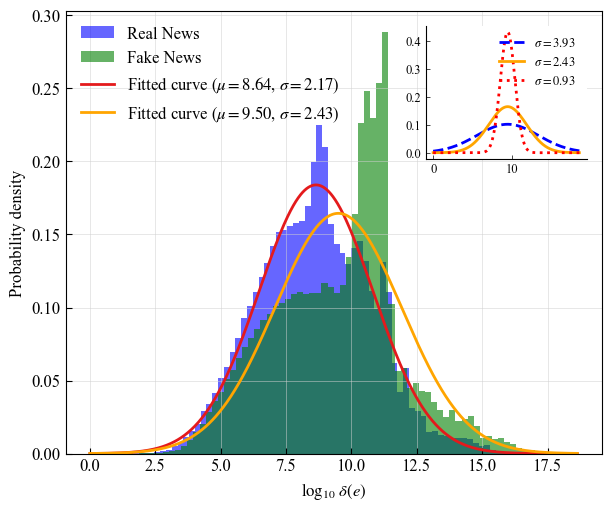

Fitted (log-domain) normal for REAL:  mu=8.6440, sigma=2.1692
Fitted (log-domain) normal for FAKE:  mu=9.4959, sigma=2.4257


In [89]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ====== 全局风格（IEEE 常见设置）======
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (6.0, 5),
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 1.8,
    "savefig.dpi": 600
})

# ====== 颜色 ======
REAL_HIST  = "blue"
FAKE_HIST  = "green"
REAL_LINE  = "#E41A1C"      # red
FAKE_LINE  = "#FFA500"      # orange

# ====== 数据预处理 ======
new_list_1 = np.asarray(new_list_real)   # Real
new_list_2 = np.asarray(new_list_fake)   # Fake
new_list_1 = new_list_1[new_list_1 > 0]
new_list_2 = new_list_2[new_list_2 > 0]
data_1 = np.log(new_list_1)
data_2 = np.log(new_list_2)

# 拟合正态分布（log 域）
mu1, sigma1 = norm.fit(data_1)
mu2, sigma2 = norm.fit(data_2)

# 统一横轴范围
xmin = min(data_1.min(), data_2.min())
xmax = max(data_1.max(), data_2.max())
x = np.linspace(xmin, xmax, 1000)
pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

# ====== 主图 ======
fig, ax = plt.subplots(constrained_layout=True)

ax.hist(data_1, bins=80, density=True, alpha=0.6,
        color=REAL_HIST, edgecolor=None, label="Real News")
ax.hist(data_2, bins=80, density=True, alpha=0.6,
        color=FAKE_HIST, edgecolor=None, label="Fake News")

ax.plot(x, pdf1, color=REAL_LINE,
        label=fr"Fitted curve ($\mu={mu1:.2f}$, $\sigma={sigma1:.2f}$)", linewidth=2.0)
ax.plot(x, pdf2, color=FAKE_LINE,
        label=fr"Fitted curve ($\mu={mu2:.2f}$, $\sigma={sigma2:.2f}$)", linewidth=2.0)

ax.set_xlabel(r"$\log_{10}\,\delta(e)$")
ax.set_ylabel("Probability density")
ax.tick_params(direction="in", length=4, width=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(True)
ax.grid(True, color="#D0D0D0", linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, loc="upper left")

# ====== 内嵌小图（展示三条 σ 曲线）======
# 基于 fake 的参数绘制：σ±1.5
x_in = np.linspace(data_2.min(), data_2.max(), 1000)
sigma_inc = sigma2 + 1.5
sigma_red = max(sigma2 - 1.5, 1e-6)   # 避免非正

pdf_inc = norm.pdf(x_in, mu2, sigma_inc)
pdf_ori = norm.pdf(x_in, mu2, sigma2)
pdf_red = norm.pdf(x_in, mu2, sigma_red)

ax_in = inset_axes(ax, width="30%", height="30%", loc="upper right", borderpad=0.9)
ax_in.plot(x_in, pdf_inc, color="blue",  linestyle="--", linewidth=2.0, label=fr"$\sigma={sigma_inc:.2f}$")
ax_in.plot(x_in, pdf_ori, color="orange", linestyle="-",  linewidth=2.0, label=fr"$\sigma={sigma2:.2f}$")
ax_in.plot(x_in, pdf_red, color="red",   linestyle=":",  linewidth=2.0, label=fr"$\sigma={sigma_red:.2f}$")

# 小图样式：去网格、收紧刻度、仅保留左下坐标轴、小号图例
ax_in.grid(False)
ax_in.tick_params(direction="in", length=3, width=0.5, labelsize=9)
for spine in ["top", "right"]:
    ax_in.spines[spine].set_visible(False)
ax_in.legend(frameon=False, fontsize=9, loc="upper right", handlelength=2)

# ====== 显示 / 保存 ======
# fig.savefig("main_with_inset.pdf", bbox_inches="tight")
plt.show()

print(f"Fitted (log-domain) normal for REAL:  mu={mu1:.4f}, sigma={sigma1:.4f}")
print(f"Fitted (log-domain) normal for FAKE:  mu={mu2:.4f}, sigma={sigma2:.4f}")


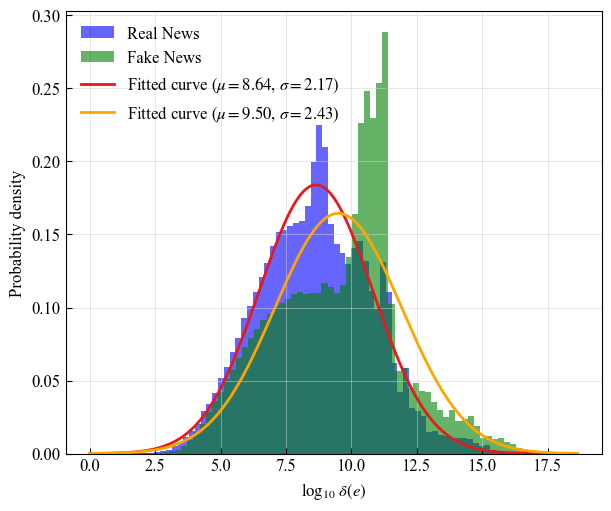

Fitted (log-domain) normal for REAL:  mu=8.6440, sigma=2.1692
Fitted (log-domain) normal for FAKE:  mu=9.4959, sigma=2.4257


In [91]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# ====== 全局风格（IEEE 常见设置）======
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (6.0, 5),
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 1.8,
    "savefig.dpi": 600
})

# ====== 颜色（按你提供的图示配色）======
REAL_HIST  = "blue"   # 纯蓝（直方图-真实）
FAKE_HIST  = "green"   # 森林绿（直方图-虚假）
REAL_LINE  = "#E41A1C"   # 红（拟合-真实）
FAKE_LINE  = "#FFA500"   # 橙（拟合-虚假）

# ====== 数据预处理 ======
new_list_1 = np.asarray(new_list_real)  # 真实
new_list_2 = np.asarray(new_list_fake)  # 虚假

new_list_1 = new_list_1[new_list_1 > 0]
new_list_2 = new_list_2[new_list_2 > 0]
data_1 = np.log(new_list_1)
data_2 = np.log(new_list_2)

# 拟合正态分布（对 log 数据）
mu1, sigma1 = norm.fit(data_1)
mu2, sigma2 = norm.fit(data_2)

# 统一横轴范围
xmin = min(data_1.min(), data_2.min())
xmax = max(data_1.max(), data_2.max())
x = np.linspace(xmin, xmax, 1000)

pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

# ====== 绘图 ======
fig, ax = plt.subplots(constrained_layout=True)

# 直方图：无边框（edgecolor=None），更接近示例图
ax.hist(
    data_1, bins=80, density=True, alpha=0.6,
    color=REAL_HIST, edgecolor=None, label="Real News"
)
ax.hist(
    data_2, bins=80, density=True, alpha=0.6,
    color=FAKE_HIST, edgecolor=None, label="Fake News"
)

# Fitted curves: red / orange
ax.plot(x, pdf1, color=REAL_LINE,
        label=fr"Fitted curve ($\mu={mu1:.2f}$, $\sigma={sigma1:.2f}$)", linewidth=2.0)
ax.plot(x, pdf2, color=FAKE_LINE,
        label=fr"Fitted curve ($\mu={mu2:.2f}$, $\sigma={sigma2:.2f}$)", linewidth=2.0)


# 坐标与样式
ax.set_xlabel(r"$\log_{10}\,\delta(e)$")
ax.set_ylabel("Probability density")
ax.tick_params(direction="in", length=4, width=0.8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(True)

# 网格与图例
ax.grid(True, color="#D0D0D0", linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, loc="upper left")

plt.show()

print(f"Fitted (log-domain) normal for REAL:  mu={mu1:.4f}, sigma={sigma1:.4f}")
print(f"Fitted (log-domain) normal for FAKE:  mu={mu2:.4f}, sigma={sigma2:.4f}")


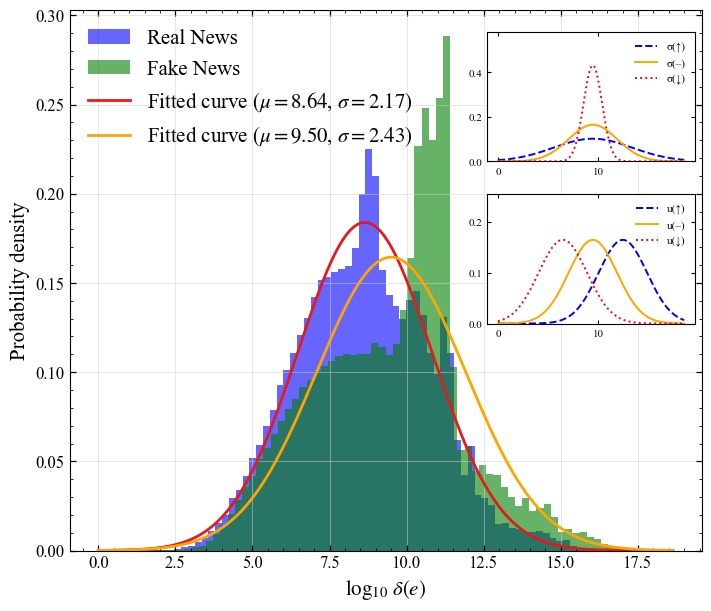

Fitted (log-domain) normal for REAL:  mu=8.6440, sigma=2.1692
Fitted (log-domain) normal for FAKE:  mu=9.4959, sigma=2.4257


In [93]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ====== Global style (IEEE-like) ======
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (7, 6.0),
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "lines.linewidth": 1.8,
    "savefig.dpi": 600
})

# ====== Colors ======
REAL_HIST  = "blue"       # histogram (Real)
FAKE_HIST  = "green"      # histogram (Fake)
REAL_LINE  = "#E41A1C"    # red   (Real fit)
FAKE_LINE  = "#FFA500"    # orange(Fake fit)

# ====== Data (expects new_list_real / new_list_fake defined) ======
new_list_1 = np.asarray(new_list_real)   # Real
new_list_2 = np.asarray(new_list_fake)   # Fake
new_list_1 = new_list_1[new_list_1 > 0]
new_list_2 = new_list_2[new_list_2 > 0]
data_1 = np.log(new_list_1)
data_2 = np.log(new_list_2)

# Fit normal on log-domain data
mu1, sigma1 = norm.fit(data_1)
mu2, sigma2 = norm.fit(data_2)

# Common x-range and PDFs
xmin = min(data_1.min(), data_2.min())
xmax = max(data_1.max(), data_2.max())
x = np.linspace(xmin, xmax, 1000)
pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

# ====== Main figure ======
fig, ax = plt.subplots(constrained_layout=True)

# Histograms (no edge)
ax.hist(data_1, bins=80, density=True, alpha=0.60, color=REAL_HIST, edgecolor=None, label="Real News")
ax.hist(data_2, bins=80, density=True, alpha=0.60, color=FAKE_HIST, edgecolor=None, label="Fake News")

# Fitted curves
ax.plot(x, pdf1, color=REAL_LINE,  linewidth=2.0,
        label=fr"Fitted curve ($\mu={mu1:.2f}$, $\sigma={sigma1:.2f}$)")
ax.plot(x, pdf2, color=FAKE_LINE,  linewidth=2.0,
        label=fr"Fitted curve ($\mu={mu2:.2f}$, $\sigma={sigma2:.2f}$)")

# Axes labels
ax.set_xlabel(r"$\log_{10}\,\delta(e)$")
ax.set_ylabel("Probability density")

# Major ticks on all four sides + minor ticks
ax.tick_params(axis="both", which="major", direction="in", length=4, width=0.9,
               top=True, right=True, bottom=True, left=True, labelsize=12)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", length=2, width=0.6,
               top=True, right=True, bottom=True, left=True)

# Keep all spines visible
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(True)

# Subtle grid (optional)
ax.grid(True, color="#D0D0D0", linewidth=0.6, alpha=0.6)

# Legend (upper-left to avoid overlap with insets)
ax.legend(frameon=False, loc="upper left")

# ====== Inset 1: sigma variation（缩小曲线占比 + 保留四边轴）======
ax_in1 = ax.inset_axes([0.66, 0.72, 0.33, 0.24])
x_in = np.linspace(data_2.min(), data_2.max(), 1000)
sigma_inc = sigma2 + 1.5
sigma_red = max(sigma2 - 1.5, 1e-6)
pdf_inc = norm.pdf(x_in, mu2, sigma_inc)
pdf_ori = norm.pdf(x_in, mu2, sigma2)
pdf_red = norm.pdf(x_in, mu2, sigma_red)

# 先画线，线宽略小
ax_in1.plot(x_in, pdf_inc, color="blue",   linestyle="--", linewidth=1.4, label="σ(↑)")
ax_in1.plot(x_in, pdf_ori, color="orange", linestyle="-",  linewidth=1.4, label="σ(–)")
ax_in1.plot(x_in, pdf_red, color="red",    linestyle=":",  linewidth=1.4, label="σ(↓)")

# 留出头部与左右边距：把 y 上限抬高一些；x/y 方向加边距
ymax1 = max(pdf_inc.max(), pdf_ori.max(), pdf_red.max())
ax_in1.set_ylim(0, ymax1 * 1.35)   # 1.25~1.45 之间可调
ax_in1.margins(x=0.06, y=0.10)     # 两侧留白

# 四边轴线与四边刻度（紧凑）
for spine in ["top", "right", "bottom", "left"]:
    ax_in1.spines[spine].set_visible(True)
ax_in1.tick_params(axis="both", which="major", direction="in",
                   length=3, width=0.8, top=True, right=True, bottom=True, left=True, labelsize=8)
ax_in1.locator_params(axis="x", nbins=3)
ax_in1.locator_params(axis="y", nbins=3)

# 图例仍在右上；若仍拥挤，可改 bbox_to_anchor 往右外侧挪一点
ax_in1.legend(frameon=False, fontsize=8, loc="upper right")  # 或 loc="upper left"


# ====== Inset 2: mu variation（缩小曲线占比 + 保留四边轴）======
ax_in2 = ax.inset_axes([0.66, 0.42, 0.33, 0.24])
mu_inc = mu2 + 3.0
mu_red = mu2 - 3.0
pdf_mu_inc = norm.pdf(x_in, mu_inc, sigma2)
pdf_mu_ori = norm.pdf(x_in, mu2,    sigma2)
pdf_mu_red = norm.pdf(x_in, mu_red, sigma2)

ax_in2.plot(x_in, pdf_mu_inc, color="blue",   linestyle="--", linewidth=1.4, label="u(↑)")
ax_in2.plot(x_in, pdf_mu_ori, color="orange", linestyle="-",  linewidth=1.4, label="u(–)")
ax_in2.plot(x_in, pdf_mu_red, color="red",    linestyle=":",  linewidth=1.4, label="u(↓)")

ymax2 = max(pdf_mu_inc.max(), pdf_mu_ori.max(), pdf_mu_red.max())
ax_in2.set_ylim(0, ymax2 * 1.55)
ax_in2.margins(x=0.06, y=0.10)

for spine in ["top", "right", "bottom", "left"]:
    ax_in2.spines[spine].set_visible(True)
ax_in2.tick_params(axis="both", which="major", direction="in",
                   length=3, width=0.8, top=True, right=True, bottom=True, left=True, labelsize=8)
ax_in2.locator_params(axis="x", nbins=3)
ax_in2.locator_params(axis="y", nbins=3)

ax_in2.legend(frameon=False, fontsize=8, loc="upper right")


# ====== Show (or save) ======
fig.savefig("E:\大论文-第一部分\图片\main_with_two_insets.png", bbox_inches="tight")
plt.show()

# Console logs (optional)
print(f"Fitted (log-domain) normal for REAL:  mu={mu1:.4f}, sigma={sigma1:.4f}")
print(f"Fitted (log-domain) normal for FAKE:  mu={mu2:.4f}, sigma={sigma2:.4f}")


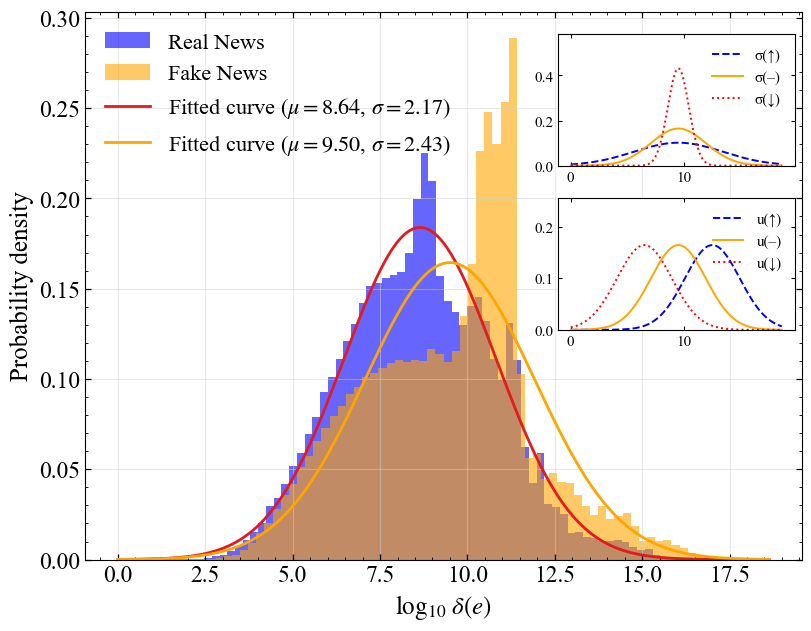

Fitted (log-domain) normal for REAL:  mu=8.6440, sigma=2.1692
Fitted (log-domain) normal for FAKE:  mu=9.4959, sigma=2.4257


In [95]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ====== Global style (IEEE-like) ======
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (8, 6.2),
    "axes.labelsize": 15,   # baseline (will be overridden below for main/insets)
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "lines.linewidth": 1.8,
    "savefig.dpi": 600
})

# ====== Colors ======
REAL_HIST  = "blue"       # histogram (Real)
FAKE_HIST  = "orange"      # histogram (Fake)
REAL_LINE  = "#E41A1C"    # red   (Real fit)
FAKE_LINE  = "#FFA500"    # orange(Fake fit)

# ====== Data (expects new_list_real / new_list_fake defined) ======
new_list_1 = np.asarray(new_list_real)   # Real
new_list_2 = np.asarray(new_list_fake)   # Fake
new_list_1 = new_list_1[new_list_1 > 0]
new_list_2 = new_list_2[new_list_2 > 0]
data_1 = np.log(new_list_1)
data_2 = np.log(new_list_2)

# Fit normal on log-domain data
mu1, sigma1 = norm.fit(data_1)
mu2, sigma2 = norm.fit(data_2)

# Common x-range and PDFs
xmin = min(data_1.min(), data_2.min())
xmax = max(data_1.max(), data_2.max())
x = np.linspace(xmin, xmax, 1000)
pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

# ====== Font sizes (fine-grained control) ======
MAIN_LABEL_FONTSIZE   = 18
MAIN_TICK_FONTSIZE    = 17
MAIN_LEGEND_FONTSIZE  = 16
INSET_TICK_FONTSIZE   = 11
INSET_LEGEND_FONTSIZE = 11

# ====== Main figure ======
fig, ax = plt.subplots(constrained_layout=True)

# Histograms (no edge)
ax.hist(data_1, bins=80, density=True, alpha=0.60, color=REAL_HIST, edgecolor=None, label="Real News")
ax.hist(data_2, bins=80, density=True, alpha=0.60, color=FAKE_HIST, edgecolor=None, label="Fake News")

# Fitted curves
ax.plot(x, pdf1, color=REAL_LINE,  linewidth=2.0,
        label=fr"Fitted curve ($\mu={mu1:.2f}$, $\sigma={sigma1:.2f}$)")
ax.plot(x, pdf2, color=FAKE_LINE,  linewidth=2.0,
        label=fr"Fitted curve ($\mu={mu2:.2f}$, $\sigma={sigma2:.2f}$)")

# Axes labels (enlarged)
ax.set_xlabel(r"$\log_{10}\,\delta(e)$", fontsize=MAIN_LABEL_FONTSIZE)
ax.set_ylabel("Probability density", fontsize=MAIN_LABEL_FONTSIZE)

# Major ticks on all four sides + minor ticks (enlarged)
ax.tick_params(axis="both", which="major", direction="in", length=4, width=0.9,
               top=True, right=True, bottom=True, left=True, labelsize=MAIN_TICK_FONTSIZE)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", length=2, width=0.6,
               top=True, right=True, bottom=True, left=True, labelsize=MAIN_TICK_FONTSIZE-2)

# Keep all spines visible
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(True)

# Subtle grid (optional)
ax.grid(True, color="#D0D0D0", linewidth=0.6, alpha=0.6)

# Legend (upper-left to avoid overlap with insets; enlarged)
ax.legend(frameon=False, loc="upper left", fontsize=MAIN_LEGEND_FONTSIZE)

# ====== Inset 1: sigma variation (smaller curves + four spines) ======
ax_in1 = ax.inset_axes([0.66, 0.72, 0.33, 0.24])
x_in = np.linspace(data_2.min(), data_2.max(), 1000)
sigma_inc = sigma2 + 1.5
sigma_red = max(sigma2 - 1.5, 1e-6)
pdf_inc = norm.pdf(x_in, mu2, sigma_inc)
pdf_ori = norm.pdf(x_in, mu2, sigma2)
pdf_red = norm.pdf(x_in, mu2, sigma_red)

ax_in1.plot(x_in, pdf_inc, color="blue",   linestyle="--", linewidth=1.4, label="σ(↑)")
ax_in1.plot(x_in, pdf_ori, color="orange", linestyle="-",  linewidth=1.4, label="σ(–)")
ax_in1.plot(x_in, pdf_red, color="red",    linestyle=":",  linewidth=1.4, label="σ(↓)")

ymax1 = max(pdf_inc.max(), pdf_ori.max(), pdf_red.max())
ax_in1.set_ylim(0, ymax1 * 1.35)
ax_in1.margins(x=0.06, y=0.10)

for spine in ["top", "right", "bottom", "left"]:
    ax_in1.spines[spine].set_visible(True)
ax_in1.tick_params(axis="both", which="major", direction="in",
                   length=3, width=0.8, top=True, right=True, bottom=True, left=True,
                   labelsize=INSET_TICK_FONTSIZE)
ax_in1.locator_params(axis="x", nbins=3)
ax_in1.locator_params(axis="y", nbins=3)
ax_in1.legend(frameon=False, fontsize=INSET_LEGEND_FONTSIZE, loc="upper right")

# ====== Inset 2: mu variation (smaller curves + four spines) ======
ax_in2 = ax.inset_axes([0.66, 0.42, 0.33, 0.24])
mu_inc = mu2 + 3.0
mu_red = mu2 - 3.0
pdf_mu_inc = norm.pdf(x_in, mu_inc, sigma2)
pdf_mu_ori = norm.pdf(x_in, mu2,    sigma2)
pdf_mu_red = norm.pdf(x_in, mu_red, sigma2)

ax_in2.plot(x_in, pdf_mu_inc, color="blue",   linestyle="--", linewidth=1.4, label="u(↑)")
ax_in2.plot(x_in, pdf_mu_ori, color="orange", linestyle="-",  linewidth=1.4, label="u(–)")
ax_in2.plot(x_in, pdf_mu_red, color="red",    linestyle=":",  linewidth=1.4, label="u(↓)")

ymax2 = max(pdf_mu_inc.max(), pdf_mu_ori.max(), pdf_mu_red.max())
ax_in2.set_ylim(0, ymax2 * 1.55)
ax_in2.margins(x=0.06, y=0.10)

for spine in ["top", "right", "bottom", "left"]:
    ax_in2.spines[spine].set_visible(True)
ax_in2.tick_params(axis="both", which="major", direction="in",
                   length=3, width=0.8, top=True, right=True, bottom=True, left=True,
                   labelsize=INSET_TICK_FONTSIZE)
ax_in2.locator_params(axis="x", nbins=3)
ax_in2.locator_params(axis="y", nbins=3)
ax_in2.legend(frameon=False, fontsize=INSET_LEGEND_FONTSIZE, loc="upper right")

# ====== Show (or save) ======
fig.savefig(r"E:\大论文-第一部分\图片\main_with_two_insets.png", bbox_inches="tight")
plt.show()

# Console logs (optional)
print(f"Fitted (log-domain) normal for REAL:  mu={mu1:.4f}, sigma={sigma1:.4f}")
print(f"Fitted (log-domain) normal for FAKE:  mu={mu2:.4f}, sigma={sigma2:.4f}")


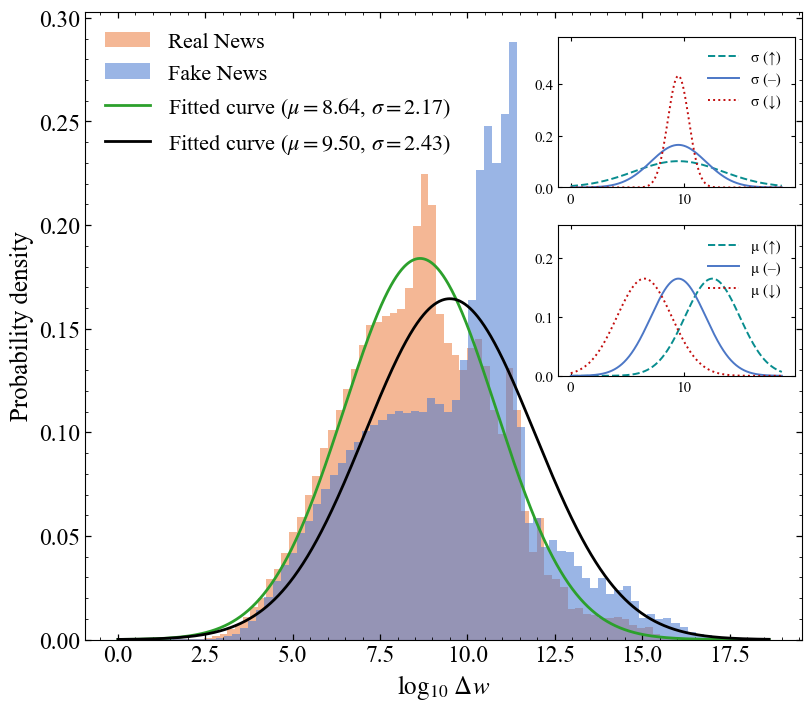

Fitted (log-domain) normal for REAL:  mu=8.6440, sigma=2.1692
Fitted (log-domain) normal for FAKE:  mu=9.4959, sigma=2.4257


In [97]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ====== Global style (IEEE-like) ======
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (8, 7),
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "lines.linewidth": 1.8,
    "savefig.dpi": 600
})

# ====== Colors ======
REAL_HIST  = '#ED874E'    # 虚假信息（或按你数据含义调整）
FAKE_HIST  = '#4878D0'  # 真实信息
REAL_LINE  = "#2ca02c"    # 红色拟合曲线（Real）
FAKE_LINE  = "black"    # 橙色拟合曲线（Fake）

# ====== Data (expects new_list_real / new_list_fake defined) ======
new_list_1 = np.asarray(new_list_real)   # Real
new_list_2 = np.asarray(new_list_fake)   # Fake
new_list_1 = new_list_1[new_list_1 > 0]
new_list_2 = new_list_2[new_list_2 > 0]
data_1 = np.log(new_list_1)
data_2 = np.log(new_list_2)

# Fit normal on log-domain data
mu1, sigma1 = norm.fit(data_1)
mu2, sigma2 = norm.fit(data_2)

# Common x-range and PDFs
xmin = min(data_1.min(), data_2.min())
xmax = max(data_1.max(), data_2.max())
x = np.linspace(xmin, xmax, 1000)
pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

# ====== Font sizes (fine-grained control) ======
MAIN_LABEL_FONTSIZE   = 18
MAIN_TICK_FONTSIZE    = 17
MAIN_LEGEND_FONTSIZE  = 16
INSET_TICK_FONTSIZE   = 11
INSET_LEGEND_FONTSIZE = 11

# ====== Main figure ======
fig, ax = plt.subplots(constrained_layout=True)

# Histograms (blue & yellow)
ax.hist(data_1, bins=80, density=True, alpha=0.60, color=REAL_HIST, edgecolor=None, label="Real News")
ax.hist(data_2, bins=80, density=True, alpha=0.55, color=FAKE_HIST, edgecolor=None, label="Fake News")

# Fitted curves
ax.plot(x, pdf1, color=REAL_LINE,  linewidth=2.0,
        label=fr"Fitted curve ($\mu={mu1:.2f}$, $\sigma={sigma1:.2f}$)")
ax.plot(x, pdf2, color=FAKE_LINE,  linewidth=2.0,
        label=fr"Fitted curve ($\mu={mu2:.2f}$, $\sigma={sigma2:.2f}$)")

# Axes labels
ax.set_xlabel(r"$\log_{10}\,\Delta w$", fontsize=MAIN_LABEL_FONTSIZE)
ax.set_ylabel("Probability density", fontsize=MAIN_LABEL_FONTSIZE)

# Ticks
ax.tick_params(axis="both", which="major", direction="in", length=4, width=0.9,
               top=True, right=True, bottom=True, left=True, labelsize=MAIN_TICK_FONTSIZE)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", length=2, width=0.6,
               top=True, right=True, bottom=True, left=True, labelsize=MAIN_TICK_FONTSIZE-2)

# Spines
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(True)

# Optional grid
# ax.grid(True, color="#D0D0D0", linewidth=0.6, alpha=0.6)

# Legend
ax.legend(frameon=False, loc="upper left", fontsize=MAIN_LEGEND_FONTSIZE)

# ====== Inset 1 & 2 (unchanged) ======
ax_in1 = ax.inset_axes([0.66, 0.72, 0.33, 0.24])
x_in = np.linspace(data_2.min(), data_2.max(), 1000)
sigma_inc = sigma2 + 1.5
sigma_red = max(sigma2 - 1.5, 1e-6)
pdf_inc = norm.pdf(x_in, mu2, sigma_inc)
pdf_ori = norm.pdf(x_in, mu2, sigma2)
pdf_red = norm.pdf(x_in, mu2, sigma_red)
ax_in1.plot(x_in, pdf_inc, color="#088D8F",   linestyle="--", linewidth=1.4, label="σ (↑)")
ax_in1.plot(x_in, pdf_ori, color="#4C77C6", linestyle="-",  linewidth=1.4, label="σ (–)")
ax_in1.plot(x_in, pdf_red, color="#C30D0D",    linestyle=":",  linewidth=1.4, label="σ (↓)")
ymax1 = max(pdf_inc.max(), pdf_ori.max(), pdf_red.max())
ax_in1.set_ylim(0, ymax1 * 1.35)
ax_in1.margins(x=0.06, y=0.10)
for spine in ["top", "right", "bottom", "left"]:
    ax_in1.spines[spine].set_visible(True)
ax_in1.tick_params(axis="both", which="major", direction="in",
                   length=3, width=0.8, top=True, right=True, bottom=True, left=True,
                   labelsize=INSET_TICK_FONTSIZE)
ax_in1.locator_params(axis="x", nbins=3)
ax_in1.locator_params(axis="y", nbins=3)
ax_in1.legend(frameon=False, fontsize=INSET_LEGEND_FONTSIZE, loc="upper right")

ax_in2 = ax.inset_axes([0.66, 0.42, 0.33, 0.24])
mu_inc = mu2 + 3.0
mu_red = mu2 - 3.0
pdf_mu_inc = norm.pdf(x_in, mu_inc, sigma2)
pdf_mu_ori = norm.pdf(x_in, mu2,    sigma2)
pdf_mu_red = norm.pdf(x_in, mu_red, sigma2)
ax_in2.plot(x_in, pdf_mu_inc, color="#088D8F",   linestyle="--", linewidth=1.4, label="μ (↑)")
ax_in2.plot(x_in, pdf_mu_ori, color="#4C77C6", linestyle="-",  linewidth=1.4, label="μ (–)")
ax_in2.plot(x_in, pdf_mu_red, color="#C30D0D",    linestyle=":",  linewidth=1.4, label="μ (↓)")
ymax2 = max(pdf_mu_inc.max(), pdf_mu_ori.max(), pdf_mu_red.max())
ax_in2.set_ylim(0, ymax2 * 1.55)
ax_in2.margins(x=0.06, y=0.10)
for spine in ["top", "right", "bottom", "left"]:
    ax_in2.spines[spine].set_visible(True)
ax_in2.tick_params(axis="both", which="major", direction="in",
                   length=3, width=0.8, top=True, right=True, bottom=True, left=True,
                   labelsize=INSET_TICK_FONTSIZE)
ax_in2.locator_params(axis="x", nbins=3)
ax_in2.locator_params(axis="y", nbins=3)
ax_in2.legend(frameon=False, fontsize=INSET_LEGEND_FONTSIZE, loc="upper right")

# ====== Save & show ======
# fig.savefig(r"E:\大论文-第一部分\图片\main_with_two_insets.png", bbox_inches="tight")
plt.show()

print(f"Fitted (log-domain) normal for REAL:  mu={mu1:.4f}, sigma={sigma1:.4f}")
print(f"Fitted (log-domain) normal for FAKE:  mu={mu2:.4f}, sigma={sigma2:.4f}")


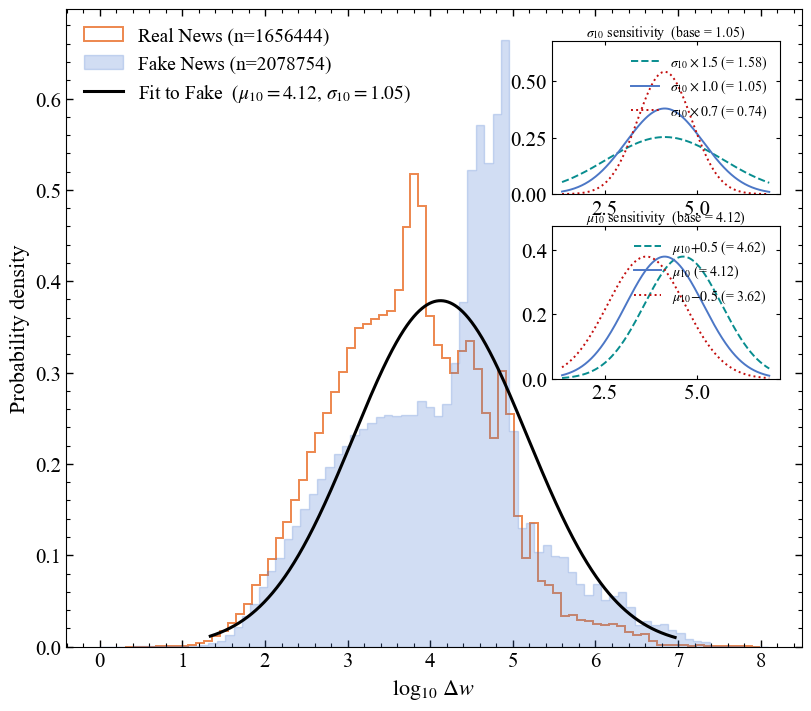

[log10-domain] FAKE: mu_10=4.1240, sigma_10=1.0535
[log10-domain] REAL: (shown as histogram only), n=1656444


In [153]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

# ===== Style =====
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (8, 7),
    "axes.labelsize": 16,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 14,
    "lines.linewidth": 2.2,
    "savefig.dpi": 600,
})

# Colors
REAL_EDGE = '#ED874E'     # Real 轮廓
FAKE_FILL = '#4878D0'     # Fake 填充
FAKE_LINE = '#000000'     # Fake 拟合曲线

# ===== Data =====
x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("Filtered data is empty. Ensure inputs contain positive values.")

n_real, n_fake = x_real.size, x_fake.size

# log10 domain
z_real = np.log10(x_real)
z_fake = np.log10(x_fake)

# Fit (only for Fake, since sensitivity uses Fake)
mu_f, sig_f = norm.fit(z_fake)

# x-range by 1%~99% quantiles + padding
z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x, mu_f, sig_f)

# ===== Plot =====
fig, ax = plt.subplots(constrained_layout=True)
bins = 80

# Real: step (no fill), thinner line，置底
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.4, color=REAL_EDGE, label=f"Real News (n={n_real})", zorder=1)

# Fake: filled stepfilled + edge，半透明，置中
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label=f"Fake News (n={n_fake})", zorder=2)

# Only one fitted curve (to Fake) — on top
ax.plot(x, pdf_f, color=FAKE_LINE,
        label=fr"Fit to Fake  ($\mu_{{10}}={mu_f:.2f},\,\sigma_{{10}}={sig_f:.2f}$)",
        zorder=3)

# Axes
ax.set_xlabel(r"$\log_{10}\,\Delta w$")
ax.set_ylabel("Probability density")
ax.tick_params(axis="both", which="major", direction="in", length=5, width=1.0, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)

ax.legend(frameon=False, loc="upper left")

# ===== Insets: sensitivity around Fake parameters, with numeric labels =====
x_in = np.linspace(xmin, xmax, 600)

# σ sensitivity
ax_in1 = ax.inset_axes([0.66, 0.71, 0.31, 0.24])
for scale, color, ls in [(1.5, "#088D8F", "--"), (1.0, "#4C77C6", "-"), (0.7, "#C30D0D", ":")]:
    val = sig_f * scale
    ax_in1.plot(x_in, norm.pdf(x_in, mu_f, val), color=color, linestyle=ls, linewidth=1.4,
                label=fr"$\sigma_{{10}}\times{scale:.1f}$ (= {val:.2f})")
ax_in1.set_ylim(0, max([line.get_ydata().max() for line in ax_in1.lines]) * 1.25)
ax_in1.tick_params(which="both", direction="in", length=3, width=0.8, top=True, right=True)
ax_in1.locator_params(axis="x", nbins=3); ax_in1.locator_params(axis="y", nbins=3)
ax_in1.legend(frameon=False, fontsize=10, loc="upper right")
ax_in1.set_title(fr"$\sigma_{{10}}$ sensitivity  (base = {sig_f:.2f})", fontsize=10, pad=2)

# --- Inset 2: μ sensitivity (±0.5 on log10)
ax_in2 = ax.inset_axes([0.66, 0.42, 0.31, 0.24])
for dmu, color, ls, lab in [
    (+0.5, "#088D8F", "--", r"$\mu_{10}{+}0.5$"),
    (0.0,  "#4C77C6", "-",  r"$\mu_{10}$"),
    (-0.5, "#C30D0D", ":",  r"$\mu_{10}{-}0.5$")
]:
    val = mu_f + dmu
    ax_in2.plot(
        x_in, norm.pdf(x_in, val, sig_f),
        color=color, linestyle=ls, linewidth=1.4,
        label=f"{lab} (= {val:.2f})"
    )

ax_in2.set_ylim(0, max([line.get_ydata().max() for line in ax_in2.lines]) * 1.25)
ax_in2.tick_params(which="both", direction="in", length=3, width=0.8, top=True, right=True)
ax_in2.locator_params(axis="x", nbins=3); ax_in2.locator_params(axis="y", nbins=3)
ax_in2.legend(frameon=False, fontsize=10, loc="upper right")
ax_in2.set_title(fr"$\mu_{{10}}$ sensitivity  (base = {mu_f:.2f})", fontsize=10, pad=2)


# ===== Save & show =====
save = False  # 需要保存就改 True
if save:
    out_path = Path(r"E:\大论文-第一部分\图片\log10_fit_fake_only.png")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
plt.show()

print(f"[log10-domain] FAKE: mu_10={mu_f:.4f}, sigma_10={sig_f:.4f}")
print(f"[log10-domain] REAL: (shown as histogram only), n={n_real}")


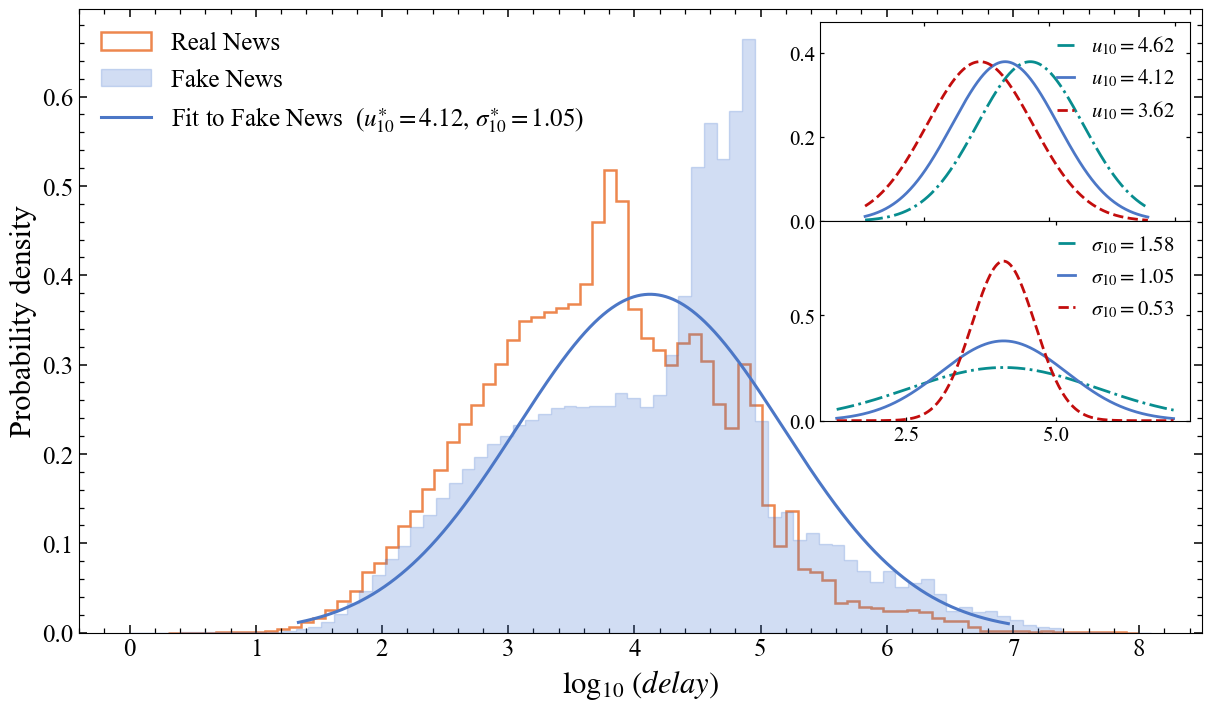

[log10-domain] FAKE: u_10=4.1240, sigma_10=1.0535


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

# ===== Style (保持你上个版本的放大设置) =====
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (12, 7),
    "axes.labelsize": 22,   # 主图轴标签大
    "xtick.labelsize": 18,  # 主图刻度大
    "ytick.labelsize": 18,
    "legend.fontsize": 18,  # 主图图例大
    "lines.linewidth": 2.2,
    "savefig.dpi": 600,
})

# ===== 颜色与线型：与“解耦.png”脚本保持一致 =====
COLOR_INC  = '#088D8F'  # 增大
COLOR_BASE = '#4C77C6'  # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'  # 减小

LS_INC   = '-.'   # 增大
LS_BASE  = '-'    # 不变
LS_DEC   = '--'   # 减小

# 直方图颜色
REAL_EDGE = '#ED874E'     # Real 轮廓
FAKE_FILL = '#4878D0'     # Fake 填充(直方图)

# ===== Data =====
x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("Filtered data is empty. Ensure inputs contain positive values.")

# log10 domain
z_real = np.log10(x_real)
z_fake = np.log10(x_fake)

# Fit (only for Fake)
mu_f, sig_f = norm.fit(z_fake)

# x-range by 1%~99% quantiles + padding
z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x, mu_f, sig_f)

# ===== Plot =====
fig, ax = plt.subplots(constrained_layout=True)
bins = 80

# Real: step (no fill)
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)

# Fake: filled stepfilled + edge
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

# 主图仅绘制 Fake 的拟合曲线 —— 使用“不变”的配色与线型（与小图基准一致）
ax.plot(x, pdf_f, color=COLOR_BASE, linestyle=LS_BASE,
        label=fr"Fit to Fake News  ($u_{{10}}^{{\ast}}={mu_f:.2f},\,\sigma_{{10}}^{{\ast}}={sig_f:.2f}$)",
        zorder=3)


# Axes
ax.set_xlabel(r"$\log_{10}\,(delay)$")
ax.set_ylabel("Probability density")
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", length=3.5, width=0.9, top=True, right=True)
for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)

ax.legend(frameon=False, loc="upper left")

# ===== Insets（顺序已对调：上 = u10；下 = σ10）=====
x_in = np.linspace(xmin, xmax, 600)
INSET_TICK_SIZE   = 15
INSET_LEGEND_SIZE = 15

# --- 上：μ 灵敏度（内部顶部一行）---
ax_in_mu = ax.inset_axes([0.66, 0.66, 0.33, 0.32])  # [left, bottom, width, height]
for dmu, color, ls in [
    (+0.5, COLOR_INC,  LS_INC),
    (0.0,  COLOR_BASE, LS_BASE),  # 与主图一致
    (-0.5, COLOR_DEC,  LS_DEC),
]:
    val = mu_f + dmu
    ax_in_mu.plot(x_in, norm.pdf(x_in, val, sig_f),
                  color=color, linestyle=ls, linewidth=2,
                  label=fr"$u_{{10}}={val:.2f}$")

ax_in_mu.set_ylim(0, max([ln.get_ydata().max() for ln in ax_in_mu.lines]) * 1.25)

# ==== 新增：放大第一个子图 x 轴范围（以 μ_f 为中心，按 σ_f 缩放） ====
# ==== 更近：以 μ_f 为中心，仅 ±0.6 σ_f ====
k = 3.5  # 放大系数，越大曲线占的面积越小（可改 3.0 / 4.0）
left_mu  = mu_f - k * sig_f
right_mu = mu_f + k * sig_f
ax_in_mu.set_xlim(left_mu, right_mu)
ax_in_mu.locator_params(axis="x", nbins=3)  # 主刻度少一些，避免拥挤
ax_in_mu.margins(x=0.02)                    # 留一点边距，防止贴边

# ===========================================================

ax_in_mu.tick_params(which="both", direction="in", length=3.2, width=0.9,
                     top=True, right=True, labelsize=INSET_TICK_SIZE)
ax_in_mu.locator_params(axis="y", nbins=3)
ax_in_mu.legend(frameon=False, loc="upper right",
                bbox_to_anchor=(0.98, 0.98),
                ncol=1, columnspacing=1.0, handlelength=0.8,
                borderaxespad=0.0, fontsize=INSET_LEGEND_SIZE)

# --- 下：σ 灵敏度（内部顶部一行）---
ax_in_sig = ax.inset_axes([0.66, 0.34, 0.33, 0.32])
for scale, color, ls in [
    (1.5, COLOR_INC,  LS_INC),
    (1.0, COLOR_BASE, LS_BASE),   # 基准
    (0.5, COLOR_DEC,  LS_DEC),
]:
    val = sig_f * scale
    ax_in_sig.plot(x_in, norm.pdf(x_in, mu_f, val),
                   color=color, linestyle=ls, linewidth=2,
                   label=fr"$\sigma_{{10}}={val:.2f}$")
ax_in_sig.set_ylim(0, max([ln.get_ydata().max() for ln in ax_in_sig.lines]) * 1.25)
ax_in_sig.tick_params(which="both", direction="in", length=3.2, width=0.9,
                      top=True, right=True, labelsize=INSET_TICK_SIZE)
ax_in_sig.locator_params(axis="x", nbins=3); ax_in_sig.locator_params(axis="y", nbins=3)
ax_in_sig.legend(frameon=False, loc="upper right",          # ← 右上
    bbox_to_anchor=(0.98, 0.98),#
                 ncol=1, columnspacing=1.0, handlelength=0.8, borderaxespad=0.0, fontsize=INSET_LEGEND_SIZE)

# ===== Save & show =====
save = True  # 需要保存就改 True
if save:
    out_path = Path(r"E:\大论文-第一部分\图片\log10_fit_fake_only_style_matched_swapped.png")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
plt.show()

print(f"[log10-domain] FAKE: u_10={mu_f:.4f}, sigma_10={sig_f:.4f}")


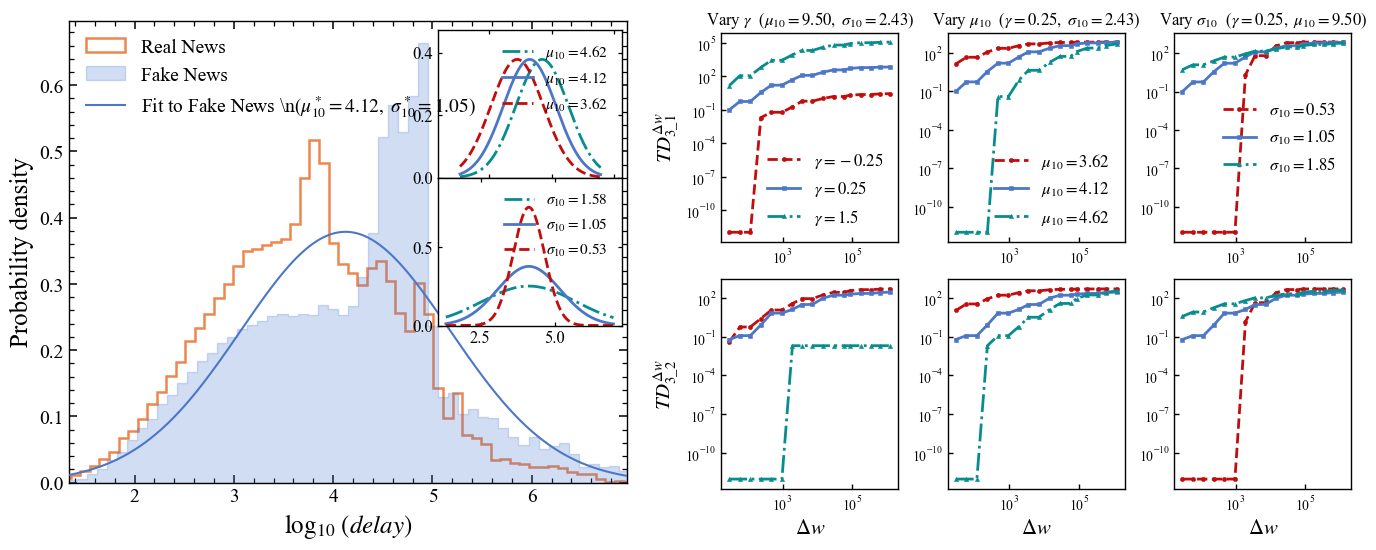

[log10-domain] FAKE: mu_10=4.1240, sigma_10=1.0535
Saved to: E:\大论文-第一部分\图片\组合_左主右六.png


In [25]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.ticker import LogLocator, NullFormatter

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型（与两段脚本保持一致） ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置（按需修改） ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度（减小/不变/增大）
rows_depth   = [1, 3, 5]   # 下排：深度模体度（减小/不变/增大）
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC,  marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

def read_csv_robust(path):
    """无表头读取；若列数与 x 不匹配，尝试丢弃首列或转置后再丢弃首列。"""
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个内嵌图 ==================
# 请准备两组一维数组：new_list_real, new_list_fake（均为正值，单位=延迟秒）
# 例如：
# new_list_real = np.loadtxt('real_delays.txt')
# new_list_fake = np.loadtxt('fake_delays.txt')

# === 运行前请确保这两个变量已在当前命名空间中存在 ===
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左宽右窄 ==================
W, H = 15.0, 6  # 整体画布尺寸
fig = plt.figure(figsize=(W, H))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.1, 1.0], wspace=0.18, figure=fig)

# ---------- 左侧大图 ----------
ax = fig.add_subplot(gs[0, 0])
bins = 80

# Real: 仅轮廓
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)

# Fake: 填充 + 边
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

# 拟合曲线（Fake）
ax.plot(x_fit, pdf_f, color=COLOR_BASE, linestyle=LS_BASE,
        label=fr"Fit to Fake News \n($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
        zorder=3)

ax.set_xlabel(r"$\log_{10}\,(delay)$", fontsize=18)
ax.set_ylabel("Probability density", fontsize=18)
ax.tick_params(axis="both", which="major", labelsize=14, length=6, width=1.1, top=True, right=True)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", length=3.5, width=0.9, top=True, right=True)
for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=14)

# ---- 内嵌 1（上）：μ 灵敏度 ----
ax_in_mu = ax.inset_axes([0.66, 0.66, 0.33, 0.32])
x_in = np.linspace(xmin, xmax, 600)
for dmu, color, ls in [(+0.5, COLOR_INC, LS_INC), (0.0, COLOR_BASE, LS_BASE), (-0.5, COLOR_DEC, LS_DEC)]:
    val = mu_f + dmu
    ax_in_mu.plot(x_in, norm.pdf(x_in, val, sig_f),
                  color=color, linestyle=ls, linewidth=2,
                  label=fr"$\mu_{{10}}={val:.2f}$")
ax_in_mu.set_ylim(0, max([ln.get_ydata().max() for ln in ax_in_mu.lines]) * 1.25)
k = 3.5
left_mu, right_mu = mu_f - k * sig_f, mu_f + k * sig_f
ax_in_mu.set_xlim(left_mu, right_mu)
ax_in_mu.locator_params(axis="x", nbins=3)
ax_in_mu.margins(x=0.02)
ax_in_mu.tick_params(which="both", direction="in", length=3.0, width=0.9,
                     top=True, right=True, labelsize=12)
ax_in_mu.locator_params(axis="y", nbins=3)
ax_in_mu.legend(frameon=False, loc="upper right", fontsize=11)

# ---- 内嵌 2（下）：σ 灵敏度 ----
ax_in_sig = ax.inset_axes([0.66, 0.34, 0.33, 0.32])
for scale, color, ls in [(1.5, COLOR_INC, LS_INC), (1.0, COLOR_BASE, LS_BASE), (0.5, COLOR_DEC, LS_DEC)]:
    val = sig_f * scale
    ax_in_sig.plot(x_in, norm.pdf(x_in, mu_f, val),
                   color=color, linestyle=ls, linewidth=2,
                   label=fr"$\sigma_{{10}}={val:.2f}$")
ax_in_sig.set_ylim(0, max([ln.get_ydata().max() for ln in ax_in_sig.lines]) * 1.25)
ax_in_sig.tick_params(which="both", direction="in", length=3.0, width=0.9,
                      top=True, right=True, labelsize=12)
ax_in_sig.locator_params(axis="x", nbins=3)
ax_in_sig.locator_params(axis="y", nbins=3)
ax_in_sig.legend(frameon=False, loc="upper right", fontsize=11)

axes = np.empty((2, 3), dtype=object)
gs_right = GridSpec(
    nrows=2, ncols=3,
    left=0.56, right=0.98,
    bottom=0.10,   # 原来 0.18 → 0.14（↓ 下移）
    top=0.86,      # 原来 0.90 → 0.86（↓ 下移）
    wspace=0.28, hspace=0.18,
    figure=fig
)
for r in range(2):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs_right[r, c])

for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    # 数据（<=0 的值替换为极小正数，避免 log 轴报错）
    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    # 列标题
    axes[0, col].set_title(fr'Vary {sym}  ({fixed_text})', fontsize=12, pad=6)

    # 上排（广度）
    ax_t = axes[0, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=12, loc='best')

    # 下排（深度）
    ax_b = axes[1, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)


# ================== 保存与显示 ==================
out_path = Path(r"E:\大论文-第一部分\图片\组合_左主右六.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, bbox_inches='tight')
plt.show()

print(f"[log10-domain] FAKE: mu_10={mu_f:.4f}, sigma_10={sig_f:.4f}")
print(f"Saved to: {out_path}")


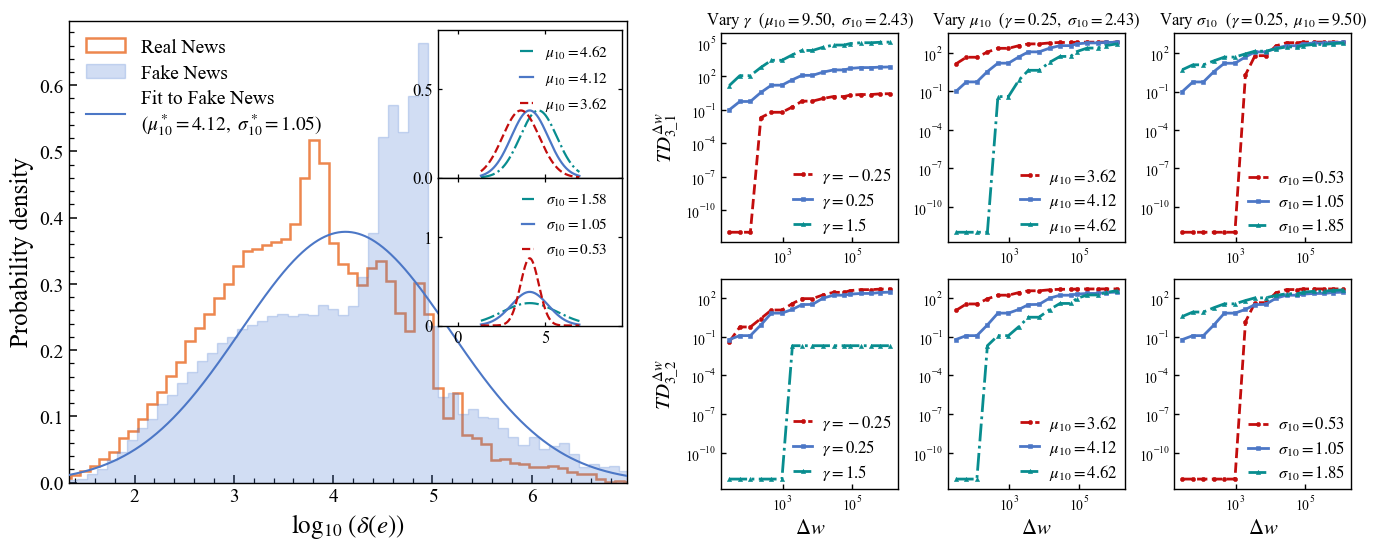

In [17]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.ticker import LogLocator, NullFormatter

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型（与两段脚本保持一致） ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置（按需修改） ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度（减小/不变/增大）
rows_depth   = [1, 3, 5]   # 下排：深度模体度（减小/不变/增大）
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC,  marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

# 统一控制右侧子图 legend 的线段长度与间距
LEGEND_HANDLE_LEN   = 1.15
LEGEND_HANDLE_TEXTP = 0.6
LEGEND_LABEL_SP     = 0.3

def read_csv_robust(path):
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个内嵌图 ==================
# 需要预先定义：new_list_real, new_list_fake（正数）
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左宽右窄 ==================
W, H = 15.0, 6
fig = plt.figure(figsize=(W, H))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.1, 1.0], wspace=0.18, figure=fig)

# ---------- 左侧大图 ----------
ax = fig.add_subplot(gs[0, 0])
bins = 80
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

ax.plot(
    x_fit, pdf_f,
    color=COLOR_BASE, linestyle=LS_BASE,
    label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
    zorder=3
)

ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=18)
ax.set_ylabel("Probability density", fontsize=18)

# 只保留下方和左侧刻度；去掉上方和右侧刻度
ax.tick_params(
    axis="both", which="major",
    labelsize=14, length=6, width=1.1,
    top=False, right=False
)
ax.minorticks_on()
ax.tick_params(
    axis="both", which="minor",
    length=3.5, width=0.9,
    top=False, right=False
)

for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=14, labelspacing=0.4)

# ==== 内嵌图范围控制（新增两个全局可调参数） ====
INSET_X_SIGMA = 5.0   # x 轴展示的 σ 倍数（原来≈3.5，调大更“宽”）
INSET_Y_MULT  = 2.2   # y 轴上限 = 峰值 * 该系数（>1 即拉高轴顶，曲线显得更小）
INSET_LW      = 1.6   # 内嵌曲线线宽（可选）
INSET_HANDLE_LEN = 0.8  # 内嵌图 legend 曲线符号长度（新增）

# ---- 内嵌 1（上）：μ 灵敏度（仅放大坐标范围，不改数据）----
ax_in_mu = ax.inset_axes([0.66, 0.66, 0.33, 0.32])
x_in = np.linspace(xmin, xmax, 600)
for dmu, color, ls in [(+0.5, COLOR_INC, LS_INC),
                       (0.0,  COLOR_BASE, LS_BASE),
                       (-0.5, COLOR_DEC, LS_DEC)]:
    val = mu_f + dmu
    y_  = norm.pdf(x_in, val, sig_f)
    ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW,
                  label=fr"$\mu_{{10}}={val:.2f}$")

# x 轴更宽：± INSET_X_SIGMA · σ_f
left_mu  = mu_f - INSET_X_SIGMA * sig_f
right_mu = mu_f + INSET_X_SIGMA * sig_f
ax_in_mu.set_xlim(left_mu, right_mu)

# y 轴更高：峰值 * INSET_Y_MULT
ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

ax_in_mu.locator_params(axis="x", nbins=3)
ax_in_mu.locator_params(axis="y", nbins=3)
ax_in_mu.margins(x=0.02)
ax_in_mu.tick_params(which="both", direction="in", length=3.0, width=0.9,
                     top=True, right=True, labelsize=12)
ax_in_mu.legend(
    frameon=False, loc="upper right", fontsize=11,
    handlelength=INSET_HANDLE_LEN  # 缩短曲线符号
)

# ---- 内嵌 2（下）：σ 灵敏度（同样放大坐标范围）----
ax_in_sig = ax.inset_axes([0.66, 0.34, 0.33, 0.32])
for scale, color, ls in [(1.5, COLOR_INC,  LS_INC),
                         (1.0, COLOR_BASE, LS_BASE),
                         (0.5, COLOR_DEC,  LS_DEC)]:
    val = sig_f * scale
    y_  = norm.pdf(x_in, mu_f, val)
    ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW,
                   label=fr"$\sigma_{{10}}={val:.2f}$")

# x 轴更宽：与上图一致，为了比较对齐
ax_in_sig.set_xlim(left_mu, right_mu)

# y 轴更高：峰值 * INSET_Y_MULT
ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

ax_in_sig.locator_params(axis="x", nbins=3)
ax_in_sig.locator_params(axis="y", nbins=3)
ax_in_sig.tick_params(which="both", direction="in", length=3.0, width=0.9,
                      top=True, right=True, labelsize=12)
ax_in_sig.legend(
    frameon=False, loc="upper right", fontsize=11,
    handlelength=INSET_HANDLE_LEN  # 缩短曲线符号
)

# ---------- 右侧 2×3 小图矩阵 ----------
axes = np.empty((2, 3), dtype=object)
gs_right = GridSpec(
    nrows=2, ncols=3,
    left=0.56, right=0.98,
    bottom=0.10, top=0.86,
    wspace=0.28, hspace=0.18,
    figure=fig
)
for r in range(2):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs_right[r, c])

# ========= 绘制右侧子图 =========
for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    axes[0, col].set_title(fr'Vary {sym}  ({fixed_text})', fontsize=12, pad=6)

    # 上排（广度）
    ax_t = axes[0, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=12, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

    # 下排（深度）
    ax_b = axes[1, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
    ax_b.legend(frameon=False, fontsize=12, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

# ================== 保存与显示 ==================
# out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8..pdf")
# out_path.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(out_path, bbox_inches='tight')
plt.show()

# print(f"[log10-domain] FAKE: mu_10={mu_f:.4f}, sigma_10={sig_f:.4f}")
# print(f"Saved to: {out_path}")


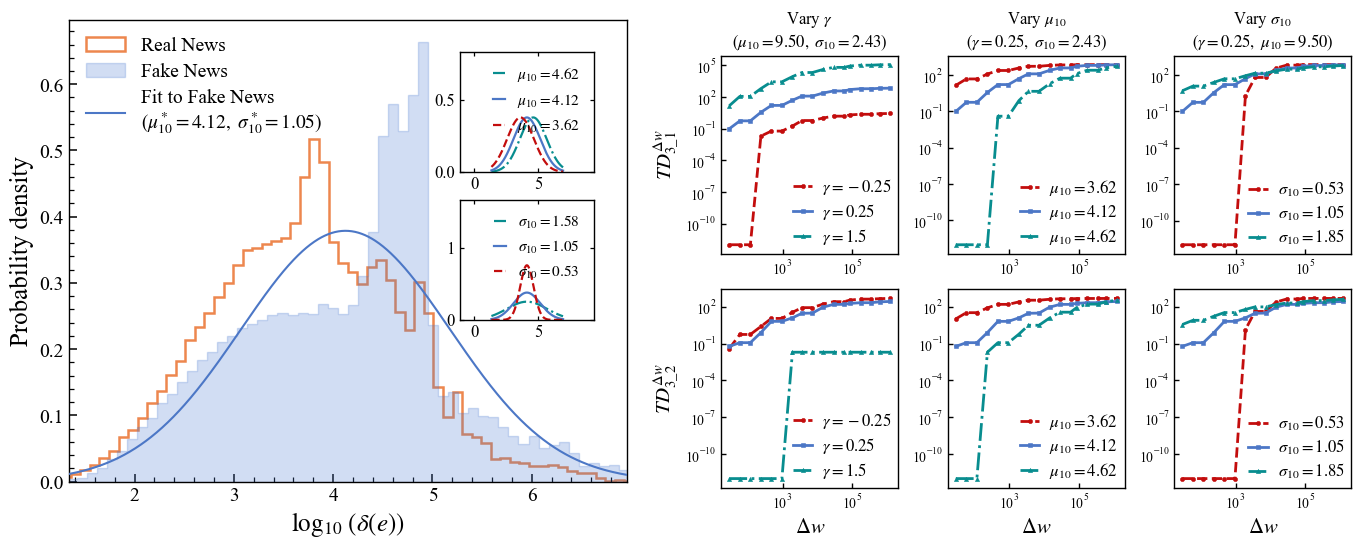

[log10-domain] FAKE: mu_10=4.1240, sigma_10=1.0535


NameError: name 'out_path' is not defined

In [25]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.ticker import LogLocator, NullFormatter

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型（与两段脚本保持一致） ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置（按需修改） ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度（减小/不变/增大）
rows_depth   = [1, 3, 5]   # 下排：深度模体度（减小/不变/增大）
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC, marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

# 统一控制右侧子图 legend 的线段长度与间距
LEGEND_HANDLE_LEN   = 1.15
LEGEND_HANDLE_TEXTP = 0.6
LEGEND_LABEL_SP     = 0.3

def read_csv_robust(path):
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个内嵌图 ==================
# 需要预先定义：new_list_real, new_list_fake（正数）
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左宽右窄 ==================
W, H = 15.0, 6
fig = plt.figure(figsize=(W, H))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.1, 1.0], wspace=0.18, figure=fig)

# ---------- 左侧大图 ----------
ax = fig.add_subplot(gs[0, 0])
bins = 80
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

ax.plot(
    x_fit, pdf_f,
    color=COLOR_BASE, linestyle=LS_BASE,
    label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
    zorder=3
)

ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=18)
ax.set_ylabel("Probability density", fontsize=18)

# 只保留下方和左侧刻度；去掉上方和右侧刻度
ax.tick_params(
    axis="both", which="major",
    labelsize=14, length=6, width=1.1,
    top=False, right=False
)
ax.minorticks_on()
ax.tick_params(
    axis="both", which="minor",
    length=3.5, width=0.9,
    top=False, right=False
)

for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=14, labelspacing=0.4)

# ==== 内嵌图范围控制 ====
INSET_X_SIGMA = 5.0   # x 轴展示的 σ 倍数
INSET_Y_MULT  = 2.2   # y 轴上限 = 峰值 * 该系数
INSET_LW      = 1.6   # 内嵌曲线线宽
INSET_HANDLE_LEN = 0.8  # 内嵌图 legend 曲线符号长度

# ---- 内嵌 1（上）：μ 灵敏度 ----
# 这里缩短子图长度和高度：宽从 0.33 -> 0.24，高从 0.32 -> 0.26，位置稍微右上移一点
ax_in_mu = ax.inset_axes([0.70, 0.67, 0.24, 0.26])

x_in = np.linspace(xmin, xmax, 600)
for dmu, color, ls in [(+0.5, COLOR_INC, LS_INC),
                       (0.0,  COLOR_BASE, LS_BASE),
                       (-0.5, COLOR_DEC, LS_DEC)]:
    val = mu_f + dmu
    y_  = norm.pdf(x_in, val, sig_f)
    ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW,
                  label=fr"$\mu_{{10}}={val:.2f}$")

left_mu  = mu_f - INSET_X_SIGMA * sig_f
right_mu = mu_f + INSET_X_SIGMA * sig_f
ax_in_mu.set_xlim(left_mu, right_mu)

ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

ax_in_mu.locator_params(axis="x", nbins=3)
ax_in_mu.locator_params(axis="y", nbins=3)
ax_in_mu.margins(x=0.02)
ax_in_mu.tick_params(which="both", direction="in", length=3.0, width=0.9,
                     top=True, right=True, labelsize=12)
ax_in_mu.legend(
    frameon=False, loc="upper right", fontsize=11,
    handlelength=INSET_HANDLE_LEN
)

# ---- 内嵌 2（下）：σ 灵敏度 ----
# 同样缩短长度和高度：宽 0.24，高 0.26，和上图左右对齐
ax_in_sig = ax.inset_axes([0.70, 0.35, 0.24, 0.26])

for scale, color, ls in [(1.5, COLOR_INC,  LS_INC),
                         (1.0, COLOR_BASE, LS_BASE),
                         (0.5, COLOR_DEC,  LS_DEC)]:
    val = sig_f * scale
    y_  = norm.pdf(x_in, mu_f, val)
    ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW,
                   label=fr"$\sigma_{{10}}={val:.2f}$")

ax_in_sig.set_xlim(left_mu, right_mu)

ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

ax_in_sig.locator_params(axis="x", nbins=3)
ax_in_sig.locator_params(axis="y", nbins=3)
ax_in_sig.tick_params(which="both", direction="in", length=3.0, width=0.9,
                      top=True, right=True, labelsize=12)
ax_in_sig.legend(
    frameon=False, loc="upper right", fontsize=11,
    handlelength=INSET_HANDLE_LEN
)

# ---------- 右侧 2×3 小图矩阵 ----------
axes = np.empty((2, 3), dtype=object)
# 这里把 top 稍微下压、bottom 稍微上抬，整体减小右侧子图高度
gs_right = GridSpec(
    nrows=2, ncols=3,
    left=0.56, right=0.98,
    bottom=0.10, top=0.82,    # 原来 bottom=0.10, top=0.86
    wspace=0.28, hspace=0.18,
    figure=fig
)
for r in range(2):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs_right[r, c])

# ========= 绘制右侧子图 =========
for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    # 标题分两行显示：第一行 Vary ...，第二行固定参数
    axes[0, col].set_title(
        fr'Vary {sym}' + '\n' + fr'({fixed_text})',
        fontsize=12, pad=6
    )

    # 上排（广度）
    ax_t = axes[0, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=12, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

    # 下排（深度）
    ax_b = axes[1, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
    ax_b.legend(frameon=False, fontsize=12, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

# ================== 保存与显示 ==================
# out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8..pdf")
# out_path.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(out_path, bbox_inches='tight')
plt.show()

# print(f"[log10-domain] FAKE: mu_10={mu_f:.4f}, sigma_10={sig_f:.4f}")
# print(f"Saved to: {out_path}")


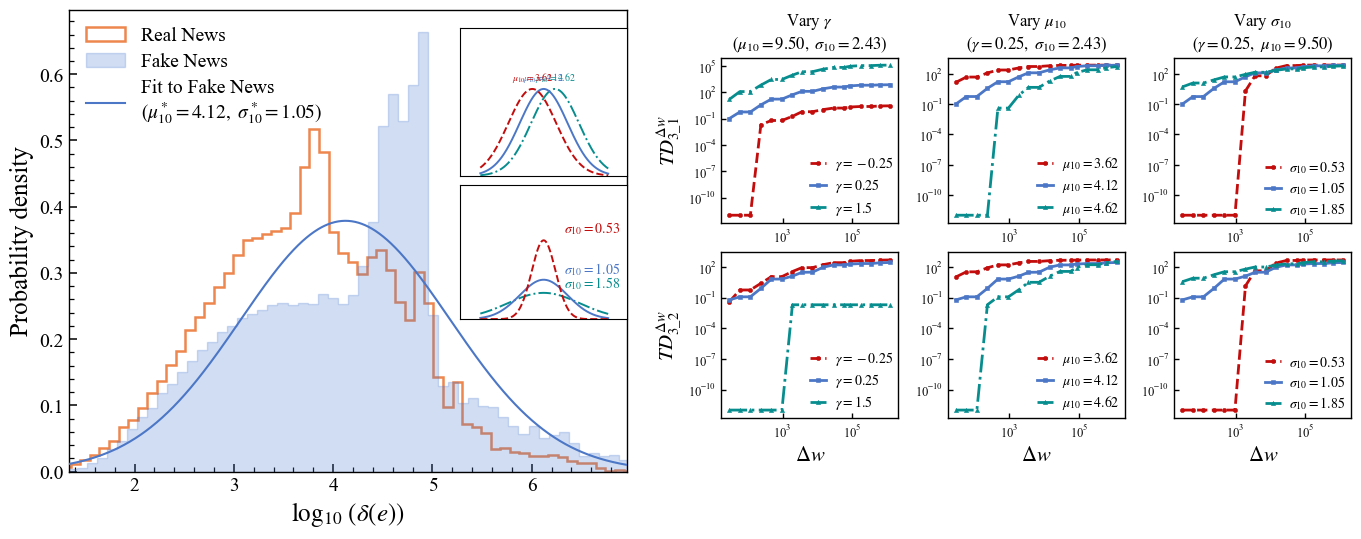

In [55]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型 ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置 ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度
rows_depth   = [1, 3, 5]   # 下排：深度模体度
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC, marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

# 统一控制右侧子图 legend
LEGEND_HANDLE_LEN   = 1.15
LEGEND_HANDLE_TEXTP = 0.6
LEGEND_LABEL_SP     = 0.3

def read_csv_robust(path):
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个“带标注”的极简内嵌图 ==================
# 需要预先定义：new_list_real, new_list_fake（正数）
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左宽右窄 ==================
W, H = 15.0, 6
fig = plt.figure(figsize=(W, H))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.1, 1.0], wspace=0.18, figure=fig)

# ---------- 左侧大图 ----------
ax = fig.add_subplot(gs[0, 0])
bins = 80
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

ax.plot(
    x_fit, pdf_f,
    color=COLOR_BASE, linestyle=LS_BASE,
    label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
    zorder=3
)

ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=18)
ax.set_ylabel("Probability density", fontsize=18)

# 只保留下方和左侧刻度
ax.tick_params(
    axis="both", which="major",
    labelsize=14, length=6, width=1.1,
    top=False, right=False
)
ax.minorticks_on()
ax.tick_params(
    axis="both", which="minor",
    length=3.5, width=0.9,
    top=False, right=False
)

for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=14, labelspacing=0.4)

# ==== 内嵌图范围控制：适度、清晰 ====
INSET_X_SIGMA = 3.5   # 横向范围
INSET_Y_MULT  = 1.7   # 纵轴放一点空间
INSET_LW      = 1.4   # 线宽
LABEL_FONTSIZE = 7          # μ 插图文字字号
LABEL_FONTSIZE_SIG = 10      # σ 插图文字字号（略大一点）
SIG_LABEL_X_SHIFT = 0.9    # σ 插图文字向右平移量

left_mu  = mu_f - INSET_X_SIGMA * sig_f
right_mu = mu_f + INSET_X_SIGMA * sig_f
x_in = np.linspace(xmin, xmax, 600)

# ---- 内嵌 1（上）：μ 灵敏度（小图+彩色文字标签）----
ax_in_mu = ax.inset_axes([0.70, 0.64, 0.30, 0.32])

mu_list = [mu_f + 0.5, mu_f, mu_f - 0.5]
mu_labels = [fr"$\mu_{{10}}={v:.2f}$" for v in mu_list]
for val, lab, color, ls in zip(
        mu_list,
        mu_labels,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, val, sig_f)
    ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)
    # 在峰值附近添加小文字标注
    y_peak = norm.pdf(val, val, sig_f)
    ax_in_mu.text(val, y_peak * 1.05, lab,
                  color=color, fontsize=LABEL_FONTSIZE,
                  ha="center", va="bottom")

ax_in_mu.set_xlim(left_mu, right_mu)
ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

# 去掉刻度与刻度标签，只保留边框
ax_in_mu.set_xticks([])
ax_in_mu.set_yticks([])
for spine in ax_in_mu.spines.values():
    spine.set_linewidth(0.8)

# ---- 内嵌 2（下）：σ 灵敏度（小图+彩色文字标签）----
ax_in_sig = ax.inset_axes([0.70, 0.33, 0.30, 0.29])

scale_list = [1.5, 1.0, 0.5]
sigma_list = [sig_f * s for s in scale_list]
sigma_labels = [fr"$\sigma_{{10}}={v:.2f}$" for v in sigma_list]

for val, lab, color, ls in zip(
        sigma_list,
        sigma_labels,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, mu_f, val)
    ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)
    # 峰值位置 x≈μ_f，把文字稍微往右挪一点、字号放大一点
    y_peak = norm.pdf(mu_f, mu_f, val)
    ax_in_sig.text(mu_f + SIG_LABEL_X_SHIFT, y_peak * 1.05, lab,
                   color=color, fontsize=LABEL_FONTSIZE_SIG,
                   ha="left", va="bottom")

ax_in_sig.set_xlim(left_mu, right_mu)
ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

ax_in_sig.set_xticks([])
ax_in_sig.set_yticks([])
for spine in ax_in_sig.spines.values():
    spine.set_linewidth(0.8)

# ---------- 右侧 2×3 小图矩阵 ----------
axes = np.empty((2, 3), dtype=object)
gs_right = GridSpec(
    nrows=2, ncols=3,
    left=0.56, right=0.98,
    bottom=0.20, top=0.80,   # 略矮一点
    wspace=0.28, hspace=0.18,
    figure=fig
)
for r in range(2):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs_right[r, c])

# ========= 绘制右侧子图 =========
for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    axes[0, col].set_title(
        fr'Vary {sym}' + '\n' + fr'({fixed_text})',
        fontsize=12, pad=6
    )

    # 上排（广度）
    ax_t = axes[0, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    ax_t.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

    # 下排（深度）
    ax_b = axes[1, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    ax_b.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
    ax_b.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

# ================== 保存与显示 ==================
# out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8_inset_labeled.pdf")  # 自行修改
# out_path.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(out_path, bbox_inches='tight')
plt.show()


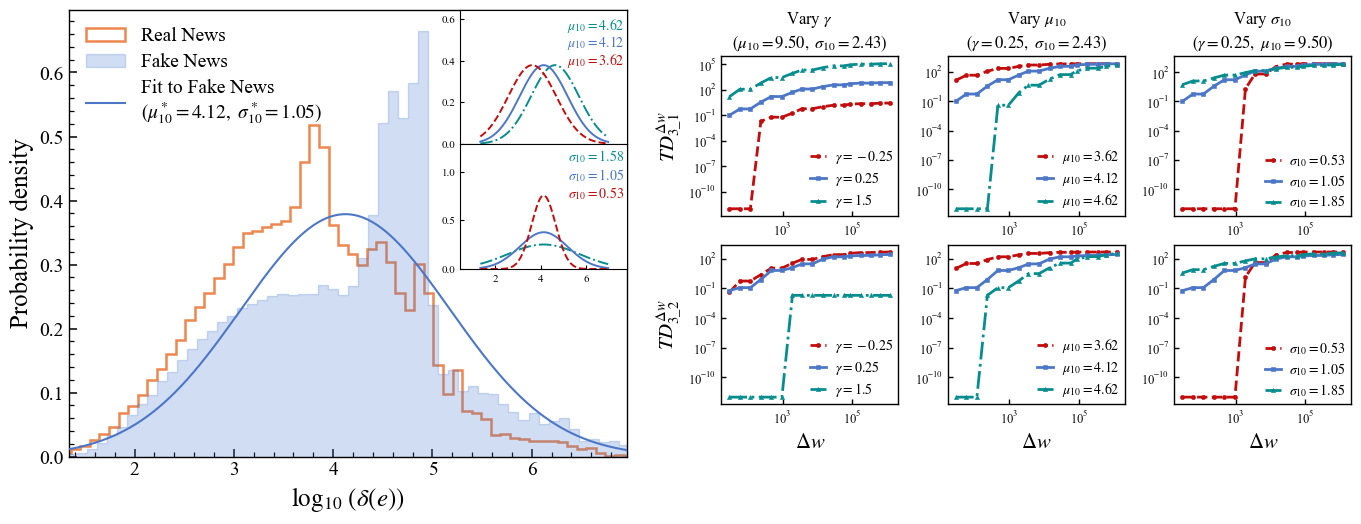

In [103]:
# # -*- coding: utf-8 -*-
# import os
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec
# from scipy.stats import norm

# # ================== 全局样式（Times + STIX；与既有脚本一致） ==================
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
#     "mathtext.fontset": "stix",
#     "axes.unicode_minus": False,
#     "axes.linewidth": 1.0,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.major.width": 1.0,
#     "ytick.major.width": 1.0,
#     "savefig.dpi": 600,
# })

# # ================== 配色与线型 ==================
# COLOR_INC  = '#088D8F'   # 增大
# COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
# COLOR_DEC  = '#C30D0D'   # 减小
# LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
# REAL_EDGE = '#ED874E'    # Real 轮廓
# FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# # ================== 右侧解耦图数据路径与配置 ==================
# base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
# cols = [
#     dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
#     dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
#     dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
# ]
# labels_per_file = {
#     '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
#     '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
#     '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
# }

# # x 轴时间尺度（秒）
# x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
#               28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
# X_LEN = len(x)
# rows_breadth = [0, 2, 4]   # 上排：广度模体度
# rows_depth   = [1, 3, 5]   # 下排：深度模体度
# style_map = {
#     'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
#     'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
#     'dec':  dict(color=COLOR_DEC,  ls=LS_DEC, marker='o'),
# }
# lw, ms, mew = 2.0, 3.0, 0.4
# eps = 1e-12  # log 轴安全下限

# # 统一控制右侧子图 legend
# LEGEND_HANDLE_LEN   = 1.15
# LEGEND_HANDLE_TEXTP = 0.6
# LEGEND_LABEL_SP     = 0.3

# def read_csv_robust(path):
#     df = pd.read_csv(path, header=None)
#     def fix(df_):
#         if df_.shape[1] == X_LEN:      return df_
#         if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
#         return None
#     out = fix(df)
#     if out is not None: return out
#     out = fix(df.T)
#     if out is not None: return out
#     raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

# def pick_rows(df, idxs):
#     return df.iloc[idxs, :].to_numpy(dtype=float)

# # ================== 左侧直方图 + 拟合 + 两个“带标注”的极简内嵌图 ==================
# # 需要预先定义：new_list_real, new_list_fake（正数）
# if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
#     raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

# x_real = np.asarray(new_list_real, dtype=float)
# x_fake = np.asarray(new_list_fake, dtype=float)
# x_real = x_real[x_real > 0]
# x_fake = x_fake[x_fake > 0]
# if x_real.size == 0 or x_fake.size == 0:
#     raise ValueError("过滤后数据为空，请确保输入包含正值。")

# z_real = np.log10(x_real)
# z_fake = np.log10(x_fake)
# mu_f, sig_f = norm.fit(z_fake)

# z_all = np.concatenate([z_real, z_fake])
# lo, hi = np.quantile(z_all, [0.01, 0.99])
# pad = 0.1 * max(hi - lo, 1e-6)
# xmin, xmax = lo - pad, hi + pad
# x_fit = np.linspace(xmin, xmax, 1000)
# pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# # ================== 组合画布：左宽右窄 ==================
# W, H = 15.0, 5.8
# fig = plt.figure(figsize=(W, H))
# gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.1, 1.0], wspace=0.18, figure=fig)

# # ---------- 左侧大图 ----------
# ax = fig.add_subplot(gs[0, 0])
# bins = 80
# ax.hist(z_real, bins=bins, density=True, histtype='step',
#         linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
# ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
#         alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
#         linewidth=1.0, label="Fake News", zorder=2)

# ax.plot(
#     x_fit, pdf_f,
#     color=COLOR_BASE, linestyle=LS_BASE,
#     label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
#     zorder=3
# )

# ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=18)
# ax.set_ylabel("Probability density", fontsize=18)

# # 只保留下方和左侧刻度
# ax.tick_params(
#     axis="both", which="major",
#     labelsize=14, length=6, width=1.1,
#     top=False, right=False
# )
# ax.minorticks_on()
# ax.tick_params(
#     axis="both", which="minor",
#     length=3.5, width=0.9,
#     top=False, right=False
# )

# for s in ["top", "right", "bottom", "left"]:
#     ax.spines[s].set_visible(True)
# ax.set_xlim(xmin, xmax)
# ax.legend(frameon=False, loc="upper left", fontsize=14, labelspacing=0.4)

# # ==== 内嵌图范围控制：适度、清晰 ====
# INSET_X_SIGMA = 3.5   # 横向范围
# INSET_Y_MULT  = 1.7   # 纵轴放一点空间
# INSET_LW      = 1.4   # 线宽
# LABEL_FONTSIZE_MU  = 10      # μ 插图文字字号（放大）
# LABEL_FONTSIZE_SIG = 10      # σ 插图文字字号
# SIG_LABEL_X_SHIFT  = 0.9    # σ 插图文字向右平移量

# left_mu  = mu_f - INSET_X_SIGMA * sig_f
# right_mu = mu_f + INSET_X_SIGMA * sig_f
# x_in = np.linspace(xmin, xmax, 600)

# # ---- 内嵌 1（上）：μ 灵敏度（标签一行排开）----
# ax_in_mu = ax.inset_axes([0.70, 0.70, 0.30, 0.30])

# mu_list = [mu_f + 0.5, mu_f, mu_f - 0.5]
# mu_labels = [fr"$\mu_{{10}}={v:.2f}$" for v in mu_list]

# # 先画三条曲线
# for val, color, ls in zip(
#         mu_list,
#         [COLOR_INC, COLOR_BASE, COLOR_DEC],
#         [LS_INC, LS_BASE, LS_DEC]):
#     y_  = norm.pdf(x_in, val, sig_f)
#     ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

# ax_in_mu.set_xlim(left_mu, right_mu)
# ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
# ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

# # 在最右侧偏上的位置竖直排成一列标签
# width_mu = right_mu - left_mu
# # 稍微再往图内缩一点，避免贴边
# x_label = right_mu - width_mu * 0.02  

# # 顶部位置更靠上，间距略小
# top_y  = ymax_mu * INSET_Y_MULT * 0.88  # 最上面的标签位置（接近顶部）
# step_y = ymax_mu * INSET_Y_MULT * 0.13   # 标签之间的间距

# y_positions = [top_y - i * step_y for i in range(3)]

# for ypos, lab, color in zip(y_positions, mu_labels,
#                             [COLOR_INC, COLOR_BASE, COLOR_DEC]):
#     ax_in_mu.text(x_label, ypos, lab,
#                   color=color, fontsize=LABEL_FONTSIZE_MU,
#                   ha="right", va="center")



# # 去掉刻度与刻度标签，只保留边框
# ax_in_mu.set_xticks([])
# ax_in_mu.set_yticks([])
# for spine in ax_in_mu.spines.values():
#     spine.set_linewidth(0.8)

# # ---- 内嵌 2（下）：σ 灵敏度（右侧上部竖排标签）----
# ax_in_sig = ax.inset_axes([0.70, 0.42, 0.30, 0.28])

# scale_list   = [1.5, 1.0, 0.5]
# sigma_list   = [sig_f * s for s in scale_list]
# sigma_labels = [fr"$\sigma_{{10}}={v:.2f}$" for v in sigma_list]

# # 先画三条曲线
# for val, color, ls in zip(
#         sigma_list,
#         [COLOR_INC, COLOR_BASE, COLOR_DEC],
#         [LS_INC, LS_BASE, LS_DEC]):
#     y_  = norm.pdf(x_in, mu_f, val)
#     ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

# ax_in_sig.set_xlim(left_mu, right_mu)
# ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
# ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

# # 在右侧上部竖直排成一列标签，间距均匀
# width_sig = right_mu - left_mu
# x_label   = right_mu - width_sig * 0.02   # 靠右一点

# top_y  = ymax_sig * INSET_Y_MULT * 0.90   # 最上面的标签位置（靠上）
# step_y = ymax_sig * INSET_Y_MULT * 0.15   # 标签之间的间距（可微调）

# for i, (lab, color) in enumerate(zip(sigma_labels,
#                                      [COLOR_INC, COLOR_BASE, COLOR_DEC])):
#     y_pos = top_y - i * step_y
#     ax_in_sig.text(x_label, y_pos, lab,
#                    color=color, fontsize=LABEL_FONTSIZE_SIG,
#                    ha="right", va="center")

# # 去掉刻度与刻度标签，只保留边框
# ax_in_sig.set_xticks([])
# ax_in_sig.set_yticks([])
# for spine in ax_in_sig.spines.values():
#     spine.set_linewidth(0.8)


# # ---------- 右侧 2×3 小图矩阵 ----------
# axes = np.empty((2, 3), dtype=object)
# gs_right = GridSpec(
#     nrows=2, ncols=3,
#     left=0.56, right=0.98,
#     bottom=0.20, top=0.80,   # 略矮一点
#     wspace=0.28, hspace=0.18,
#     figure=fig
# )
# for r in range(2):
#     for c in range(3):
#         axes[r, c] = fig.add_subplot(gs_right[r, c])

# # ========= 绘制右侧子图 =========
# for col, cfg in enumerate(cols):
#     fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
#     path = os.path.join(base_dir, fname)
#     df = read_csv_robust(path)

#     Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
#     Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
#     labels = labels_per_file[fname]

#     axes[0, col].set_title(
#         fr'Vary {sym}' + '\n' + fr'({fixed_text})',
#         fontsize=12, pad=6
#     )

#     # 上排（广度）
#     ax_t = axes[0, col]
#     for i, lab in enumerate(labels):
#         state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
#         st = style_map[state]
#         ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
#                   linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
#     ax_t.set_xscale('log'); ax_t.set_yscale('log')
#     ax_t.tick_params(axis="both", which="major", labelsize=9)
#     if col == 0:
#         ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
#     ax_t.legend(frameon=False, fontsize=10, loc='best',
#                 handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
#                 borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
#                 markerscale=1.0)

#     # 下排（深度）
#     ax_b = axes[1, col]
#     for i, lab in enumerate(labels):
#         state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
#         st = style_map[state]
#         ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
#                   linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
#     ax_b.set_xscale('log'); ax_b.set_yscale('log')
#     ax_b.tick_params(axis="both", which="major", labelsize=9)
#     if col == 0:
#         ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
#     ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
#     ax_b.legend(frameon=False, fontsize=10, loc='best',
#                 handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
#                 borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
#                 markerscale=1.0)

# # ================== 保存与显示 ==================
# # out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8_inset_labeled.pdf")
# # out_path.parent.mkdir(parents=True, exist_ok=True)
# # plt.savefig(out_path, bbox_inches='tight')
# plt.show()
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型 ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置 ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度
rows_depth   = [1, 3, 5]   # 下排：深度模体度
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC, marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

# 统一控制右侧子图 legend
LEGEND_HANDLE_LEN   = 1.15
LEGEND_HANDLE_TEXTP = 0.6
LEGEND_LABEL_SP     = 0.3

def read_csv_robust(path):
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个“带标注”的极简内嵌图 ==================
# 需要预先定义：new_list_real, new_list_fake（正数）
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左宽右窄 ==================
W, H = 15.0, 5.8
fig = plt.figure(figsize=(W, H))
gs = GridSpec(nrows=1, ncols=2, width_ratios=[1.1, 1.0], wspace=0.18, figure=fig)

# ---------- 左侧大图 ----------
ax = fig.add_subplot(gs[0, 0])
bins = 80
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

ax.plot(
    x_fit, pdf_f,
    color=COLOR_BASE, linestyle=LS_BASE,
    label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
    zorder=3
)

ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=18)
ax.set_ylabel("Probability density", fontsize=18)

# 只保留下方和左侧刻度
ax.tick_params(
    axis="both", which="major",
    labelsize=14, length=6, width=1.1,
    top=False, right=False
)
ax.minorticks_on()
ax.tick_params(
    axis="both", which="minor",
    length=3.5, width=0.9,
    top=False, right=False
)

for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=14, labelspacing=0.4)

# ==== 内嵌图范围控制：适度、清晰 ====
INSET_X_SIGMA = 3.5   # 横向范围
INSET_Y_MULT  = 1.7   # 纵轴放一点空间
INSET_LW      = 1.4   # 线宽
LABEL_FONTSIZE_MU  = 10      # μ 插图文字字号
LABEL_FONTSIZE_SIG = 10      # σ 插图文字字号
SIG_LABEL_X_SHIFT  = 0.9    # σ 插图文字向右平移量（当前未再使用，可保留）

left_mu  = mu_f - INSET_X_SIGMA * sig_f
right_mu = mu_f + INSET_X_SIGMA * sig_f
x_in = np.linspace(xmin, xmax, 600)

# ---- 内嵌 1（上）：μ 灵敏度 ----
ax_in_mu = ax.inset_axes([0.70, 0.70, 0.30, 0.30])

mu_list = [mu_f + 0.5, mu_f, mu_f - 0.5]
mu_labels = [fr"$\mu_{{10}}={v:.2f}$" for v in mu_list]

# 先画三条曲线
for val, color, ls in zip(
        mu_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, val, sig_f)
    ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_mu.set_xlim(left_mu, right_mu)
ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

# 在最右侧偏上的位置竖直排成一列标签
width_mu = right_mu - left_mu
x_label = right_mu - width_mu * 0.02

top_y  = ymax_mu * INSET_Y_MULT * 0.88
step_y = ymax_mu * INSET_Y_MULT * 0.13
y_positions = [top_y - i * step_y for i in range(3)]

for ypos, lab, color in zip(y_positions, mu_labels,
                            [COLOR_INC, COLOR_BASE, COLOR_DEC]):
    ax_in_mu.text(x_label, ypos, lab,
                  color=color, fontsize=LABEL_FONTSIZE_MU,
                  ha="right", va="center")

# μ inset：只保留左侧 y 轴刻度，不要 x 轴刻度
ax_in_mu.set_xticks([])  # 不显示 x 轴刻度
ax_in_mu.tick_params(
    axis="y", which="both",
    labelsize=8, length=3, width=0.8,
    right=False
)
for spine in ax_in_mu.spines.values():
    spine.set_linewidth(0.8)

# ---- 内嵌 2（下）：σ 灵敏度 ----
ax_in_sig = ax.inset_axes([0.70, 0.42, 0.30, 0.28])

scale_list   = [1.5, 1.0, 0.5]
sigma_list   = [sig_f * s for s in scale_list]
sigma_labels = [fr"$\sigma_{{10}}={v:.2f}$" for v in sigma_list]

# 先画三条曲线
for val, color, ls in zip(
        sigma_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, mu_f, val)
    ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_sig.set_xlim(left_mu, right_mu)
ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

# 在右侧上部竖直排成一列标签，间距均匀
width_sig = right_mu - left_mu
x_label   = right_mu - width_sig * 0.02

top_y  = ymax_sig * INSET_Y_MULT * 0.90
step_y = ymax_sig * INSET_Y_MULT * 0.15

for i, (lab, color) in enumerate(zip(sigma_labels,
                                     [COLOR_INC, COLOR_BASE, COLOR_DEC])):
    y_pos = top_y - i * step_y
    ax_in_sig.text(x_label, y_pos, lab,
                   color=color, fontsize=LABEL_FONTSIZE_SIG,
                   ha="right", va="center")

# σ inset：左侧 y + 下侧 x 都有刻度，字号略小
ax_in_sig.tick_params(
    axis="both", which="both",
    labelsize=8, length=3, width=0.8,
    top=False, right=False
)
for spine in ax_in_sig.spines.values():
    spine.set_linewidth(0.8)

# ---------- 右侧 2×3 小图矩阵 ----------
axes = np.empty((2, 3), dtype=object)
gs_right = GridSpec(
    nrows=2, ncols=3,
    left=0.56, right=0.98,
    bottom=0.20, top=0.80,
    wspace=0.28, hspace=0.18,
    figure=fig
)
for r in range(2):
    for c in range(3):
        axes[r, c] = fig.add_subplot(gs_right[r, c])

# ========= 绘制右侧子图 =========
for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    axes[0, col].set_title(
        fr'Vary {sym}' + '\n' + fr'({fixed_text})',
        fontsize=12, pad=6
    )

    # 上排（广度）
    ax_t = axes[0, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    ax_t.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

    # 下排（深度）
    ax_b = axes[1, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    ax_b.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
    ax_b.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

# ================== 保存与显示 ==================
# out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8_inset_labeled.pdf")
# out_path.parent.mkdir(parents=True, exist_ok=True)
# plt.savefig(out_path, bbox_inches='tight')
plt.show()


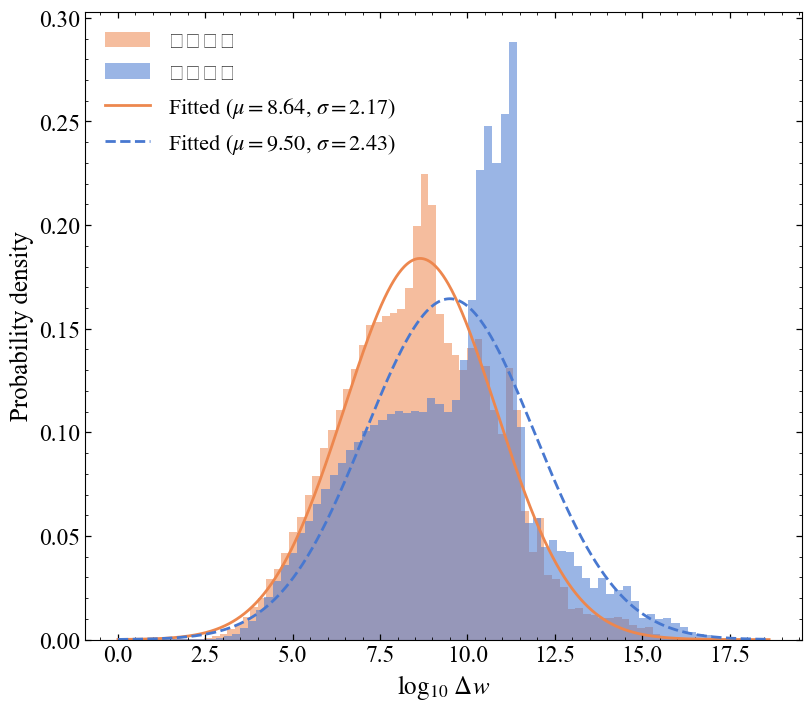

In [99]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# ——可选：彻底复位任何之前设置的样式，防止被其它库改色板
plt.style.use('default')

# ====== Global style ======
plt.rcParams.update({
    "font.family": "Times New Roman",
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "figure.figsize": (8, 7),
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "lines.linewidth": 1.8,
    "savefig.dpi": 600
})

# ====== Colors: 蓝-橙（直方图与曲线保持一致）======
BLUE   = '#4878D0'   # 你示例图的蓝
ORANGE = '#ED874E'   # 你示例图的橙

REAL_HIST = ORANGE   # 虚假信息（如果你想反过来就互换这两行）
FAKE_HIST = BLUE
REAL_LINE = ORANGE   # << 改：曲线颜色与对应直方图一致
FAKE_LINE = BLUE     # << 改

# ====== Data (expects new_list_real / new_list_fake defined) ======
new_list_1 = np.asarray(new_list_real)   # Real
new_list_2 = np.asarray(new_list_fake)   # Fake
new_list_1 = new_list_1[new_list_1 > 0]
new_list_2 = new_list_2[new_list_2 > 0]
data_1 = np.log(new_list_1)
data_2 = np.log(new_list_2)

mu1, sigma1 = norm.fit(data_1)
mu2, sigma2 = norm.fit(data_2)

xmin = min(data_1.min(), data_2.min())
xmax = max(data_1.max(), data_2.max())
x = np.linspace(xmin, xmax, 1000)
pdf1 = norm.pdf(x, mu1, sigma1)
pdf2 = norm.pdf(x, mu2, sigma2)

MAIN_LABEL_FONTSIZE = 18
MAIN_TICK_FONTSIZE  = 17
MAIN_LEGEND_FONTSIZE = 16

fig, ax = plt.subplots(constrained_layout=True)

# 直方图（透明度略低，避免色彩叠加变脏）
ax.hist(data_1, bins=80, density=True, alpha=0.55, color=REAL_HIST, edgecolor='none', label="虚假信息")
ax.hist(data_2, bins=80, density=True, alpha=0.55, color=FAKE_HIST, edgecolor='none', label="真实信息")

# 拟合曲线（与直方图配色一致；蓝色可用虚线，橙色实线模仿示例）
ax.plot(x, pdf1, color=REAL_LINE, linestyle='-',  linewidth=2.0,
        label=fr"Fitted ($\mu={mu1:.2f}$, $\sigma={sigma1:.2f}$)")
ax.plot(x, pdf2, color=FAKE_LINE, linestyle='--', linewidth=2.0,
        label=fr"Fitted ($\mu={mu2:.2f}$, $\sigma={sigma2:.2f}$)")

ax.set_xlabel(r"$\log_{10}\,\Delta w$", fontsize=MAIN_LABEL_FONTSIZE)
ax.set_ylabel("Probability density", fontsize=MAIN_LABEL_FONTSIZE)

ax.tick_params(axis="both", which="major", direction="in", length=4, width=0.9,
               top=True, right=True, bottom=True, left=True, labelsize=MAIN_TICK_FONTSIZE)
ax.minorticks_on()
ax.tick_params(axis="both", which="minor", direction="in", length=2, width=0.6,
               top=True, right=True, bottom=True, left=True, labelsize=MAIN_TICK_FONTSIZE-2)

for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(True)

ax.legend(frameon=False, loc="upper left", fontsize=MAIN_LEGEND_FONTSIZE)

plt.show()


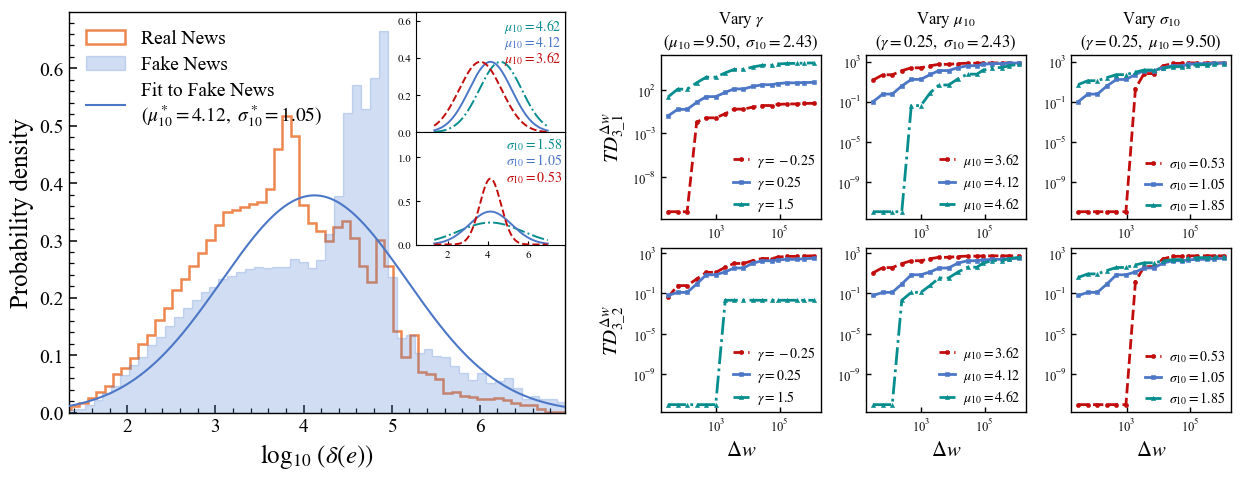

In [175]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.ticker import LogLocator  # 控制右侧子图 y 轴刻度密度

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型 ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置 ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度
rows_depth   = [1, 3, 5]   # 下排：深度模体度
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC, marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

# 统一控制右侧子图 legend
LEGEND_HANDLE_LEN   = 1.15
LEGEND_HANDLE_TEXTP = 0.6
LEGEND_LABEL_SP     = 0.3

def read_csv_robust(path):
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个“带标注”的极简内嵌图 ==================
# 需要预先定义：new_list_real, new_list_fake（正数）
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左窄右宽 ==================
W, H = 15.0, 6.2
fig = plt.figure(figsize=(W, H))
gs = GridSpec(
    nrows=1, ncols=2,
    width_ratios=[1, 1.15],   # 左窄右宽
    wspace=0.18,
    figure=fig
)

# ---------- 左侧：再套一层 subgridspec，把大图“压扁”一点 ----------
gs_left = gs[0, 0].subgridspec(
    nrows=3, ncols=1,
    height_ratios=[0.06, 1.9, 0.04]   # ↑ 中间更高、上下更窄
)

ax = fig.add_subplot(gs_left[1, 0])

bins = 80
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

ax.plot(
    x_fit, pdf_f,
    color=COLOR_BASE, linestyle=LS_BASE,
    label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
    zorder=3
)

ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=18)
ax.set_ylabel("Probability density", fontsize=18)

ax.tick_params(
    axis="both", which="major",
    labelsize=14, length=6, width=1.1,
    top=False, right=False
)
ax.minorticks_on()
ax.tick_params(
    axis="both", which="minor",
    length=3.5, width=0.9,
    top=False, right=False
)

for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=14, labelspacing=0.4)

# ==== 内嵌图范围控制：适度、清晰 ====
INSET_X_SIGMA = 3.5
INSET_Y_MULT  = 1.7
INSET_LW      = 1.4
LABEL_FONTSIZE_MU  = 10
LABEL_FONTSIZE_SIG = 10

left_mu  = mu_f - INSET_X_SIGMA * sig_f
right_mu = mu_f + INSET_X_SIGMA * sig_f
x_in = np.linspace(xmin, xmax, 600)

# ---- 内嵌 1：μ 灵敏度 ----
ax_in_mu = ax.inset_axes([0.70, 0.70, 0.30, 0.30])

mu_list = [mu_f + 0.5, mu_f, mu_f - 0.5]
mu_labels = [fr"$\mu_{{10}}={v:.2f}$" for v in mu_list]

for val, color, ls in zip(
        mu_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, val, sig_f)
    ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_mu.set_xlim(left_mu, right_mu)
ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

width_mu = right_mu - left_mu
x_label = right_mu - width_mu * 0.02
top_y  = ymax_mu * INSET_Y_MULT * 0.88
step_y = ymax_mu * INSET_Y_MULT * 0.13
y_positions = [top_y - i * step_y for i in range(3)]

for ypos, lab, color in zip(y_positions, mu_labels,
                            [COLOR_INC, COLOR_BASE, COLOR_DEC]):
    ax_in_mu.text(x_label, ypos, lab,
                  color=color, fontsize=LABEL_FONTSIZE_MU,
                  ha="right", va="center")

ax_in_mu.set_xticks([])
ax_in_mu.tick_params(
    axis="y", which="both",
    labelsize=8, length=3, width=0.8,
    right=False
)
for spine in ax_in_mu.spines.values():
    spine.set_linewidth(0.8)

# ---- 内嵌 2：σ 灵敏度 ----
ax_in_sig = ax.inset_axes([0.70, 0.42, 0.30, 0.28])

scale_list   = [1.5, 1.0, 0.5]
sigma_list   = [sig_f * s for s in scale_list]
sigma_labels = [fr"$\sigma_{{10}}={v:.2f}$" for v in sigma_list]

for val, color, ls in zip(
        sigma_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, mu_f, val)
    ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_sig.set_xlim(left_mu, right_mu)
ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

width_sig = right_mu - left_mu
x_label   = right_mu - width_sig * 0.02
top_y  = ymax_sig * INSET_Y_MULT * 0.90
step_y = ymax_sig * INSET_Y_MULT * 0.15

for i, (lab, color) in enumerate(zip(sigma_labels,
                                     [COLOR_INC, COLOR_BASE, COLOR_DEC])):
    y_pos = top_y - i * step_y
    ax_in_sig.text(x_label, y_pos, lab,
                   color=color, fontsize=LABEL_FONTSIZE_SIG,
                   ha="right", va="center")

ax_in_sig.tick_params(
    axis="both", which="both",
    labelsize=8, length=3, width=0.8,
    top=False, right=False
)
for spine in ax_in_sig.spines.values():
    spine.set_linewidth(0.8)

# ---------- 右侧 2×3 小图矩阵 ----------
axes = np.empty((2, 3), dtype=object)
gs_right = gs[0, 1].subgridspec(
    nrows=4, ncols=3,
    height_ratios=[0.14, 0.42, 0.42, 0.02],
    wspace=0.28,
    hspace=0.30
)


for c in range(3):
    axes[0, c] = fig.add_subplot(gs_right[1, c])  # 上排
    axes[1, c] = fig.add_subplot(gs_right[2, c])  # 下排


# ========= 绘制右侧子图 =========
for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    axes[0, col].set_title(
        fr'Vary {sym}' + '\n' + fr'({fixed_text})',
        fontsize=12, pad=6
    )

    # 上排（广度）
    ax_t = axes[0, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    ax_t.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_t.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

    # 下排（深度）
    ax_b = axes[1, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    ax_b.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_b.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
    ax_b.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

# ================== 保存与显示 ==================
out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8_inset_labeled.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, bbox_inches='tight')
plt.show()


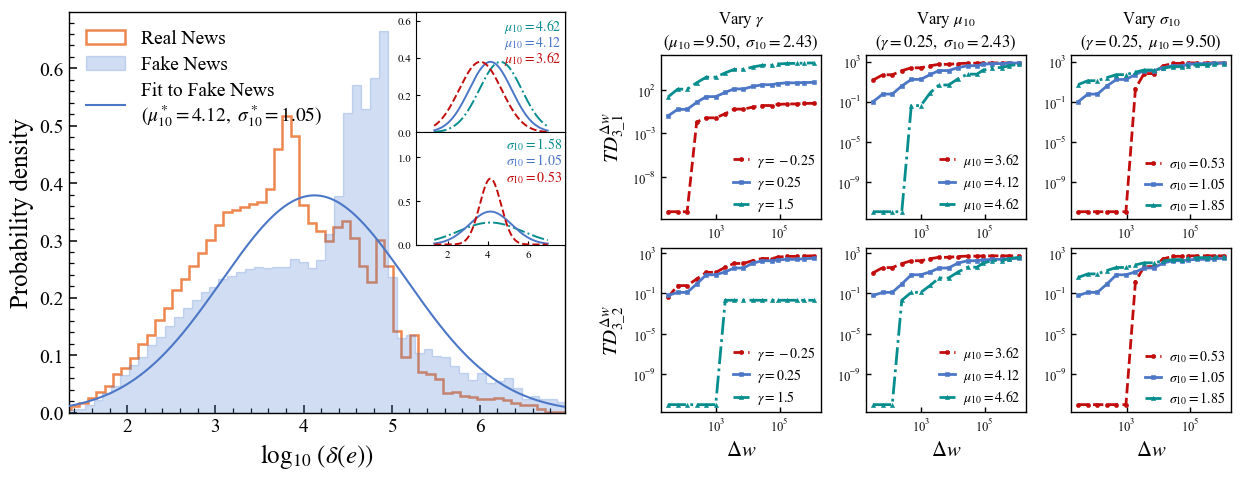

In [177]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.ticker import LogLocator  # 控制右侧子图 y 轴刻度密度

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型 ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置 ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度
rows_depth   = [1, 3, 5]   # 下排：深度模体度
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC, marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

# 统一控制右侧子图 legend
LEGEND_HANDLE_LEN   = 1.15
LEGEND_HANDLE_TEXTP = 0.6
LEGEND_LABEL_SP     = 0.3

def read_csv_robust(path):
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个“带标注”的极简内嵌图 ==================
# 需要预先定义：new_list_real, new_list_fake（正数）
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左窄右宽 ==================
W, H = 15.0, 6.2
fig = plt.figure(figsize=(W, H))
gs = GridSpec(
    nrows=1, ncols=2,
    width_ratios=[1, 1.15],   # 左窄右宽
    wspace=0.18,
    figure=fig
)

# ---------- 左侧：再套一层 subgridspec，把大图“压扁”一点 ----------
gs_left = gs[0, 0].subgridspec(
    nrows=3, ncols=1,
    height_ratios=[0.06, 1.9, 0.04]   # ↑ 中间更高、上下更窄
)

ax = fig.add_subplot(gs_left[1, 0])

bins = 80
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

ax.plot(
    x_fit, pdf_f,
    color=COLOR_BASE, linestyle=LS_BASE,
    label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
    zorder=3
)

ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=18)
ax.set_ylabel("Probability density", fontsize=18)

ax.tick_params(
    axis="both", which="major",
    labelsize=14, length=6, width=1.1,
    top=False, right=False
)
ax.minorticks_on()
ax.tick_params(
    axis="both", which="minor",
    length=3.5, width=0.9,
    top=False, right=False
)

for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=14, labelspacing=0.4)

# ==== 内嵌图范围控制：适度、清晰 ====
INSET_X_SIGMA = 3.5
INSET_Y_MULT  = 1.7
INSET_LW      = 1.4
LABEL_FONTSIZE_MU  = 10
LABEL_FONTSIZE_SIG = 10

left_mu  = mu_f - INSET_X_SIGMA * sig_f
right_mu = mu_f + INSET_X_SIGMA * sig_f
x_in = np.linspace(xmin, xmax, 600)

# ---- 内嵌 1：μ 灵敏度 ----
ax_in_mu = ax.inset_axes([0.70, 0.70, 0.30, 0.30])

mu_list = [mu_f + 0.5, mu_f, mu_f - 0.5]
mu_labels = [fr"$\mu_{{10}}={v:.2f}$" for v in mu_list]

for val, color, ls in zip(
        mu_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, val, sig_f)
    ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_mu.set_xlim(left_mu, right_mu)
ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

width_mu = right_mu - left_mu
x_label = right_mu - width_mu * 0.02
top_y  = ymax_mu * INSET_Y_MULT * 0.88
step_y = ymax_mu * INSET_Y_MULT * 0.13
y_positions = [top_y - i * step_y for i in range(3)]

for ypos, lab, color in zip(y_positions, mu_labels,
                            [COLOR_INC, COLOR_BASE, COLOR_DEC]):
    ax_in_mu.text(
        x_label, ypos, lab,
        color=color, fontsize=LABEL_FONTSIZE_MU,
        fontweight='bold',            # ★ 加粗 μ inset 标签
        ha="right", va="center"
    )

ax_in_mu.set_xticks([])
ax_in_mu.tick_params(
    axis="y", which="both",
    labelsize=8, length=3, width=0.8,
    right=False
)
for spine in ax_in_mu.spines.values():
    spine.set_linewidth(0.8)

# ---- 内嵌 2：σ 灵敏度 ----
ax_in_sig = ax.inset_axes([0.70, 0.42, 0.30, 0.28])

scale_list   = [1.5, 1.0, 0.5]
sigma_list   = [sig_f * s for s in scale_list]
sigma_labels = [fr"$\sigma_{{10}}={v:.2f}$" for v in sigma_list]

for val, color, ls in zip(
        sigma_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, mu_f, val)
    ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_sig.set_xlim(left_mu, right_mu)
ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

width_sig = right_mu - left_mu
x_label   = right_mu - width_sig * 0.02
top_y  = ymax_sig * INSET_Y_MULT * 0.90
step_y = ymax_sig * INSET_Y_MULT * 0.15

for i, (lab, color) in enumerate(zip(sigma_labels,
                                     [COLOR_INC, COLOR_BASE, COLOR_DEC])):
    y_pos = top_y - i * step_y
    ax_in_sig.text(
        x_label, y_pos, lab,
        color=color, fontsize=LABEL_FONTSIZE_SIG,
        fontweight='bold',           # ★ 加粗 σ inset 标签
        ha="right", va="center"
    )

ax_in_sig.tick_params(
    axis="both", which="both",
    labelsize=8, length=3, width=0.8,
    top=False, right=False
)
for spine in ax_in_sig.spines.values():
    spine.set_linewidth(0.8)

# ---------- 右侧 2×3 小图矩阵 ----------
axes = np.empty((2, 3), dtype=object)
gs_right = gs[0, 1].subgridspec(
    nrows=4, ncols=3,
    height_ratios=[0.14, 0.42, 0.42, 0.02],
    wspace=0.28,
    hspace=0.30
)

for c in range(3):
    axes[0, c] = fig.add_subplot(gs_right[1, c])  # 上排
    axes[1, c] = fig.add_subplot(gs_right[2, c])  # 下排

# ========= 绘制右侧子图 =========
for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    axes[0, col].set_title(
        fr'Vary {sym}' + '\n' + fr'({fixed_text})',
        fontsize=12, pad=6
    )

    # 上排（广度）
    ax_t = axes[0, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    ax_t.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_t.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

    # 下排（深度）
    ax_b = axes[1, col]
    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    ax_b.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_b.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
    ax_b.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

# ================== 保存与显示 ==================
out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8_inset_labeled.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, bbox_inches='tight')
plt.show()


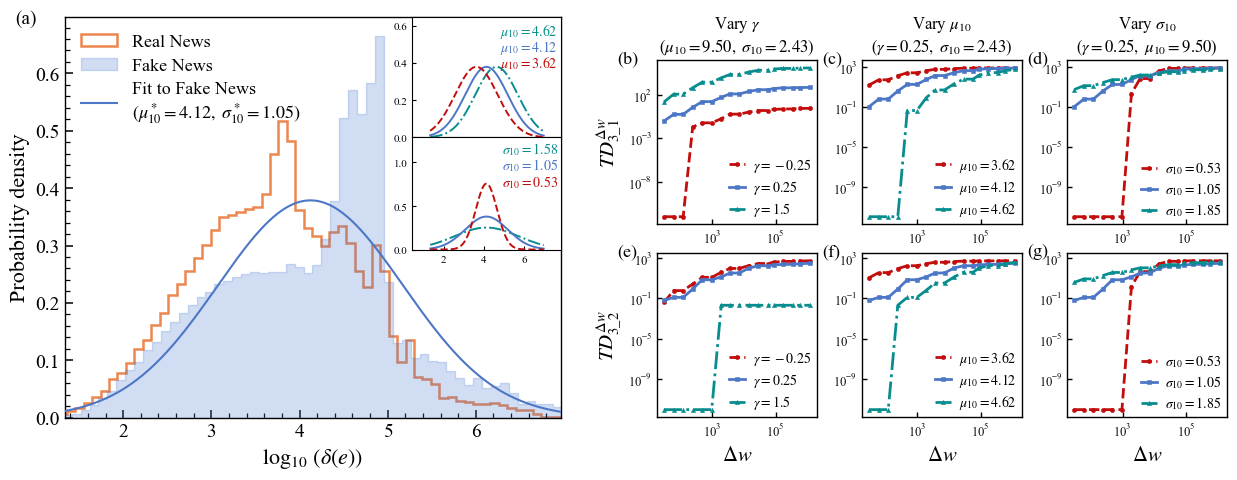

In [15]:
# -*- coding: utf-8 -*-
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.ticker import LogLocator  # 控制右侧子图 y 轴刻度密度

# ================== 全局样式（Times + STIX；与既有脚本一致） ==================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman No9 L"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "savefig.dpi": 600,
})

# ================== 配色与线型 ==================
COLOR_INC  = '#088D8F'   # 增大
COLOR_BASE = '#4C77C6'   # 不变（主图拟合线 & 小图基准）
COLOR_DEC  = '#C30D0D'   # 减小
LS_INC, LS_BASE, LS_DEC = '-.', '-', '--'
REAL_EDGE = '#ED874E'    # Real 轮廓
FAKE_FILL = '#4878D0'    # Fake 填充(直方图)

# ================== 右侧解耦图数据路径与配置 ==================
base_dir = r'E:\大论文-第一部分\小论文数据\模型解耦分析 - 副本'
cols = [
    dict(fname='改变gamma.csv',  sym=r'$\gamma$',      fixed_text=r'$\mu_{10}=9.50,\ \sigma_{10}=2.43$'),
    dict(fname='改变mu.csv',     sym=r'$\mu_{10}$',    fixed_text=r'$\gamma=0.25,\ \sigma_{10}=2.43$'),
    dict(fname='改变sigma.csv',  sym=r'$\sigma_{10}$', fixed_text=r'$\gamma=0.25,\ \mu_{10}=9.50$'),
]
labels_per_file = {
    '改变gamma.csv': [r'$\gamma=-0.25$',     r'$\gamma=0.25$',     r'$\gamma=1.5$'],
    '改变mu.csv':    [r'$\mu_{10}=3.62$',    r'$\mu_{10}=4.12$',   r'$\mu_{10}=4.62$'],
    '改变sigma.csv': [r'$\sigma_{10}=0.53$', r'$\sigma_{10}=1.05$', r'$\sigma_{10}=1.85$'],
}

# x 轴时间尺度（秒）
x = np.array([30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400,
              28800, 57600, 86400, 172800, 345600, 604800, 1209600], dtype=float)
X_LEN = len(x)
rows_breadth = [0, 2, 4]   # 上排：广度模体度
rows_depth   = [1, 3, 5]   # 下排：深度模体度
style_map = {
    'inc':  dict(color=COLOR_INC,  ls=LS_INC,  marker='^'),
    'base': dict(color=COLOR_BASE, ls=LS_BASE, marker='s'),
    'dec':  dict(color=COLOR_DEC,  ls=LS_DEC, marker='o'),
}
lw, ms, mew = 2.0, 3.0, 0.4
eps = 1e-12  # log 轴安全下限

# 统一控制右侧子图 legend
LEGEND_HANDLE_LEN   = 1.15
LEGEND_HANDLE_TEXTP = 0.6
LEGEND_LABEL_SP     = 0.3

def read_csv_robust(path):
    df = pd.read_csv(path, header=None)
    def fix(df_):
        if df_.shape[1] == X_LEN:      return df_
        if df_.shape[1] == X_LEN + 1:  return df_.iloc[:, 1:]
        return None
    out = fix(df)
    if out is not None: return out
    out = fix(df.T)
    if out is not None: return out
    raise ValueError(f'{os.path.basename(path)} 维度不匹配：{df.shape}, x_len={X_LEN}')

def pick_rows(df, idxs):
    return df.iloc[idxs, :].to_numpy(dtype=float)

# ================== 左侧直方图 + 拟合 + 两个“带标注”的极简内嵌图 ==================
# 需要预先定义：new_list_real, new_list_fake（正数）
if 'new_list_real' not in globals() or 'new_list_fake' not in globals():
    raise NameError("请在运行本脚本前，定义 new_list_real 与 new_list_fake 两个一维数组（正数）。")

x_real = np.asarray(new_list_real, dtype=float)
x_fake = np.asarray(new_list_fake, dtype=float)
x_real = x_real[x_real > 0]
x_fake = x_fake[x_fake > 0]
if x_real.size == 0 or x_fake.size == 0:
    raise ValueError("过滤后数据为空，请确保输入包含正值。")

z_real = np.log10(x_real)
z_fake = np.log10(x_fake)
mu_f, sig_f = norm.fit(z_fake)

z_all = np.concatenate([z_real, z_fake])
lo, hi = np.quantile(z_all, [0.01, 0.99])
pad = 0.1 * max(hi - lo, 1e-6)
xmin, xmax = lo - pad, hi + pad
x_fit = np.linspace(xmin, xmax, 1000)
pdf_f = norm.pdf(x_fit, mu_f, sig_f)

# ================== 组合画布：左窄右宽 ==================
W, H = 15.0, 6.2
fig = plt.figure(figsize=(W, H))
gs = GridSpec(
    nrows=1, ncols=2,
    width_ratios=[1, 1.15],   # 左窄右宽
    wspace=0.18,
    figure=fig
)

# ---------- 左侧：再套一层 subgridspec，把大图“压扁”一点 ----------
gs_left = gs[0, 0].subgridspec(
    nrows=3, ncols=1,
    height_ratios=[0.06, 1.9, 0.04]   # 中间主图高度 + 上下留白
)

ax = fig.add_subplot(gs_left[1, 0])

bins = 80
ax.hist(z_real, bins=bins, density=True, histtype='step',
        linewidth=1.8, color=REAL_EDGE, label="Real News", zorder=1)
ax.hist(z_fake, bins=bins, density=True, histtype='stepfilled',
        alpha=0.25, color=FAKE_FILL, edgecolor=FAKE_FILL,
        linewidth=1.0, label="Fake News", zorder=2)

ax.plot(
    x_fit, pdf_f,
    color=COLOR_BASE, linestyle=LS_BASE,
    label=fr"Fit to Fake News" "\n" fr"($\mu_{{10}}^*={mu_f:.2f},\ \sigma_{{10}}^*={sig_f:.2f}$)",
    zorder=3
)

ax.set_xlabel(r"$\log_{10}\,(\delta(e))$", fontsize=16)
ax.set_ylabel("Probability density", fontsize=16)

ax.tick_params(
    axis="both", which="major",
    labelsize=14, length=6, width=1.1,
    top=False, right=False
)
ax.minorticks_on()
ax.tick_params(
    axis="both", which="minor",
    length=3.5, width=0.9,
    top=False, right=False
)

for s in ["top", "right", "bottom", "left"]:
    ax.spines[s].set_visible(True)
ax.set_xlim(xmin, xmax)
ax.legend(frameon=False, loc="upper left", fontsize=13, labelspacing=0.4)

# === Panel 标号：(a) 放在左侧大图轴外左上角 ===
ax.text(-0.10, 1.02, "(a)",
        transform=ax.transAxes,
        fontsize=14, fontweight="normal",
        ha="left", va="top",
        clip_on=False)

# ==== 内嵌图范围控制：适度、清晰 ====
INSET_X_SIGMA = 3.5
INSET_Y_MULT  = 1.7
INSET_LW      = 1.4
LABEL_FONTSIZE_MU  = 10
LABEL_FONTSIZE_SIG = 10

left_mu  = mu_f - INSET_X_SIGMA * sig_f
right_mu = mu_f + INSET_X_SIGMA * sig_f
x_in = np.linspace(xmin, xmax, 600)

# ---- 内嵌 1：μ 灵敏度 ----
ax_in_mu = ax.inset_axes([0.70, 0.70, 0.30, 0.30])

mu_list = [mu_f + 0.5, mu_f, mu_f - 0.5]
mu_labels = [fr"$\mu_{{10}}={v:.2f}$" for v in mu_list]

for val, color, ls in zip(
        mu_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, val, sig_f)
    ax_in_mu.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_mu.set_xlim(left_mu, right_mu)
ymax_mu = max(ln.get_ydata().max() for ln in ax_in_mu.lines)
ax_in_mu.set_ylim(0, ymax_mu * INSET_Y_MULT)

width_mu = right_mu - left_mu
x_label = right_mu - width_mu * 0.02
top_y  = ymax_mu * INSET_Y_MULT * 0.88
step_y = ymax_mu * INSET_Y_MULT * 0.13
y_positions = [top_y - i * step_y for i in range(3)]

for ypos, lab, color in zip(y_positions, mu_labels,
                            [COLOR_INC, COLOR_BASE, COLOR_DEC]):
    ax_in_mu.text(x_label, ypos, lab,
                  color=color, fontsize=LABEL_FONTSIZE_MU,
                  ha="right", va="center", fontweight="bold")

ax_in_mu.set_xticks([])
ax_in_mu.tick_params(
    axis="y", which="both",
    labelsize=8, length=3, width=0.8,
    right=False
)
for spine in ax_in_mu.spines.values():
    spine.set_linewidth(0.8)

# ---- 内嵌 2：σ 灵敏度 ----
ax_in_sig = ax.inset_axes([0.70, 0.42, 0.30, 0.28])

scale_list   = [1.5, 1.0, 0.5]
sigma_list   = [sig_f * s for s in scale_list]
sigma_labels = [fr"$\sigma_{{10}}={v:.2f}$" for v in sigma_list]

for val, color, ls in zip(
        sigma_list,
        [COLOR_INC, COLOR_BASE, COLOR_DEC],
        [LS_INC, LS_BASE, LS_DEC]):
    y_  = norm.pdf(x_in, mu_f, val)
    ax_in_sig.plot(x_in, y_, color=color, linestyle=ls, linewidth=INSET_LW)

ax_in_sig.set_xlim(left_mu, right_mu)
ymax_sig = max(ln.get_ydata().max() for ln in ax_in_sig.lines)
ax_in_sig.set_ylim(0, ymax_sig * INSET_Y_MULT)

width_sig = right_mu - left_mu
x_label   = right_mu - width_sig * 0.02
top_y  = ymax_sig * INSET_Y_MULT * 0.90
step_y = ymax_sig * INSET_Y_MULT * 0.15

for i, (lab, color) in enumerate(zip(sigma_labels,
                                     [COLOR_INC, COLOR_BASE, COLOR_DEC])):
    y_pos = top_y - i * step_y
    ax_in_sig.text(x_label, y_pos, lab,
                   color=color, fontsize=LABEL_FONTSIZE_SIG,
                   ha="right", va="center", fontweight="bold")

ax_in_sig.tick_params(
    axis="both", which="both",
    labelsize=8, length=3, width=0.8,
    top=False, right=False
)
for spine in ax_in_sig.spines.values():
    spine.set_linewidth(0.8)

# ---------- 右侧 2×3 小图矩阵 ----------
axes = np.empty((2, 3), dtype=object)
gs_right = gs[0, 1].subgridspec(
    nrows=4, ncols=3,
    height_ratios=[0.14, 0.42, 0.42, 0.02],
    wspace=0.28,
    hspace=0.30
)

for c in range(3):
    axes[0, c] = fig.add_subplot(gs_right[1, c])  # 上排
    axes[1, c] = fig.add_subplot(gs_right[2, c])  # 下排

# 右侧 panel 标号：b–g
panel_labels_top = ["(b)", "(c)", "(d)"]
panel_labels_bot = ["(e)", "(f)", "(g)"]

# ========= 绘制右侧子图 =========
for col, cfg in enumerate(cols):
    fname, sym, fixed_text = cfg['fname'], cfg['sym'], cfg['fixed_text']
    path = os.path.join(base_dir, fname)
    df = read_csv_robust(path)

    Y_top = np.where(pick_rows(df, rows_breadth) <= 0, eps, pick_rows(df, rows_breadth))
    Y_bot = np.where(pick_rows(df, rows_depth)   <= 0, eps, pick_rows(df, rows_depth))
    labels = labels_per_file[fname]

    # 上排（广度）
    ax_t = axes[0, col]
    ax_t.set_title(
        fr'Vary {sym}' + '\n' + fr'({fixed_text})',
        fontsize=12, pad=6
    )
    # panel 标号：轴外左上角（整体再偏左上）
    ax_t.text(-0.25, 1.06, panel_labels_top[col],
              transform=ax_t.transAxes,
              fontsize=13, fontweight="normal",
              ha="left", va="top",
              clip_on=False)

    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_t.plot(x, Y_top[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_t.set_xscale('log'); ax_t.set_yscale('log')
    ax_t.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_t.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_t.set_ylabel(r'$TD^{\Delta w}_{3\_1}$', fontsize=15)
    ax_t.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

    # 下排（深度）
    ax_b = axes[1, col]
    # panel 标号：轴外左上角（整体再偏左上）
    ax_b.text(-0.25, 1.06, panel_labels_bot[col],
              transform=ax_b.transAxes,
              fontsize=13, fontweight="normal",
              ha="left", va="top",
              clip_on=False)

    for i, lab in enumerate(labels):
        state = 'dec' if i == 0 else ('base' if i == 1 else 'inc')
        st = style_map[state]
        ax_b.plot(x, Y_bot[i], color=st['color'], linestyle=st['ls'], marker=st['marker'],
                  linewidth=lw, markersize=ms, markeredgewidth=mew, label=lab)
    ax_b.set_xscale('log'); ax_b.set_yscale('log')
    ax_b.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
    ax_b.tick_params(axis="both", which="major", labelsize=9)
    if col == 0:
        ax_b.set_ylabel(r'$TD^{\Delta w}_{3\_2}$', fontsize=15)
    ax_b.set_xlabel(r'$\Delta w$', fontsize=15)
    ax_b.legend(frameon=False, fontsize=10, loc='best',
                handlelength=LEGEND_HANDLE_LEN, handletextpad=LEGEND_HANDLE_TEXTP,
                borderaxespad=0.0, columnspacing=1.0, labelspacing=LEGEND_LABEL_SP,
                markerscale=1.0)

# ================== 保存与显示 ==================
out_path = Path(r"C:\Users\Administrator\Desktop\人工智能\Fig8_inset_labeled.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, bbox_inches='tight')
plt.show()


## 修改sigma

对数空间正态拟合参数：
μ (mean): 9.495900
σ (std):  2.425723
生成的随机数（示例展示前两行）：
原始σ：
 [[     229  1741034   108749    46068    47704      660    10541    20318
  15123084    50812    28016      109     6190    45411     3281      801
      7606    16714       59      868    27745     1480    15778       87
      4116   277678      964     1231      226   251355    12650      931
     17242     3480    17406     1434      744    13512     9064     4320
       414     1016      289    14270    77867     1162      682   373847
     20396    13864    14038   115130    34837    33787    20991     3789
     19383    44545  2383854   164620      846      706     1325       51
    191442      333      347     2935      680      496     2183     1178
     75699     3524     5080     7018   743248 17947127    61798   241101
    476996   155959   159833     2382    21378  8422016   135568   246012
       189    22184    17603    61144   269519     3248   511296    28915
      1985   104086     3559  1453752  

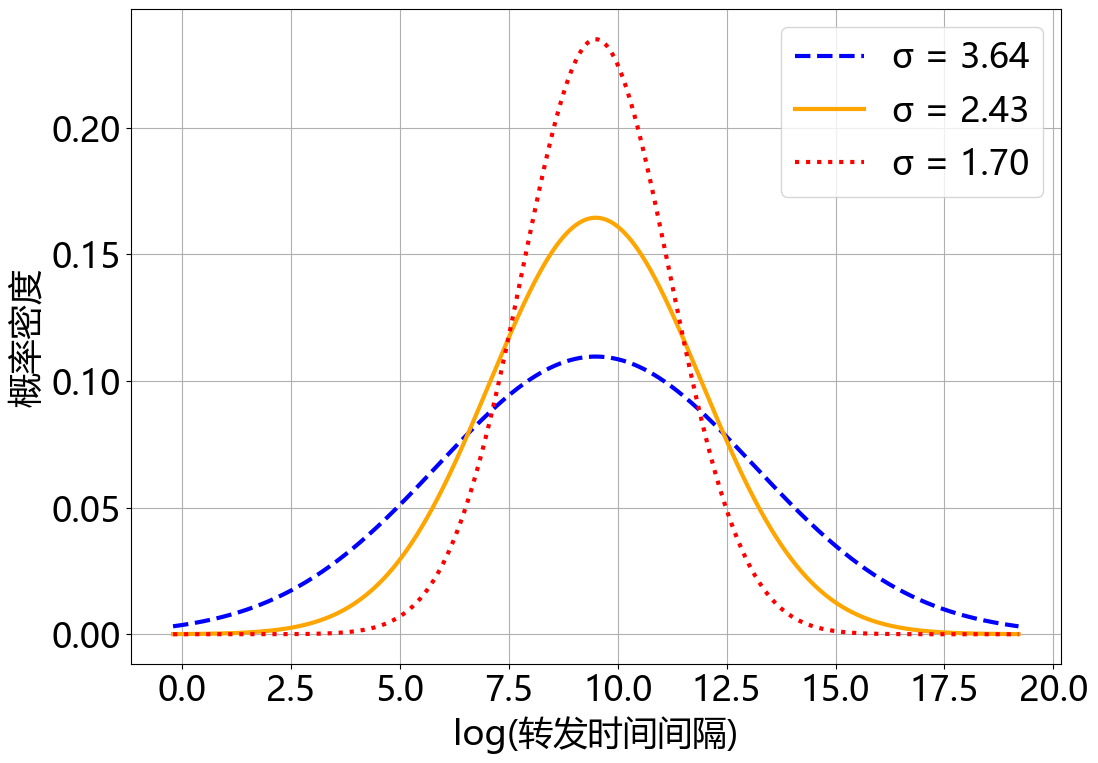

In [107]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# ===== 全局字体（保持你的设置）=====
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# ===== 1) 数据准备：从原始正值序列拟合对数正态参数 =====
# 假设 new_list_fake 是你的原始时间间隔数据（正值）
new_list_2 = np.array(new_list_fake, dtype=float)
new_list_2 = new_list_2[new_list_2 > 0]          # 仅保留正值
data_2 = np.log(new_list_2)                      # 对数空间

# 拟合 N(μ, σ) （对应原尺度 Lognormal(μ, σ)）
mean_2, std_2 = norm.fit(data_2)

print("对数空间正态拟合参数：")
print(f"μ (mean): {mean_2:.6f}")
print(f"σ (std):  {std_2:.6f}")

# ===== 2) 三条曲线：原σ、放大σ、缩小σ（在对数空间画 PDF）=====
# 为避免受极端值影响，曲线范围取 μ ± 4σ
x_values_2 = np.linspace(mean_2 - 4*std_2, mean_2 + 4*std_2, 1000)

# 原始σ
fitted_pdf_2 = norm.pdf(x_values_2, mean_2, std_2)

# 更稳健的放大/缩小方式（乘法缩放，避免 σ-1 ≤ 0）
std_increased = std_2 * 1.5
std_reduced   = max(std_2 * 0.7, 1e-6)

fitted_pdf_2_increased_std = norm.pdf(x_values_2, mean_2, std_increased)
fitted_pdf_2_reduced_std   = norm.pdf(x_values_2, mean_2, std_reduced)

# ===== 3) 生成样本：每组 50×499（与注释一致），并保证整数样本 ≥1 且减少重复 =====
n_samples = 50
m_per_sample = 499  # 每组生成 499 个随机数

# 在对数空间生成随机数（三种 σ）
rng = np.random.default_rng()  # 如需复现实验可改为 np.random.default_rng(42)
random_numbers_original_std  = rng.normal(mean_2, std_2,       size=(n_samples, m_per_sample))
random_numbers_increased_std = rng.normal(mean_2, std_increased, size=(n_samples, m_per_sample))
random_numbers_reduced_std   = rng.normal(mean_2, std_reduced,   size=(n_samples, m_per_sample))

# 指数还原到原始尺度（严格 > 0）
x_original  = np.exp(random_numbers_original_std)
x_increased = np.exp(random_numbers_increased_std)
x_reduced   = np.exp(random_numbers_reduced_std)

# 整数化：使用“随机舍入” floor(x + U[0,1])，显著减少并发的相同值；并强制下界为 1
def to_positive_int(arr_float):
    u = rng.uniform(0.0, 1.0, size=arr_float.shape)
    arr = np.floor(arr_float + u)
    arr = np.clip(arr, 1, np.iinfo(np.int64).max).astype(np.int64)
    return arr

random_numbers_original_std_int  = to_positive_int(x_original)
random_numbers_increased_std_int = to_positive_int(x_increased)
random_numbers_reduced_std_int   = to_positive_int(x_reduced)

# 自检（保证无 0/负数）
assert np.all(random_numbers_original_std_int  >= 1)
assert np.all(random_numbers_increased_std_int >= 1)
assert np.all(random_numbers_reduced_std_int   >= 1)

# 打印生成的随机数（如数据量大，可按需注释）
print("生成的随机数（示例展示前两行）：")
print("原始σ：\n",  random_numbers_original_std_int[:2])
print("σ放大：\n",  random_numbers_increased_std_int[:2])
print("σ缩小：\n",  random_numbers_reduced_std_int[:2])

# ===== 4) 绘图：对数空间的三条拟合曲线（与原风格一致）=====
plt.figure(figsize=(12, 8.5))

# 绘制增大标准差后的拟合曲线
plt.plot(x_values_2, fitted_pdf_2_increased_std,
         label=f'σ = {std_increased:.2f}', color='blue', linewidth=3, linestyle='--')

# 绘制原始数据的拟合曲线
plt.plot(x_values_2, fitted_pdf_2,
         label=f'σ = {std_2:.2f}', color='orange', linewidth=3)

# 绘制减小标准差后的拟合曲线
plt.plot(x_values_2, fitted_pdf_2_reduced_std,
         label=f'σ = {std_reduced:.2f}', color='red', linewidth=3, linestyle=':')

# 轴标签
plt.xlabel('log(转发时间间隔)', fontsize=25)
plt.ylabel('概率密度', fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.grid(True)

# 如需保存：
# plt.savefig(r'E:\大论文-第一部分\图片\三条σ拟合曲线.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import os
import pandas as pd

# 假设您已经生成了数据 list_from_array, list_from_array1, list_from_array2
# 这些是每个σ对应的100组数据

gammas = [5.0, 2.5,  0.25, 0, -0.25, -2.5, -5]

# 根目录路径
root_dir = 'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\增大'

# 假设 nodes 和 node_mas 已经计算完毕，数据准备好
# nodes = list(H1.nodes())  # 示例，假设已有节点
# node_mas = []  # 示例，假设已有父节点

# 遍历每个gamma值，创建文件夹并保存文件
for gamma in gammas:
    # 构建当前gamma的目录路径
    gamma_dir = os.path.join(root_dir, str(gamma))
    
    # 如果该目录不存在，则创建
    if not os.path.exists(gamma_dir):
        os.makedirs(gamma_dir)



In [ ]:
print(random_numbers_original_std_int[10])

In [139]:
import networkx as nx
import pandas as pd
import numpy as np
from scipy.stats import norm

def growth_model(H, gamma):
    nodes = list(H.nodes())  # 存放节点的列表
    if len(nodes) == 0:
        raise ValueError('空树')
    elif len(nodes) == 1:
        return nodes[0]
    
    nodes_probs = []
    for node in nodes:
        # descendants() 返回 'H' 中 'node' 可到达的所有节点
        subtree_size = len(nx.descendants(H, node)) + 1
        node_proba = np.power(subtree_size, gamma)
        nodes_probs.append(node_proba)
    
    # 各节点的概率
    nodes_probs = [i / sum(nodes_probs) for i in nodes_probs]
    # 按照每一项的概率从数组中选取一个随机样本
    random_proba_node = np.random.choice(nodes, p=nodes_probs)
    return random_proba_node

# 参数设置
gammas = [5.0, 2.5,  0.25, 0, -0.25, -2.5]

# 生成50组随机数，分别对应每个sigma的不同情况
def generate_random_numbers_with_none(random_numbers_list, num_sets=50):
    result = []
    for i in range(num_sets):
        # 确保每组数据是一个对象类型数组，在每组的第0个位置插入None
        random_numbers = np.insert(random_numbers_list[i], 0, None)
        result.append(random_numbers)
    return result

# 假设 random_numbers_original_sigma_int 是原始的随机数，每组499个随机数
random_numbers_original_sigma_int = norm.rvs(loc=mean_2, scale=std_2, size=(50, 499)).astype(int)
random_numbers_increased_sigma_int = norm.rvs(loc=mean_2, scale=std_increased, size=(50, 499)).astype(int)
random_numbers_reduced_sigma_int = norm.rvs(loc=mean_2, scale=std_reduced, size=(50, 499)).astype(int)

# 将正态分布生成的随机数取指数，恢复到原始时间间隔，并转换为整数
random_numbers_original_std_int = np.round(np.exp(random_numbers_original_sigma_int)).astype(int)
random_numbers_increased_std_int = np.round(np.exp(random_numbers_increased_sigma_int)).astype(int)
random_numbers_reduced_std_int = np.round(np.exp(random_numbers_reduced_sigma_int)).astype(int)


# 将每组随机数的类型转换为 object 类型，以便插入 None
random_numbers_original_sigma_int = random_numbers_original_std_int.astype(object)
random_numbers_increased_sigma_int = random_numbers_increased_std_int.astype(object)
random_numbers_reduced_sigma_int = random_numbers_reduced_std_int.astype(object)


# 使用修正后的代码，生成每组随机数的列表，每组的第一个位置插入None
list_from_array = generate_random_numbers_with_none(random_numbers_original_sigma_int)
list_from_array1 = generate_random_numbers_with_none(random_numbers_increased_sigma_int)
list_from_array2 = generate_random_numbers_with_none(random_numbers_reduced_sigma_int)

# 打印示例，查看结果
print(len(list_from_array[0]))  # 查看第一组数据

# 循环生成每种参数下的 100 个网络
for g in range(6):  # 遍历不同的 gamma 参数
    for network_id in range(50):  # 生成 100 个网络
        # 创建新的图
        H1 = nx.DiGraph()
        H1.add_node(0)

        # 构建网络直到它有 500 个节点
        while len(H1) <500:
            node_selt = growth_model(H1, gamma=gammas[g])
            H1.add_edge(node_selt, len(H1))
        
        # 获取节点信息
        nodes = list(H1.nodes())  # 存放节点的列表
        node_mas = []
        for node in nodes:
            if node == 0:
                result = None
                node_mas.append(result)
            else:
                result = list(H1.predecessors(node))[0]
                node_mas.append(int(result))
        
        # 写入 csv 文件
        print(len(node_mas), len(nodes), len(list_from_array[network_id]))
        data = {"from": node_mas, "to": nodes, "t": list_from_array[network_id]}
        # print(len(node_mas), len(nodes), len(list_from_array[network_id]))
        df = pd.DataFrame(data)
        # 使用 f-string 进行路径拼接时，正确的语法应该是：
        csv_path = f'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\原始\{gammas[g]}/{network_id+1}.csv'
        df.to_csv(csv_path, encoding='utf-8', index=False)
        
        data = {"from": node_mas, "to": nodes, "t": list_from_array1[network_id]}
        df = pd.DataFrame(data)
        csv_path = f'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\增大\{gammas[g]}/{network_id+1}.csv'
        df.to_csv(csv_path, encoding='utf-8', index=False)
        
        data = {"from": node_mas, "to": nodes, "t": list_from_array2[network_id]}
        df = pd.DataFrame(data)
        csv_path = f'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\减小\{gammas[g]}/{network_id+1}.csv'
        df.to_csv(csv_path, encoding='utf-8', index=False)


500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500
500 500 500


In [145]:
import os
import pandas as pd
import networkx as nx

# 指定根路径
# base_input_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\原始'
# base_output_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\原始'

base_input_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\增大'
base_output_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大'

# base_input_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\减小'
# base_output_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\减小'


# 创建输出根路径
os.makedirs(base_output_path, exist_ok=True)

# 处理函数print(len(list_from_array))  # 应该是 50
# print(len(list_from_array1))  # 应该是 50
# print(len(list_from_array2))  # 应该是 50

def process_file(file_path, output_file):
    # 读取csv文件
    df = pd.read_csv(file_path, header=None, skiprows=1, names=['from', 'to', 't'])

    # 构造有向无环图
    G = nx.DiGraph()
    for index, row in df.iterrows():
        G.add_edge(row['from'], row['to'], weight=row['t'])

    # 计算每个节点到根节点的累计时间
    root_node = 0
    cumulative_times = {root_node: 0}  # 根节点的累计时间为0
    for node in nx.topological_sort(G):
        if node == root_node:
            cumulative_times[node] = 0
        elif len(list(G.predecessors(node))) == 0:
            # 如果节点没有前驱节点，无法计算累计时间，直接跳过
            continue
        else:
            cumulative_times[node] = max(
                cumulative_times[p] + G[p][node]['weight'] for p in G.predecessors(node)
            )

    # 提取计算结果
    moment = [value for key, value in sorted(cumulative_times.items())]
    data = {
        "from": df["from"],
        "to": df["to"],
        "t": df["t"],
        "moment": moment
    }

    # 保存结果为 CSV
    result_df = pd.DataFrame(data)
    result_df.to_csv(output_file, encoding='utf-8', index=False)

# 遍历每个gamma文件夹，处理对应的所有文件
gammas = [5.0, 2.5,  0.25, 0, -0.25, -2.5]


# 遍历每个 gamma 文件夹
for gamma in gammas:
    # 构造输入路径和输出路径
    gamma_input_path = os.path.join(base_input_path, str(gamma))
    gamma_output_path = os.path.join(base_output_path, str(gamma))
    
    # 创建输出文件夹
    os.makedirs(gamma_output_path, exist_ok=True)
    
    # 遍历 gamma 文件夹中的所有 CSV 文件
    for file_name in os.listdir(gamma_input_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(gamma_input_path, file_name)
            output_file = os.path.join(gamma_output_path, f"{file_name}")
            process_file(file_path, output_file)
            print(f"Processed file: {file_name} -> {output_file}")

print("所有文件已处理完成。")


Processed file: 1.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\1.csv
Processed file: 10.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\10.csv
Processed file: 11.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\11.csv
Processed file: 12.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\12.csv
Processed file: 13.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\13.csv
Processed file: 14.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\14.csv
Processed file: 15.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\15.csv
Processed file: 16.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\16.csv
Processed file: 17.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\17.csv
Processed file: 18.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\18.csv
Processed file: 19.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\增大\5.0\19.csv
Processed file: 2.csv -> E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加

In [ ]:
import os
import pandas as pd
import networkx as nx

# 定义处理单个文件夹的函数
def process_folder(base_input_folder, base_output_folder):
    # 遍历所有gamma值文件夹
    gammas = [5.0, 1.5, 0.75, 0.25, 0, -0.25, -1.0, -2.5, -7.5]

    for gamma in gammas:
        # 构造每个gamma值对应的输入和输出路径
        input_folder = os.path.join(base_input_folder, str(gamma))
        output_folder = os.path.join(base_output_folder, str(gamma))

        # 创建输出文件夹
        os.makedirs(output_folder, exist_ok=True)

        # 遍历该gamma文件夹下的所有CSV文件
        for file_name in os.listdir(input_folder):
            file_path = os.path.join(input_folder, file_name)
            if os.path.isfile(file_path) and file_name.endswith('.csv'):
                # 读取CSV文件
                df = pd.read_csv(file_path)

                # 定义结果存储列表
                list1 = []

                # 遍历每个b的值
                list2 = [30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400, 28800, 57600, 86400, 172800, 345600, 604800, 1209600]
                for b in list2:
                    # 筛选数据并创建图
                    df_filtered = df[df['t'] <= b]
                    G = nx.from_pandas_edgelist(df_filtered, 'from', 'to', create_using=nx.DiGraph())

                    if G.number_of_nodes() <= 5000:
                        # 计算时序模体度
                        list1.append([file_name[:-4], G.number_of_nodes(), motif3_1(G), motif3_2(G), 
                                      motif4_1(G), motif4_2(G), motif4_3(G), motif4_4(G),
                                      motif5_1(G), motif5_2(G), motif5_3(G), motif5_4(G), 
                                      motif5_5(G), motif5_6(G), motif5_7(G), motif5_8(G), motif5_9(G)])

                # 定义列名
                name = ['id', 'scale','m3_1', 'm3_2', 'm4_1', 'm4_2', 'm4_3', 'm4_4',
                        'm5_1', 'm5_2', 'm5_3', 'm5_4', 'm5_5', 'm5_6', 'm5_7', 'm5_8', 'm5_9']

                # 将计算结果保存到DataFrame
                test1 = pd.DataFrame(columns=name, data=list1)

                # 设置保存路径
                save_path = os.path.join(output_folder, f'{file_name[:-4]}.csv')

                # 保存为CSV文件
                test1.to_csv(save_path, encoding='utf-8', index=False)

# 调用函数进行批量处理
base_input_folder = r'E:\大论文-第一部分\模型解耦分析\修改sigma\添加时刻\原始'
base_output_folder = r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\原始'
process_folder(base_input_folder, base_output_folder)

base_input_folder = r'E:\大论文-第一部分\模型解耦分析\修改sigma\添加时刻\减小'
base_output_folder = r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\减小'
process_folder(base_input_folder, base_output_folder)

base_input_folder = r'E:\大论文-第一部分\模型解耦分析\修改sigma\添加时刻\增大'
base_output_folder = r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\增大'
process_folder(base_input_folder, base_output_folder)

In [ ]:
import os
import pandas as pd
import numpy as np

def process_folder(base_input_folder, base_output_folder):
    # 遍历所有gamma值文件夹
    gammas = ['5.0', '1.5', '0.75', '0.25', '0', '-0.25', '-1.0', '-2.5', '-7.5']

    # 遍历每个gamma值文件夹
    for gamma in gammas:
        # 构造每个gamma值对应的输入路径
        input_folder = os.path.join(base_input_folder, gamma)

        # 初始化存储每一行m3_1和m3_2均值的列表
        m3_1_means = []
        m3_2_means = []

        # 遍历该gamma文件夹下的所有CSV文件
        for file_name in os.listdir(input_folder):
            file_path = os.path.join(input_folder, file_name)
            if os.path.isfile(file_path) and file_name.endswith('.csv'):
                # 读取CSV文件
                df = pd.read_csv(file_path)

                # 遍历每一行
                for i in range(len(df)):
                    m3_1 = df.loc[i, 'm3_1']
                    m3_2 = df.loc[i, 'm3_2']
                    
                    # 如果列表长度不够，扩展列表
                    if len(m3_1_means) <= i:
                        m3_1_means.append([])
                        m3_2_means.append([])

                    # 将当前行的m3_1和m3_2值添加到对应的列表中
                    m3_1_means[i].append(m3_1)
                    m3_2_means[i].append(m3_2)

        # 计算每一行的均值
        result_data = []
        for i in range(len(m3_1_means)):
            mean_m3_1 = np.mean(m3_1_means[i])
            mean_m3_2 = np.mean(m3_2_means[i])
            result_data.append([mean_m3_1, mean_m3_2])

        # 将计算结果写入指定路径下的CSV文件
        result_df = pd.DataFrame(result_data, columns=['mean_m3_1', 'mean_m3_2'])
        output_file = os.path.join(base_output_folder, f'{gamma}.csv')
        result_df.to_csv(output_file, index=False, encoding='utf-8')

        print(f"文件夹 {gamma} 的计算结果已保存到 {output_file}")

# 调用函数
base_input_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\减小"
base_output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\求均值\减小"
process_folder(base_input_folder, base_output_folder)

# 调用函数
base_input_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\增大"
base_output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\求均值\增大"
process_folder(base_input_folder, base_output_folder)

# 调用函数
base_input_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\原始"
base_output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\求均值\原始"
process_folder(base_input_folder, base_output_folder)

In [ ]:
import os
import pandas as pd

def merge_csv_files(input_folders, output_folder):
    # 遍历所有文件夹中的CSV文件
    for gamma in ['5.0', '1.5', '0.75', '0.25', '0', '-0.25', '-1.0', '-2.5', '-7.5']:
        # 存储每个gamma对应的所有文件路径
        files_to_merge = []
        column_names = []

        # 构建路径并读取对应的CSV文件
        for folder, prefix in zip(input_folders, ['减小', '增大', '原始']):
            file_path = os.path.join(folder, gamma + '.csv')
            if os.path.exists(file_path):
                # 读取CSV文件
                df = pd.read_csv(file_path)
                
                # 为列名添加前缀以区分
                df.columns = [f"{col}_{prefix}" for col in df.columns]
                files_to_merge.append(df)
        
        # 如果有对应的CSV文件，可以进行合并
        if files_to_merge:
            # 合并所有DataFrame
            merged_df = pd.concat(files_to_merge, axis=1)

            # 保存合并后的结果到输出文件夹
            output_file_path = os.path.join(output_folder, gamma + '_merged.csv')
            merged_df.to_csv(output_file_path, index=False, encoding='utf-8')
            print(f"文件 {gamma}_merged.csv 已合并并保存至 {output_file_path}")

# 输入路径列表
input_folders = [
    r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\求均值\减小",
    r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\求均值\增大",
    r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\求均值\原始"
]

# 输出路径
output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果"

# 调用函数
merge_csv_files(input_folders, output_folder)


In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import os

# # 设置字体支持中文
# plt.rcParams['font.family'] = 'Microsoft YaHei'  # 设置全局字体为 Microsoft YaHei
# plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块
# # 文件路径列表 (根据实际文件路径调整)
# csv_file_paths = [
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-7.5_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-2.5_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-1.0_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-0.25_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\0_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\0.25_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\0.75_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\1.5_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\5.0_merged.csv'
# ]

# # 创建一个3x3的子图
# fig, axs = plt.subplots(3, 3, figsize=(15, 12))

# # 逐个读取CSV文件并绘制图形
# for i, file_path in enumerate(csv_file_paths):
#     # 读取CSV文件
#     df = pd.read_csv(file_path)
    
#     # 提取x值（第一列）和y值（第二、第四、第六列）
#     x = [16, 64, 256, 1024, 4096, 16384, 65536, 262144, 1048576, 4194304, 16777216, 67108864, 268435456]
#     y1 = df.iloc[:, 0]
#     y2 = df.iloc[:, 2]
#     y3 = df.iloc[:, 4]

#     # 确定当前子图的位置
#     ax = axs[i // 3, i % 3]  # 3x3的子图布局，确定位置

#     # 绘制y1, y2, y3在同一子图中
#     ax.plot(x, y2, label='σ = 3.93', color='blue', linewidth=3, linestyle='--')
#     ax.plot(x, y3, label='σ = 2.43', color='orange', linewidth=3)
#     ax.plot(x, y1, label='σ = 0.93', color='red', linewidth=3, linestyle=':')

#     # 提取文件名中的数值来作为γ的值
#     file_name = os.path.splitext(os.path.basename(file_path))[0]  # 去掉扩展名
#     gamma_value = file_name  # 假设文件名本身就是我们要的gamma值

#     # 设置y轴标签为“γ = [value]”
#     ax.set_ylabel(f'γ = {gamma_value[:-7]}', fontsize=16)  # 使用f-string格式化输出

#     # 设置x轴标签
#     ax.set_xlabel('时间窗口', fontsize=12)  # 增大x轴标签字体大小

#     # 设置坐标轴刻度标签字体大小
#     ax.tick_params(axis='both', labelsize=12, direction='in', width=2, length=7)  # 增大刻度标签字体大小，主刻度线条宽度为2，长度为8

#     # 启用次刻度并设置次刻度的样式
#     ax.minorticks_on()  # 启用次刻度
#     ax.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内，宽度为1，长度为4

#     # 设置x轴为对数坐标
#     ax.set_xscale('log')  # 设置x轴为对数坐标
#     ax.set_yscale('log')  # 设置x轴为对数坐标
#     # 添加右轴和上轴
#     ax2 = ax.twinx()  # 创建右侧y轴
#     ax3 = ax.twiny()  # 创建上方x轴

#     # 设置右轴和上轴的主刻度朝内
#     ax2.tick_params(axis='both', direction='in', length=7, width=2, labelsize=12, labelrotation=0)
#     ax3.tick_params(axis='both', direction='in', length=7, width=2, labelsize=12, labelrotation=0)

#     # 设置右轴和上轴的次刻度
#     ax2.minorticks_on()
#     ax2.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
#     ax2.tick_params(axis='both', labelsize=0)  # 删除右轴的刻度标签

#     ax3.minorticks_on()
#     ax3.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
#     ax3.tick_params(axis='both', labelsize=0)  # 删除上轴的刻度标签

#     # 只在第一个子图中添加图例
#     if i == 0:
#         ax.legend(fontsize=14)

# # 自动调整子图布局以防止重叠
# plt.tight_layout()

# # 保存图片到文件
# plt.savefig(r'E:\大论文-第一部分\图片\修改sigma_时序广度模体度变化.png')

# # 显示图形
# plt.show()
import pandas as pd
import matplotlib.pyplot as plt
import os

# 设置全局字体
plt.rcParams['font.family'] = 'Microsoft YaHei'  # 中文字体为微软雅黑
plt.rcParams['font.sans-serif'] = ['Times New Roman']  # 数字和英文字体为 Times New Roman
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 文件路径列表 (根据实际文件路径调整)
csv_file_paths = [
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-7.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-2.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-1.0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\0.75_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\1.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\5.0_merged.csv'
]

# 创建一个3x3的子图
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# 逐个读取CSV文件并绘制图形
for i, file_path in enumerate(csv_file_paths):
    # 读取CSV文件
    df = pd.read_csv(file_path)
    
    # 提取x值（第一列）和y值（第二、第四、第六列）
    x = [30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400, 28800, 57600, 86400, 172800, 345600, 604800, 1209600]
    y1 = df.iloc[:, 0]
    y2 = df.iloc[:, 2]
    y3 = df.iloc[:, 4]

    # 确定当前子图的位置
    ax = axs[i // 3, i % 3]  # 3x3的子图布局，确定位置

    # 绘制y1, y2, y3在同一子图中
    ax.plot(x, y2, label='σ = 3.93', color='blue', linewidth=3, linestyle='--')
    ax.plot(x, y3, label='σ = 2.43', color='orange', linewidth=3)
    ax.plot(x, y1, label='σ = 0.93', color='red', linewidth=3, linestyle=':')

    # 提取文件名中的数值来作为γ的值
    file_name = os.path.splitext(os.path.basename(file_path))[0]  # 去掉扩展名
    gamma_value = file_name  # 假设文件名本身就是我们要的gamma值

    # 设置y轴标签为“γ = [value]”
    ax.set_ylabel(f'γ = {gamma_value[:-7]}', fontsize=25, fontname='Times New Roman')  # 中文字体为微软雅黑

    # 设置x轴标签
    ax.set_xlabel('时间尺度', fontsize=22, fontname='Microsoft YaHei')  # 中文字体为微软雅黑

    # 设置坐标轴刻度标签字体大小和字体
    ax.tick_params(axis='both', labelsize=22, direction='in', width=2, length=7)  # 增大刻度标签字体大小，主刻度线条宽度为2，长度为8
    for tick in ax.get_xticklabels():
        tick.set_fontname('Times New Roman')  # 设置x轴刻度标签字体为 Times New Roman
    for tick in ax.get_yticklabels():
        tick.set_fontname('Times New Roman')  # 设置y轴刻度标签字体为 Times New Roman

    # 启用次刻度并设置次刻度的样式
    ax.minorticks_on()  # 启用次刻度
    ax.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内，宽度为1，长度为4

    # 设置x轴为对数坐标
    ax.set_xscale('log')  # 设置x轴为对数坐标
    ax.set_yscale('log')  # 设置y轴为对数坐标

    # 添加右轴和上轴
    ax2 = ax.twinx()  # 创建右侧y轴
    ax3 = ax.twiny()  # 创建上方x轴

    # 设置右轴和上轴的主刻度朝内
    ax2.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)
    ax3.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)

    # 设置右轴和上轴的次刻度
    ax2.minorticks_on()
    ax2.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax2.tick_params(axis='both', labelsize=0)  # 删除右轴的刻度标签

    ax3.minorticks_on()
    ax3.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax3.tick_params(axis='both', labelsize=0)  # 删除上轴的刻度标签

    # 只在第一个子图中添加图例
    if i == 0:
        ax.legend(frameon=False, prop={'family': 'Times New Roman', 'size': 22})

# 自动调整子图布局以防止重叠
plt.tight_layout()

# 保存图片到文件
plt.savefig(r'E:\大论文-第一部分\图片\修改sigma_时序广度模体度变化.png', dpi=300)

# 显示图形
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import os

# # 文件路径列表 (根据实际文件路径调整)
# csv_file_paths = [
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-7.5_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-2.5_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-1.0_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\-0.25_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\0_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\0.25_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\0.75_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\1.5_merged.csv',
#     r'E:\大论文-第一部分\模型解耦分析\修改sigma\时序模体度\合并结果\5.0_merged.csv'
# ]

# # 创建一个3x3的子图
# fig, axs = plt.subplots(3, 3, figsize=(15, 12))

# # 逐个读取CSV文件并绘制图形
# for i, file_path in enumerate(csv_file_paths):
#     # 读取CSV文件
#     df = pd.read_csv(file_path)
    
#     # 提取x值（第一列）和y值（第二、第四、第六列）
#     x = [16, 64, 256, 1024, 4096, 16384, 65536, 262144, 1048576, 4194304, 16777216, 67108864, 268435456]
#     y1 = df.iloc[:, 1]
#     y2 = df.iloc[:, 3]
#     y3 = df.iloc[:, 5]

#     # 确定当前子图的位置
#     ax = axs[i // 3, i % 3]  # 3x3的子图布局，确定位置

#     # 绘制y1, y2, y3在同一子图中
#     ax.plot(x, y2, label='σ = 3.93', color='blue', linewidth=3, linestyle='--')
#     ax.plot(x, y3, label='σ = 2.43', color='orange', linewidth=3)
#     ax.plot(x, y1, label='σ = 0.93', color='red', linewidth=3, linestyle=':')

#     # 提取文件名中的数值来作为γ的值
#     file_name = os.path.splitext(os.path.basename(file_path))[0]  # 去掉扩展名
#     gamma_value = file_name  # 假设文件名本身就是我们要的gamma值

#     # 设置y轴标签为“γ = [value]”
#     ax.set_ylabel(f'γ = {gamma_value[:-7]}', fontsize=16)  # 使用f-string格式化输出

#     # 设置x轴标签
#     ax.set_xlabel('时间窗口', fontsize=12)  # 增大x轴标签字体大小

#     # 设置坐标轴刻度标签字体大小
#     ax.tick_params(axis='both', labelsize=12, direction='in', width=2, length=7)  # 增大刻度标签字体大小，主刻度线条宽度为2，长度为8

#     # 启用次刻度并设置次刻度的样式
#     ax.minorticks_on()  # 启用次刻度
#     ax.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内，宽度为1，长度为4

#     # 设置x轴为对数坐标
#     ax.set_xscale('log')  # 设置x轴为对数坐标
#     ax.set_yscale('log')
#     # 添加右轴和上轴
#     ax2 = ax.twinx()  # 创建右侧y轴
#     ax3 = ax.twiny()  # 创建上方x轴

#     # 设置右轴和上轴的主刻度朝内
#     ax2.tick_params(axis='both', direction='in', length=7, width=2, labelsize=12, labelrotation=0)
#     ax3.tick_params(axis='both', direction='in', length=7, width=2, labelsize=12, labelrotation=0)

#     # 设置右轴和上轴的次刻度
#     ax2.minorticks_on()
#     ax2.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
#     ax2.tick_params(axis='both', labelsize=0)  # 删除右轴的刻度标签

#     ax3.minorticks_on()
#     ax3.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
#     ax3.tick_params(axis='both', labelsize=0)  # 删除上轴的刻度标签
# # 只在第一个子图中添加图例
#     if i == 0:
#         ax.legend(fontsize=14)
   

# # 自动调整子图布局以防止重叠
# plt.tight_layout()

# # 保存图片到文件
# plt.savefig(r'E:\大论文-第一部分\图片\修改sigma_时序深度模体度变化.png')

# # 显示图形
# plt.show()
import matplotlib.pyplot as plt
import pandas as pd
import os

# 文件路径列表 (根据实际文件路径调整)
csv_file_paths = [
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-7.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-2.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-1.0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\-0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\0.75_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\1.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改sigma\时序模体度\合并结果\5.0_merged.csv'
]
       
# 创建一个3x3的子图
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# 逐个读取CSV文件并绘制图形
for i, file_path in enumerate(csv_file_paths):
    # 读取CSV文件
    df = pd.read_csv(file_path)
    
    # 提取x值（第一列）和y值（第二、第四、第六列）
    x = [30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400, 28800, 57600, 86400, 172800, 345600, 604800, 1209600]
    y1 = df.iloc[:, 1]
    y2 = df.iloc[:, 3]
    y3 = df.iloc[:, 5]

    # 确定当前子图的位置
    ax = axs[i // 3, i % 3]  # 3x3的子图布局，确定位置

    # 绘制y1, y2, y3在同一子图中
    ax.plot(x, y2, label='σ = 3.93', color='blue', linewidth=3, linestyle='--')
    ax.plot(x, y3, label='σ = 2.43', color='orange', linewidth=3)
    ax.plot(x, y1, label='σ = 0.93', color='red', linewidth=3, linestyle=':')

       # 提取文件名中的数值来作为γ的值
    file_name = os.path.splitext(os.path.basename(file_path))[0]  # 去掉扩展名
    gamma_value = file_name  # 假设文件名本身就是我们要的gamma值

    # 设置y轴标签为“γ = [value]”
    ax.set_ylabel(f'γ = {gamma_value[:-7]}', fontsize=25, fontname='Times New Roman')  # 中文字体为微软雅黑

    # 设置x轴标签
    ax.set_xlabel('时间尺度', fontsize=22, fontname='Microsoft YaHei')  # 中文字体为微软雅黑

    # 设置坐标轴刻度标签字体大小和字体
    ax.tick_params(axis='both', labelsize=22, direction='in', width=2, length=7)  # 增大刻度标签字体大小，主刻度线条宽度为2，长度为8
    for tick in ax.get_xticklabels():
        tick.set_fontname('Times New Roman')  # 设置x轴刻度标签字体为 Times New Roman
    for tick in ax.get_yticklabels():
        tick.set_fontname('Times New Roman')  # 设置y轴刻度标签字体为 Times New Roman

    # 启用次刻度并设置次刻度的样式
    ax.minorticks_on()  # 启用次刻度
    ax.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内，宽度为1，长度为4

    # 设置x轴为对数坐标
    ax.set_xscale('log')  # 设置x轴为对数坐标
    ax.set_yscale('log')  # 设置y轴为对数坐标

    # 添加右轴和上轴
    ax2 = ax.twinx()  # 创建右侧y轴
    ax3 = ax.twiny()  # 创建上方x轴

    # 设置右轴和上轴的主刻度朝内
    ax2.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)
    ax3.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)

    # 设置右轴和上轴的次刻度
    ax2.minorticks_on()
    ax2.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax2.tick_params(axis='both', labelsize=0)  # 删除右轴的刻度标签

    ax3.minorticks_on()
    ax3.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax3.tick_params(axis='both', labelsize=0)  # 删除上轴的刻度标签

    # 只在第一个子图中添加图例
    if i == 0:
        ax.legend(frameon=False, prop={'family': 'Times New Roman', 'size': 22})

# 自动调整子图布局以防止重叠
plt.tight_layout()

# 保存图片到文件
plt.savefig(r'E:\大论文-第一部分\图片\修改sigma_时序深度模体度变化.png',dpi=300)

# 显示图形
plt.show()


## 修改mu

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 设置字体支持中文
plt.rcParams['font.family'] = 'Microsoft YaHei'  # 设置全局字体为 Microsoft YaHei
plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

# 假设 newdata_list_fake 是你的原始数据，确保数据大于 0
new_list_2 = np.array(new_list_fake)

# 过滤掉小于等于 0 的值
new_list_2 = new_list_2[new_list_2 > 0]

# 对 new_list_2 进行对数变换
data_2 = np.log(new_list_2)

# 拟合正态分布
mean_2, std_2 = norm.fit(data_2)

# 创建一个密集的范围用于绘制拟合曲线
x_values_2 = np.linspace(min(data_2), max(data_2), 1000)

# 计算拟合的正态分布的概率密度函数
fitted_pdf_2 = norm.pdf(x_values_2, mean_2, std_2)

# 输出拟合参数
print(f"拟合的正态分布参数：")
print(f"均值 (mean): {mean_2}")
print(f"标准差 (std): {std_2}")

# 增大均值后的拟合曲线
mean_increased = mean_2 + 3  # 增大均值

# 计算增大均值后新的拟合曲线
fitted_pdf_2_increased_mean = norm.pdf(x_values_2, mean_increased, std_2)

# 减小均值后的拟合曲线
mean_reduced = mean_2 - 3  # 减小均值

# 计算减小均值后新的拟合曲线
fitted_pdf_2_reduced_mean = norm.pdf(x_values_2, mean_reduced, std_2)

# 生成符合正态分布的随机数
n_samples = 10  # 每组生成100个随机数
random_numbers_original_mean = norm.rvs(mean_2, std_2, size=(n_samples, 499))  # 原始均值
random_numbers_increased_mean = norm.rvs(mean_increased, std_2, size=(n_samples, 499))  # 增大均值
random_numbers_reduced_mean = norm.rvs(mean_reduced, std_2, size=(n_samples, 499))  # 减小均值

# 将正态分布生成的随机数取指数，恢复到原始时间间隔，并转换为整数
random_numbers_original_mean_int = np.round(np.exp(random_numbers_original_mean)).astype(int)
random_numbers_increased_mean_int = np.round(np.exp(random_numbers_increased_mean)).astype(int)
random_numbers_reduced_mean_int = np.round(np.exp(random_numbers_reduced_mean)).astype(int)


# 绘制概率密度直方图
plt.figure(figsize=(10, 6))


# 绘制增大均值后的拟合曲线
plt.plot(x_values_2, fitted_pdf_2_increased_mean, label=f'μ = {mean_increased:.3f}', color='blue', linewidth=3, linestyle='--')

# 绘制原始数据的拟合曲线
plt.plot(x_values_2, fitted_pdf_2, label=f'μ = {mean_2:.3f}', color='orange', linewidth=3)


# 绘制减小均值后的拟合曲线
plt.plot(x_values_2, fitted_pdf_2_reduced_mean, label=f'μ = {mean_reduced:.3f}', color='red', linewidth=3, linestyle=':')

# 添加标题和标签
plt.xlabel('转发时间间隔（取对数后）', fontsize=14)
plt.ylabel('概率密度', fontsize=14)

# 设置 x 和 y 轴的刻度标签
plt.xticks(fontsize=12)  # 设置 x 轴刻度标签的字体大小
plt.yticks(fontsize=12)  # 设置 y 轴刻度标签的字体大小

# 添加图例
plt.legend(fontsize=16)

# 显示图形
plt.grid(True)

# 保存图像到本地
# plt.savefig('F:/大论文/实验结果图/三条正态分布_均值拟合曲线.png', format='png', dpi=300)

plt.show()


对数空间正态拟合参数：
μ (mean) = 9.495900
σ (std)  = 2.425723

整数样本摘要：
[原 μ] n=499, 唯一值=495, min=4, median=10228, p90=318469, p99=2707957, max=17729141
[μ+3] n=499, 唯一值=499, min=481, median=262254, p90=5721488, p99=45138741, max=136870689
[μ-3] n=499, 唯一值=425, min=1, median=649, p90=12914, p99=191963, max=429446


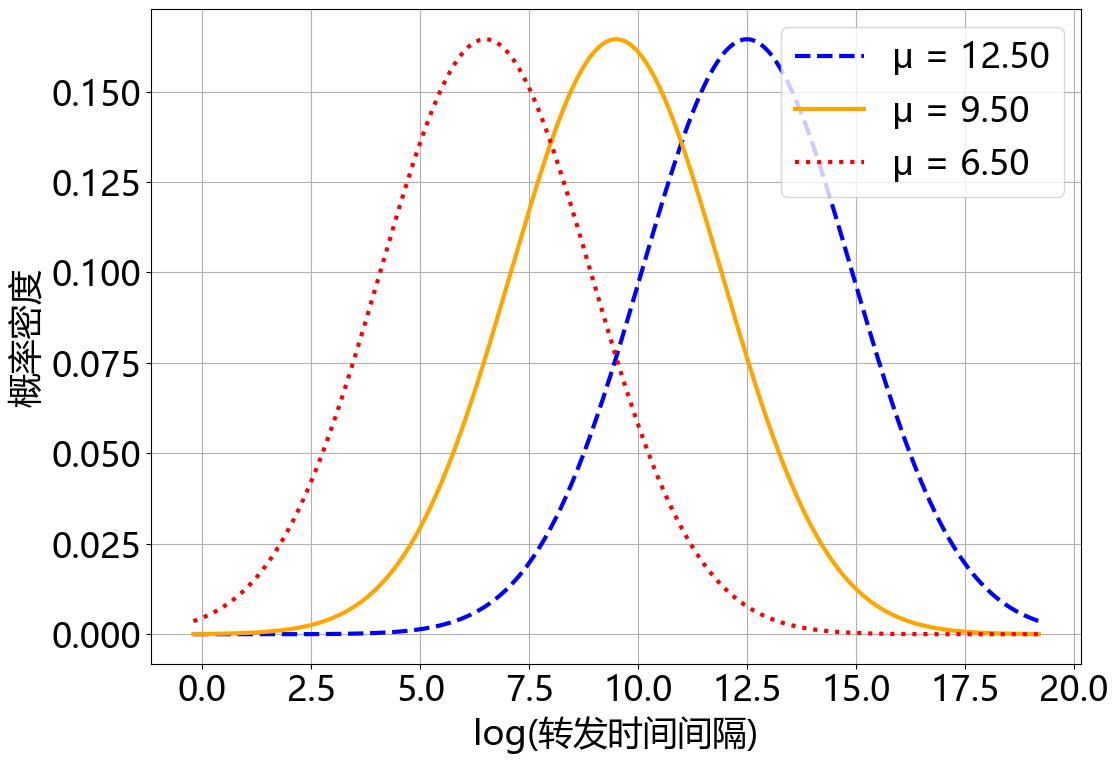

In [135]:
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.stats import norm

# plt.rcParams['font.family'] = 'Microsoft YaHei'  # 设置全局字体为 Microsoft YaHei
# plt.rcParams['axes.unicode_minus'] = False  # 防止负号显示为方块

# # 确保数据大于 0
# new_list_2 = np.array(new_list_fake)

# # 过滤掉小于等于 0 的值
# new_list_2 = new_list_2[new_list_2 > 0]

# # 对 new_list_2 进行对数变换
# new_list_2 = np.log(new_list_2)  # 如果数据需要对数变换的话才启用

# # 对原始数据进行正态分布拟合
# mean_2, std_2 = norm.fit(new_list_2)  # 拟合正态分布的均值和标准差

# # 创建一个密集的范围用于绘制拟合曲线
# x_values_2 = np.linspace(min(new_list_2), max(new_list_2), 1000)

# # 计算拟合的正态分布的概率密度函数
# fitted_pdf_2 = norm.pdf(x_values_2, mean_2, std_2)

# # 增大均值（例如，增加 2）
# mean_increased = mean_2 + 3  # 增大均值，改变正态分布的均值

# # 计算增大均值后新的拟合曲线
# fitted_pdf_2_increased_mean = norm.pdf(x_values_2, mean_increased, std_2)

# # 减小均值（例如，减小 2）
# mean_reduced = mean_2 - 3  # 减小均值，改变正态分布的均值

# # 计算减小均值后新的拟合曲线
# fitted_pdf_2_reduced_mean = norm.pdf(x_values_2, mean_reduced, std_2)

# # 生成符合不同均值的 500 个随机数
# random_numbers_original_mean = norm.rvs(loc=mean_2, scale=std_2, size=499)  # 原始均值
# random_numbers_increased_mean = norm.rvs(loc=mean_increased, scale=std_2, size=499)  # 增大均值
# random_numbers_reduced_mean = norm.rvs(loc=mean_reduced, scale=std_2, size=499)  # 减小均值

# # 将生成的随机数恢复为原始时间间隔（对数变换之前的值）
# random_numbers_original_mean_exp = np.exp(random_numbers_original_mean)  # 恢复对数变换
# random_numbers_increased_mean_exp = np.exp(random_numbers_increased_mean)  # 恢复对数变换
# random_numbers_reduced_mean_exp = np.exp(random_numbers_reduced_mean)  # 恢复对数变换

# # 将恢复后的值转换为整数
# random_numbers_original_mean_int = np.round(random_numbers_original_mean_exp).astype(int)
# random_numbers_increased_mean_int = np.round(random_numbers_increased_mean_exp).astype(int)
# random_numbers_reduced_mean_int = np.round(random_numbers_reduced_mean_exp).astype(int)

# # 打印生成的随机数
# print("Generated 500 random integer values for original mean:")
# print(random_numbers_original_mean_int)

# print("\nGenerated 500 random integer values for increased mean:")
# print(random_numbers_increased_mean_int)

# print("\nGenerated 500 random integer values for reduced mean:")
# print(random_numbers_reduced_mean_int)

# # 绘制概率密度直方图
# plt.figure(figsize=(12,8.5))

# # 绘制增大均值后的拟合曲线
# plt.plot(x_values_2, fitted_pdf_2_increased_mean, label=f'μ = {mean_increased:.2f}', color='blue', linewidth=3, linestyle='--')
# # 绘制原始数据的拟合曲线
# plt.plot(x_values_2, fitted_pdf_2, label=f'μ = {mean_2:.2f}', color='orange', linewidth=3)
# # 绘制减小均值后的拟合曲线
# plt.plot(x_values_2, fitted_pdf_2_reduced_mean, label=f'μ = {mean_reduced:.2f}', color='red', linewidth=3, linestyle=':')

# # 添加标题和标签
# plt.xlabel("log(转发时间间隔)", fontsize=25)
# plt.ylabel('概率密度', fontsize=25)

# # 设置 x 和 y 轴的刻度标签
# plt.xticks(fontsize=25)  # 设置 x 轴刻度标签的字体大小
# plt.yticks(fontsize=25)  # 设置 y 轴刻度标签的字体大小

# # 添加图例
# plt.legend(fontsize=25, loc='upper right')

# # 显示图形
# plt.grid(True)

# # 保存图像到本地
# plt.savefig('E:\大论文-第一部分\图片\三条μ拟合曲线.png', format='png', dpi=300)

# plt.show()
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from pathlib import Path

# ===== 全局字体 =====
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

# ===== 1) 数据准备：对数空间拟合 N(μ, σ) =====
# 假设 new_list_fake 为原始时间间隔（正值）
new_list_2 = np.array(new_list_fake, dtype=float)
new_list_2 = new_list_2[new_list_2 > 0]           # 仅保留正值
logx = np.log(new_list_2)                          # 对数空间

# 拟合对数空间的正态参数（对应原尺度的对数正态 μ, σ）
mean_2, std_2 = norm.fit(logx)
print("对数空间正态拟合参数：")
print(f"μ (mean) = {mean_2:.6f}")
print(f"σ (std)  = {std_2:.6f}")

# ===== 2) 三条 PDF 曲线（在对数空间）=====
# 为避免受极端值影响，曲线范围取 μ ± 4σ
x_values_2 = np.linspace(mean_2 - 4*std_2, mean_2 + 4*std_2, 1000)

# 原 μ
fitted_pdf_2 = norm.pdf(x_values_2, mean_2, std_2)

# 增大/减小均值（仍在对数空间偏移）
mean_increased = mean_2 + 3.0
mean_reduced   = mean_2 - 3.0

fitted_pdf_2_increased_mean = norm.pdf(x_values_2, mean_increased, std_2)
fitted_pdf_2_reduced_mean   = norm.pdf(x_values_2, mean_reduced,   std_2)

# ===== 3) 生成三组样本：每组 499 个 =====
n = 499
rng = np.random.default_rng()  # 如需复现实验可改为 np.random.default_rng(42)

# 在对数空间采样
z_orig  = rng.normal(loc=mean_2,       scale=std_2, size=n)
z_high  = rng.normal(loc=mean_increased, scale=std_2, size=n)
z_low   = rng.normal(loc=mean_reduced,   scale=std_2, size=n)

# 指数还原到原尺度（严格 > 0）
x_orig  = np.exp(z_orig)
x_high  = np.exp(z_high)
x_low   = np.exp(z_low)

# 整数化：随机舍入 floor(x + U)，并强制下界 ≥ 1，使用 int64 防溢出
def to_positive_int(arr_float, rng):
    u = rng.uniform(0.0, 1.0, size=arr_float.shape)
    arr = np.floor(arr_float + u)
    arr = np.clip(arr, 1, np.iinfo(np.int64).max).astype(np.int64)
    return arr

random_numbers_original_mean_int  = to_positive_int(x_orig, rng)
random_numbers_increased_mean_int = to_positive_int(x_high, rng)
random_numbers_reduced_mean_int   = to_positive_int(x_low,  rng)

# 自检（确保无 0/负数）
assert np.all(random_numbers_original_mean_int  >= 1)
assert np.all(random_numbers_increased_mean_int >= 1)
assert np.all(random_numbers_reduced_mean_int   >= 1)

# 简要摘要（避免整屏打印）
def brief(name, arr):
    a = np.asarray(arr).ravel()
    uniq = np.unique(a).size
    q50, q90, q99 = np.quantile(a, [0.5, 0.9, 0.99])
    print(f"[{name}] n={a.size}, 唯一值={uniq}, min={a.min()}, median={int(q50)}, p90={int(q90)}, p99={int(q99)}, max={a.max()}")

print("\n整数样本摘要：")
brief("原 μ",  random_numbers_original_mean_int)
brief("μ+3",   random_numbers_increased_mean_int)
brief("μ-3",   random_numbers_reduced_mean_int)

# ===== 4) 绘图：对数空间三条 PDF 曲线 =====
plt.figure(figsize=(12, 8.5))

plt.plot(x_values_2, fitted_pdf_2_increased_mean, label=f'μ = {mean_increased:.2f}', color='blue',   linewidth=3, linestyle='--')
plt.plot(x_values_2, fitted_pdf_2,               label=f'μ = {mean_2:.2f}',        color='orange', linewidth=3)
plt.plot(x_values_2, fitted_pdf_2_reduced_mean,  label=f'μ = {mean_reduced:.2f}',  color='red',    linewidth=3, linestyle=':')

plt.xlabel("log(转发时间间隔)", fontsize=25)
plt.ylabel("概率密度", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25, loc='upper right')
plt.grid(True)

# ===== 5) 保存图像（先确保目录存在，避免 OSError）=====
out_path = Path(r"E:\大论文-第一部分\图片\三条μ拟合曲线.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, format='png', dpi=300, bbox_inches='tight')
plt.show()

# 如果还需要导出三组整数样本，可取消注释保存
# import pandas as pd
# df_out = pd.DataFrame({
#     "orig_mu_int":  random_numbers_original_mean_int,
#     "mu_plus3_int": random_numbers_increased_mean_int,
#     "mu_minus3_int":random_numbers_reduced_mean_int
# })
# csv_path = Path(r"E:\大论文-第一部分\小论文数据\lognormal_mu_shift_3x499.csv")
# csv_path.parent.mkdir(parents=True, exist_ok=True)
# df_out.to_csv(csv_path, index=False, encoding="utf-8")


In [137]:
import networkx as nx
import pandas as pd
import numpy as np
from scipy.stats import norm

def growth_model(H, gamma):
    nodes = list(H.nodes())  # 存放节点的列表
    if len(nodes) == 0:
        raise ValueError('空树')
    elif len(nodes) == 1:
        return nodes[0]
    
    nodes_probs = []
    for node in nodes:
        # descendants() 返回 'H' 中 'node' 可到达的所有节点
        subtree_size = len(nx.descendants(H, node)) + 1
        node_proba = np.power(subtree_size, gamma)
        nodes_probs.append(node_proba)
    
    # 各节点的概率
    nodes_probs = [i / sum(nodes_probs) for i in nodes_probs]
    # 按照每一项的概率从数组中选取一个随机样本
    random_proba_node = np.random.choice(nodes, p=nodes_probs)
    return random_proba_node

# 参数设置
gammas = [ 2.5,  0.25, 0, -0.25, -2.5]

# 生成50组随机数，分别对应每个sigma的不同情况
def generate_random_numbers_with_none(random_numbers_list, num_sets=50):
    result = []
    for i in range(num_sets):
        # 确保每组数据是一个对象类型数组，在每组的第0个位置插入None
        random_numbers = np.insert(random_numbers_list[i], 0, None)
        result.append(random_numbers)
    return result


# 生成符合不同均值的 500 个随机数
random_numbers_original_mean = norm.rvs(loc=mean_2, scale=std_2, size=(50, 499)).astype(int)  # 原始均值
random_numbers_increased_mean = norm.rvs(loc=mean_increased, scale=std_2, size=(50, 499)).astype(int)  # 增大均值
random_numbers_reduced_mean = norm.rvs(loc=mean_reduced, scale=std_2, size=(50, 499)).astype(int)  # 减小均值

# # 将正态分布生成的随机数取指数，恢复到原始时间间隔，并转换为整数
random_numbers_original_mean_int = np.round(np.exp(random_numbers_original_mean)).astype(int)
random_numbers_increased_mean_int = np.round(np.exp(random_numbers_increased_mean)).astype(int)
random_numbers_reduced_mean_int = np.round(np.exp(random_numbers_reduced_mean)).astype(int)


# 将每组随机数的类型转换为 object 类型，以便插入 None
random_numbers_original_mu_int = random_numbers_original_mean_int.astype(object)
random_numbers_increased_mu_int = random_numbers_increased_mean_int.astype(object)
random_numbers_reduced_mu_int = random_numbers_reduced_mean_int.astype(object)


# 使用修正后的代码，生成每组随机数的列表，每组的第一个位置插入None
list_from_array = generate_random_numbers_with_none(random_numbers_original_mu_int)
list_from_array1 = generate_random_numbers_with_none(random_numbers_increased_mu_int)
list_from_array2 = generate_random_numbers_with_none(random_numbers_reduced_mu_int)


# 打印示例，查看结果
print(len(list_from_array[0]))  # 查看第一组数据

# 循环生成每种参数下的 100 个网络
for g in range(5):  # 遍历不同的 gamma 参数
    for network_id in range(50):  # 生成 100 个网络
        # 创建新的图
        H1 = nx.DiGraph()
        H1.add_node(0)

        # 构建网络直到它有 500 个节点
        while len(H1) < 500:
            node_selt = growth_model(H1, gamma=gammas[g])
            H1.add_edge(node_selt, len(H1))
        
        # 获取节点信息
        nodes = list(H1.nodes())  # 存放节点的列表
        node_mas = []
        for node in nodes:
            if node == 0:
                result = None
                node_mas.append(result)
            else:
                result = list(H1.predecessors(node))[0]
                node_mas.append(int(result))
        
        # 写入 csv 文件
        print(len(node_mas), len(nodes), len(list_from_array[network_id]))
        data = {"from": node_mas, "to": nodes, "t": list_from_array[network_id]}
        # print(len(node_mas), len(nodes), len(list_from_array[network_id]))
        df = pd.DataFrame(data)
        # 使用 f-string 进行路径拼接时，正确的语法应该是：
        csv_path = f'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\原始\{gammas[g]}/{network_id+1}.csv'
        df.to_csv(csv_path, encoding='utf-8', index=False)
        
        data = {"from": node_mas, "to": nodes, "t": list_from_array1[network_id]}
        df = pd.DataFrame(data)
        csv_path = f'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\增大\{gammas[g]}/{network_id+1}.csv'
        df.to_csv(csv_path, encoding='utf-8', index=False)
        
        data = {"from": node_mas, "to": nodes, "t": list_from_array2[network_id]}
        df = pd.DataFrame(data)
        csv_path = f'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\减小\{gammas[g]}/{network_id+1}.csv'
        df.to_csv(csv_path, encoding='utf-8', index=False)


500
500 500 500


OSError: Cannot save file into a non-existent directory: 'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\原始\2.5'

In [ ]:
import os
import pandas as pd
import networkx as nx

# 指定根路径
base_input_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\减小'
base_output_path = r'E:\大论文-第一部分\小论文数据\所有时间尺度\模型数据\修改mu\网络结构\添加时刻\减小'

# base_input_path = r'E:\大论文-第一部分\模型解耦分析\修改mu\原始'
# base_output_path = r'E:\大论文-第一部分\模型解耦分析\修改mu\添加时刻\原始'

# base_input_path = r'E:\大论文-第一部分\模型解耦分析\修改mu\增大'
# base_output_path = r'E:\大论文-第一部分\模型解耦分析\修改mu\添加时刻\增大'


# 创建输出根路径
os.makedirs(base_output_path, exist_ok=True)

# 处理函数print(len(list_from_array))  # 应该是 50
# print(len(list_from_array1))  # 应该是 50
# print(len(list_from_array2))  # 应该是 50

def process_file(file_path, output_file):
    # 读取csv文件
    df = pd.read_csv(file_path, header=None, skiprows=1, names=['from', 'to', 't'])

    # 构造有向无环图
    G = nx.DiGraph()
    for index, row in df.iterrows():
        G.add_edge(row['from'], row['to'], weight=row['t'])

    # 计算每个节点到根节点的累计时间
    root_node = 0
    cumulative_times = {root_node: 0}  # 根节点的累计时间为0
    for node in nx.topological_sort(G):
        if node == root_node:
            cumulative_times[node] = 0
        elif len(list(G.predecessors(node))) == 0:
            # 如果节点没有前驱节点，无法计算累计时间，直接跳过
            continue
        else:
            cumulative_times[node] = max(
                cumulative_times[p] + G[p][node]['weight'] for p in G.predecessors(node)
            )

    # 提取计算结果
    moment = [value for key, value in sorted(cumulative_times.items())]
    data = {
        "from": df["from"],
        "to": df["to"],
        "t": df["t"],
        "moment": moment
    }

    # 保存结果为 CSV
    result_df = pd.DataFrame(data)
    result_df.to_csv(output_file, encoding='utf-8', index=False)

# 遍历每个gamma文件夹，处理对应的所有文件
gammas = [5.0, 1.5, 0.75, 0.25, 0, -0.25, -1.0, -2.5, -7.5]

# 遍历每个 gamma 文件夹
for gamma in gammas:
    # 构造输入路径和输出路径
    gamma_input_path = os.path.join(base_input_path, str(gamma))
    gamma_output_path = os.path.join(base_output_path, str(gamma))
    
    # 创建输出文件夹
    os.makedirs(gamma_output_path, exist_ok=True)
    
    # 遍历 gamma 文件夹中的所有 CSV 文件
    for file_name in os.listdir(gamma_input_path):
        if file_name.endswith('.csv'):
            file_path = os.path.join(gamma_input_path, file_name)
            output_file = os.path.join(gamma_output_path, f"{file_name}")
            process_file(file_path, output_file)
            print(f"Processed file: {file_name} -> {output_file}")

print("所有文件已处理完成。")


In [ ]:
import os
import pandas as pd
import networkx as nx

# 定义处理单个文件夹的函数
def process_folder(base_input_folder, base_output_folder):
    # 遍历所有gamma值文件夹
    gammas = [5.0, 1.5, 0.75, 0.25, 0, -0.25, -1.0, -2.5, -7.5]

    for gamma in gammas:
        # 构造每个gamma值对应的输入和输出路径
        input_folder = os.path.join(base_input_folder, str(gamma))
        output_folder = os.path.join(base_output_folder, str(gamma))

        # 创建输出文件夹
        os.makedirs(output_folder, exist_ok=True)

        # 遍历该gamma文件夹下的所有CSV文件
        for file_name in os.listdir(input_folder):
            file_path = os.path.join(input_folder, file_name)
            if os.path.isfile(file_path) and file_name.endswith('.csv'):
                # 读取CSV文件
                df = pd.read_csv(file_path)

                # 定义结果存储列表
                list1 = []

                # 遍历每个b的值
                list2 = [30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400, 28800, 57600, 86400, 172800, 345600, 604800, 1209600]
                for b in list2:
                    # 筛选数据并创建图
                    df_filtered = df[df['t'] <= b]
                    G = nx.from_pandas_edgelist(df_filtered, 'from', 'to', create_using=nx.DiGraph())

                    if G.number_of_nodes() <= 5000:
                        # 计算时序模体度
                        list1.append([file_name[:-4], G.number_of_nodes(), motif3_1(G), motif3_2(G), 
                                      motif4_1(G), motif4_2(G), motif4_3(G), motif4_4(G),
                                      motif5_1(G), motif5_2(G), motif5_3(G), motif5_4(G), 
                                      motif5_5(G), motif5_6(G), motif5_7(G), motif5_8(G), motif5_9(G)])

                # 定义列名
                name = ['id', 'scale','m3_1', 'm3_2', 'm4_1', 'm4_2', 'm4_3', 'm4_4',
                        'm5_1', 'm5_2', 'm5_3', 'm5_4', 'm5_5', 'm5_6', 'm5_7', 'm5_8', 'm5_9']

                # 将计算结果保存到DataFrame
                test1 = pd.DataFrame(columns=name, data=list1)

                # 设置保存路径
                save_path = os.path.join(output_folder, f'{file_name[:-4]}.csv')

                # 保存为CSV文件
                test1.to_csv(save_path, encoding='utf-8', index=False)

# 调用函数进行批量处理
base_input_folder = r'E:\大论文-第一部分\模型解耦分析\修改mu\添加时刻\原始'
base_output_folder = r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\原始'
process_folder(base_input_folder, base_output_folder)

base_input_folder = r'E:\大论文-第一部分\模型解耦分析\修改mu\添加时刻\减小'
base_output_folder = r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\减小'
process_folder(base_input_folder, base_output_folder)

base_input_folder = r'E:\大论文-第一部分\模型解耦分析\修改mu\添加时刻\增大'
base_output_folder = r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\增大'
process_folder(base_input_folder, base_output_folder)

In [ ]:
import os
import pandas as pd
import numpy as np

def process_folder(base_input_folder, base_output_folder):
    # 遍历所有gamma值文件夹
    gammas = ['5.0', '1.5', '0.75', '0.25', '0', '-0.25', '-1.0', '-2.5', '-7.5']

    # 遍历每个gamma值文件夹
    for gamma in gammas:
        # 构造每个gamma值对应的输入路径
        input_folder = os.path.join(base_input_folder, gamma)

        # 初始化存储每一行m3_1和m3_2均值的列表
        m3_1_means = []
        m3_2_means = []

        # 遍历该gamma文件夹下的所有CSV文件
        for file_name in os.listdir(input_folder):
            file_path = os.path.join(input_folder, file_name)
            if os.path.isfile(file_path) and file_name.endswith('.csv'):
                # 读取CSV文件
                df = pd.read_csv(file_path)

                # 遍历每一行
                for i in range(len(df)):
                    m3_1 = df.loc[i, 'm3_1']
                    m3_2 = df.loc[i, 'm3_2']
                    
                    # 如果列表长度不够，扩展列表
                    if len(m3_1_means) <= i:
                        m3_1_means.append([])
                        m3_2_means.append([])

                    # 将当前行的m3_1和m3_2值添加到对应的列表中
                    m3_1_means[i].append(m3_1)
                    m3_2_means[i].append(m3_2)

        # 计算每一行的均值
        result_data = []
        for i in range(len(m3_1_means)):
            mean_m3_1 = np.mean(m3_1_means[i])
            mean_m3_2 = np.mean(m3_2_means[i])
            result_data.append([mean_m3_1, mean_m3_2])

        # 将计算结果写入指定路径下的CSV文件
        result_df = pd.DataFrame(result_data, columns=['mean_m3_1', 'mean_m3_2'])
        output_file = os.path.join(base_output_folder, f'{gamma}.csv')
        result_df.to_csv(output_file, index=False, encoding='utf-8')

        print(f"文件夹 {gamma} 的计算结果已保存到 {output_file}")

# 调用函数
base_input_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\减小"
base_output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\求均值\减小"
process_folder(base_input_folder, base_output_folder)

# 调用函数
base_input_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\增大"
base_output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\求均值\增大"
process_folder(base_input_folder, base_output_folder)

# 调用函数
base_input_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\原始"
base_output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\求均值\原始"
process_folder(base_input_folder, base_output_folder)

In [ ]:
import os
import pandas as pd

def merge_csv_files(input_folders, output_folder):
    # 遍历所有文件夹中的CSV文件
    for gamma in ['5.0', '1.5', '0.75', '0.25', '0', '-0.25', '-1.0', '-2.5', '-7.5']:
        # 存储每个gamma对应的所有文件路径
        files_to_merge = []
        column_names = []

        # 构建路径并读取对应的CSV文件
        for folder, prefix in zip(input_folders, ['减小', '增大', '原始']):
            file_path = os.path.join(folder, gamma + '.csv')
            if os.path.exists(file_path):
                # 读取CSV文件
                df = pd.read_csv(file_path)
                
                # 为列名添加前缀以区分
                df.columns = [f"{col}_{prefix}" for col in df.columns]
                files_to_merge.append(df)
        
        # 如果有对应的CSV文件，可以进行合并
        if files_to_merge:
            # 合并所有DataFrame
            merged_df = pd.concat(files_to_merge, axis=1)

            # 保存合并后的结果到输出文件夹
            output_file_path = os.path.join(output_folder, gamma + '_merged.csv')
            merged_df.to_csv(output_file_path, index=False, encoding='utf-8')
            print(f"文件 {gamma}_merged.csv 已合并并保存至 {output_file_path}")

# 输入路径列表
input_folders = [
    r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\求均值\减小",
    r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\求均值\增大",
    r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\求均值\原始"
]

# 输出路径
output_folder = r"E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果"

# 调用函数
merge_csv_files(input_folders, output_folder)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 文件路径列表 (根据实际文件路径调整)
csv_file_paths = [
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-7.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-2.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-1.0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\0.75_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\1.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\5.0_merged.csv'
]

# 创建一个3x3的子图
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# 逐个读取CSV文件并绘制图形
for i, file_path in enumerate(csv_file_paths):
    # 读取CSV文件
    df = pd.read_csv(file_path)
    
    # 提取x值（第一列）和y值（第二、第四、第六列）
    x = [30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400, 28800, 57600, 86400, 172800, 345600, 604800, 1209600]
    y1 = df.iloc[:, 0]
    y2 = df.iloc[:, 2]
    y3 = df.iloc[:, 4]

    # 确定当前子图的位置
    ax = axs[i // 3, i % 3]  # 3x3的子图布局，确定位置

    # 绘制y1, y2, y3在同一子图中
    ax.plot(x, y2, label='μ = 12.50', color='blue', linewidth=3, linestyle='--')
    ax.plot(x, y3, label='μ = 9.50', color='orange', linewidth=3)
    ax.plot(x, y1, label='μ = 6.50', color='red', linewidth=3, linestyle=':')


    # 提取文件名中的数值来作为γ的值
    file_name = os.path.splitext(os.path.basename(file_path))[0]  # 去掉扩展名
    gamma_value = file_name  # 假设文件名本身就是我们要的gamma值

    # 设置y轴标签为“γ = [value]”
    ax.set_ylabel(f'γ = {gamma_value[:-7]}', fontsize=25, fontname='Times New Roman')  # 中文字体为微软雅黑

    # 设置x轴标签
    ax.set_xlabel('时间尺度', fontsize=22, fontname='Microsoft YaHei')  # 中文字体为微软雅黑

    # 设置坐标轴刻度标签字体大小和字体
    ax.tick_params(axis='both', labelsize=22, direction='in', width=2, length=7)  # 增大刻度标签字体大小，主刻度线条宽度为2，长度为8
    for tick in ax.get_xticklabels():
        tick.set_fontname('Times New Roman')  # 设置x轴刻度标签字体为 Times New Roman
    for tick in ax.get_yticklabels():
        tick.set_fontname('Times New Roman')  # 设置y轴刻度标签字体为 Times New Roman

    # 启用次刻度并设置次刻度的样式
    ax.minorticks_on()  # 启用次刻度
    ax.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内，宽度为1，长度为4

    # 设置x轴为对数坐标
    ax.set_xscale('log')  # 设置x轴为对数坐标
    ax.set_yscale('log')  # 设置y轴为对数坐标

    # 添加右轴和上轴
    ax2 = ax.twinx()  # 创建右侧y轴
    ax3 = ax.twiny()  # 创建上方x轴

    # 设置右轴和上轴的主刻度朝内
    ax2.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)
    ax3.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)

    # 设置右轴和上轴的次刻度
    ax2.minorticks_on()
    ax2.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax2.tick_params(axis='both', labelsize=0)  # 删除右轴的刻度标签

    ax3.minorticks_on()
    ax3.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax3.tick_params(axis='both', labelsize=0)  # 删除上轴的刻度标签

    # 只在第一个子图中添加图例
    # 只在最后一个子图中添加图例
    if i == len(csv_file_paths) - 1:
        ax.legend(frameon=False, prop={'family': 'Times New Roman', 'size': 22})


# 自动调整子图布局以防止重叠
plt.tight_layout()

# 保存图片到文件
plt.savefig(r'E:\大论文-第一部分\图片\修改mu_时序广度模体度变化.png',dpi=300)

# 显示图形
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# 文件路径列表 (根据实际文件路径调整)
csv_file_paths = [
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-7.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-2.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-1.0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\-0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\0_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\0.25_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\0.75_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\1.5_merged.csv',
    r'E:\大论文-第一部分\模型解耦分析-三个尺度\修改mu\时序模体度\合并结果\5.0_merged.csv'
]

# 创建一个3x3的子图
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# 逐个读取CSV文件并绘制图形
for i, file_path in enumerate(csv_file_paths):
    # 读取CSV文件
    df = pd.read_csv(file_path)
    
    # 提取x值（第一列）和y值（第二、第四、第六列）
    x = [30, 60, 120, 240, 480, 960, 1920, 3600, 7200, 14400, 28800, 57600, 86400, 172800, 345600, 604800, 1209600]
    y1 = df.iloc[:, 1]
    y2 = df.iloc[:, 3]
    y3 = df.iloc[:, 5]

    # 确定当前子图的位置
    ax = axs[i // 3, i % 3]  # 3x3的子图布局，确定位置

    # 绘制y1, y2, y3在同一子图中
    ax.plot(x, y2, label='μ = 12.50', color='blue', linewidth=3, linestyle='--')
    ax.plot(x, y3, label='μ = 9.50', color='orange', linewidth=3)
    ax.plot(x, y1, label='μ = 6.50', color='red', linewidth=3, linestyle=':')
    
    # 提取文件名中的数值来作为γ的值
    file_name = os.path.splitext(os.path.basename(file_path))[0]  # 去掉扩展名
    gamma_value = file_name  # 假设文件名本身就是我们要的gamma值

    # 设置y轴标签为“γ = [value]”
    ax.set_ylabel(f'γ = {gamma_value[:-7]}', fontsize=25, fontname='Times New Roman')  # 中文字体为微软雅黑

    # 设置x轴标签
    ax.set_xlabel('时间尺度', fontsize=22, fontname='Microsoft YaHei')  # 中文字体为微软雅黑

    # 设置坐标轴刻度标签字体大小和字体
    ax.tick_params(axis='both', labelsize=22, direction='in', width=2, length=7)  # 增大刻度标签字体大小，主刻度线条宽度为2，长度为8
    for tick in ax.get_xticklabels():
        tick.set_fontname('Times New Roman')  # 设置x轴刻度标签字体为 Times New Roman
    for tick in ax.get_yticklabels():
        tick.set_fontname('Times New Roman')  # 设置y轴刻度标签字体为 Times New Roman

    # 启用次刻度并设置次刻度的样式
    ax.minorticks_on()  # 启用次刻度
    ax.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内，宽度为1，长度为4

    # 设置x轴为对数坐标
    ax.set_xscale('log')  # 设置x轴为对数坐标
    ax.set_yscale('log')  # 设置y轴为对数坐标

    # 添加右轴和上轴
    ax2 = ax.twinx()  # 创建右侧y轴
    ax3 = ax.twiny()  # 创建上方x轴

    # 设置右轴和上轴的主刻度朝内
    ax2.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)
    ax3.tick_params(axis='both', direction='in', length=7, width=2, labelsize=22, labelrotation=0)

    # 设置右轴和上轴的次刻度
    ax2.minorticks_on()
    ax2.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax2.tick_params(axis='both', labelsize=0)  # 删除右轴的刻度标签

    ax3.minorticks_on()
    ax3.tick_params(axis='both', which='minor', length=4, color='black', direction='in', width=1)  # 次刻度朝内
    ax3.tick_params(axis='both', labelsize=0)  # 删除上轴的刻度标签

    # 只在第一个子图中添加图例
    if i == 0:
        ax.legend(frameon=False, prop={'family': 'Times New Roman', 'size': 22})

# 自动调整子图布局以防止重叠
plt.tight_layout()

# 保存图片到文件
plt.savefig(r'E:\大论文-第一部分\图片\修改mu_时序深度模体度变化.png',dpi=300)

# 显示图形
plt.show()


In [ ]:
import os
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ==== 设置四类数据路径 ====
paths = {
    "虚假谣言": r"E:\U盘\时间间隔\twitter16\from_to_t_time_时刻\false",
    "非谣言": r"E:\U盘\时间间隔\twitter16\from_to_t_time_时刻\nonrumor",
    "真实谣言": r"E:\U盘\时间间隔\twitter16\from_to_t_time_时刻\ture",
    "未经证实的谣言": r"E:\U盘\时间间隔\twitter16\from_to_t_time_时刻\unverified"
}

# 时间窗口参数
window_size = 30  # 分钟
max_windows = 96

# 模体函数
def motif3_1(G):
    M3 = [G.out_degree(m) for m in G if G.out_degree(m) > 1]
    return int(sum(k * (k - 1) / 2 for k in M3))

def motif3_2(G):
    return int(sum(G.out_degree(q) for p in G for q in G.successors(p) if G.out_degree(p) > 0 and G.out_degree(q) > 0))

def process_file(file_path):
    data = pd.read_csv(file_path, encoding='gb18030')
    data['时刻_min'] = pd.to_numeric(data['时刻'], errors='coerce') / 60
    data = data.dropna(subset=['时刻_min']).sort_values(by='时刻_min')

    time_points = [i * window_size for i in range(max_windows + 1)]
    breadth_rates, depth_rates = [], []
    prev_breadth, prev_depth = 0, 0

    for t in time_points[1:]:
        sub_data = data[data['时刻_min'] <= t]
        if sub_data.empty:
            breadth_rates.append(0)
            depth_rates.append(0)
            continue

        G = nx.from_pandas_edgelist(sub_data, source="from", target="to", create_using=nx.DiGraph())
        breadth = motif3_1(G)
        depth = motif3_2(G)

        breadth_rates.append((breadth - prev_breadth) / window_size)
        depth_rates.append((depth - prev_depth) / window_size)
        prev_breadth, prev_depth = breadth, depth

    return breadth_rates, depth_rates

# 收集统计结果
results = {}
for label, folder in paths.items():
    results[label] = {"breadth": [], "depth": []}
    for fname in os.listdir(folder):
        if fname.endswith(".csv"):
            fpath = os.path.join(folder, fname)
            b_rates, d_rates = process_file(fpath)
            if b_rates: results[label]["breadth"].append(b_rates)
            if d_rates: results[label]["depth"].append(d_rates)

# 找最大窗口
def find_last_nonzero(data_lists):
    max_len = max(len(x) for x in data_lists)
    for i in range(max_len - 1, -1, -1):
        if any(len(x) > i and x[i] != 0 for x in data_lists):
            return i
    return 0

all_data_lists = sum([[v["breadth"], v["depth"]] for v in results.values()], [])
last_window = min(find_last_nonzero(all_data_lists) + 2, max_windows)

# 平均函数
def safe_avg(data, max_len):
    return [
        sum(x[i] for x in data if len(x) > i) / len([x for x in data if len(x) > i])
        if any(len(x) > i for x in data) else 0
        for i in range(max_len)
    ]

# 生成绘图标签（单位改为小时）
window_labels = [f"{(i * window_size) / 60:.1f}h" for i in range(1, last_window + 1)]

# 设置稀疏刻度
tick_interval = 30
xtick_positions = list(range(0, last_window, tick_interval))
xtick_labels = [window_labels[i] for i in xtick_positions]

# ==== 绘图 ====
plt.figure(figsize=(22, 8))

# 广度模体
plt.subplot(1, 2, 1)
for label, color, marker in zip(results.keys(), ['blue', 'orange', 'green', 'purple'], ['o', '^', 's', 'D']):
    avg = safe_avg(results[label]["breadth"], last_window)
    plt.plot(window_labels, avg, label=label, marker=marker, markersize=4)
plt.xlabel("传播时间窗口（小时）", fontsize=25)
plt.ylabel("突发广度模体增长速率", fontsize=25)
# plt.title("广度模体增长速率随时间变化（四类）", fontsize=17)
plt.xticks(ticks=xtick_positions, labels=xtick_labels,  fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.grid(True)

# 深度模体
plt.subplot(1, 2, 2)
for label, color, marker in zip(results.keys(), ['blue', 'orange', 'green', 'purple'], ['o', '^', 's', 'D']):
    avg = safe_avg(results[label]["depth"], last_window)
    plt.plot(window_labels, avg, label=label, marker=marker, markersize=4)
plt.xlabel("传播时间窗口（小时）", fontsize=25)
plt.ylabel("突发深度模体增长速率", fontsize=25)
plt.xticks(ticks=xtick_positions, labels=xtick_labels,  fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.grid(True)
plt.savefig('E:\大论文-第二部分\图片\twitter16_机制分析.png', format='png', dpi=300)
plt.tight_layout()
plt.show()
